# MLB Local EDA + Modeling Lab

This is the **local-only second half** of the split workflow.

Use it after running the cloud/API data grab notebook and downloading the export zip/folder to your PC.

This notebook does **not** call MLB Stats API, The Odds API, Baseball Savant, pybaseball, GCS, or Cloud Run. It only reads the exported local parquet files, then runs:

- feature inventory and search
- missingness and coverage checks
- leakage audits
- target-focused EDA
- PCA diagnostics
- baseline comparisons
- moneyline classification
- total-runs regression / Poisson-style candidates
- home-margin / run-line regression candidates
- champion selection
- model bundle exports
- local prediction CSV creation

Expected input from the first notebook:

```text
mlb_data_export/processed/mlb_game_features.parquet
```

Optional raw/intermediate files are loaded if present.

## 0. Optional package install

Run this only if your local environment is missing packages. `xgboost` is optional; the notebook will skip it if unavailable.

In [43]:
# %pip install pandas numpy pyarrow scikit-learn joblib matplotlib
# Optional:
# %pip install xgboost

## 1. Configuration

Set `EXPORT_ZIP` if you downloaded a zip from the cloud data-grab notebook. If you already extracted it, set `EXPORT_DIR` to the extracted folder.

In [44]:
from pathlib import Path
from datetime import datetime, timezone
import os
import re
import json
import math
import zipfile
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------
# Local paths
# ---------------------------------------------------------------------
# Option A: point directly at the zip produced by the cloud notebook.
EXPORT_ZIP = Path(r"C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17.zip")

# Option B: point at an already-extracted export folder.
EXPORT_DIR = None #Path("mlb_data_export")

# Output folders created locally by this notebook.
OUTPUT_DIR = Path("mlb_local_outputs")
MODEL_DIR = OUTPUT_DIR / "models"
PRED_DIR = OUTPUT_DIR / "predictions"
EDA_DIR = OUTPUT_DIR / "eda"

for p in [OUTPUT_DIR, MODEL_DIR, PRED_DIR, EDA_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Modeling controls.
RANDOM_STATE = 42
TEST_FRACTION = 0.20
HOLDOUT_START_DATE = None  # Example: "2025-01-01". If set, overrides TEST_FRACTION.
MIN_TRAIN_DATE = None      # Example: "2022-01-01". Leave None to use all available history.
FAST_MODE = False          # True = fewer candidates / faster local run.

# Feature cleaning controls.
DROP_ALL_NULL_FEATURES = True
DROP_FEATURES_MISSING_ABOVE = 0.9
DROP_CONSTANT_FEATURES = True
INCLUDE_NUMERIC_ID_FEATURES = False

# Export controls. Keep False until you like the results.
APPROVE_MONEYLINE_EXPORT = False
APPROVE_TOTALS_EXPORT = False
APPROVE_MARGIN_EXPORT = False

print("cwd:", Path.cwd())
print("output_dir:", OUTPUT_DIR.resolve())

cwd: c:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\notebooks
output_dir: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\notebooks\mlb_local_outputs


In [45]:
print("EXPORT_ZIP exists:", EXPORT_ZIP.exists())
print("EXPORT_ZIP:", EXPORT_ZIP)

if EXPORT_DIR is not None:
    print("EXPORT_DIR exists:", EXPORT_DIR.exists())
    print("EXPORT_DIR:", EXPORT_DIR)

EXPORT_ZIP exists: True
EXPORT_ZIP: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17.zip


## 2. Locate/extract the data export

This cell looks for `mlb_game_features.parquet` in your extracted export. If you only downloaded a zip, it extracts it first.

In [46]:
def auto_find_export_zip() -> Path | None:
    patterns = [
        "mlb_data_export*.zip",
        "15_mlb_cloud_data_grab*.zip",
        "*mlb*export*.zip",
    ]

    candidates = []

    for pat in patterns:
        candidates.extend(Path.cwd().glob(pat))
        candidates.extend((Path.home() / "Downloads").glob(pat))

    candidates = [p for p in candidates if p.is_file()]

    if not candidates:
        return None

    return max(candidates, key=lambda p: p.stat().st_mtime)


def extract_export_if_needed(export_zip=None, export_dir=None) -> Path:
    # If user supplied a folder, use it directly.
    if export_dir is not None:
        export_dir = Path(export_dir)
        return export_dir

    # If user supplied a zip, extract beside the zip.
    if export_zip is not None:
        export_zip = Path(export_zip)
        assert export_zip.exists(), f"EXPORT_ZIP not found: {export_zip}"

        export_dir = export_zip.parent / export_zip.stem
        export_dir.mkdir(parents=True, exist_ok=True)

        print(f"Extracting {export_zip} -> {export_dir.resolve()}")

        with zipfile.ZipFile(export_zip, "r") as z:
            z.extractall(export_dir)

        return export_dir

    # Otherwise auto-find a recent export zip.
    found = auto_find_export_zip()

    if found is None:
        raise FileNotFoundError(
            "No export zip found. Set EXPORT_ZIP to your mlb_data_export zip path "
            "or set EXPORT_DIR to an already-extracted folder."
        )

    export_dir = found.parent / found.stem
    export_dir.mkdir(parents=True, exist_ok=True)

    print("Auto-found export zip:", found)
    print(f"Extracting {found} -> {export_dir.resolve()}")

    with zipfile.ZipFile(found, "r") as z:
        z.extractall(export_dir)

    return export_dir


def find_features_path(export_dir: Path) -> Path:
    candidates = [
        export_dir / "processed" / "mlb_game_features.parquet",
        export_dir / "mlb_data_export" / "processed" / "mlb_game_features.parquet",
        export_dir / "mlb_game_features.parquet",
    ]
    candidates.extend(export_dir.rglob("mlb_game_features.parquet") if export_dir.exists() else [])

    for p in candidates:
        if p.exists():
            return p

    raise FileNotFoundError(
        "Could not find mlb_game_features.parquet. "
        "Set EXPORT_ZIP or EXPORT_DIR to the output from the cloud data-grab notebook."
    )

EXPORT_DIR = extract_export_if_needed(EXPORT_ZIP, EXPORT_DIR)
FEATURES_PATH = find_features_path(EXPORT_DIR)

print("FEATURES_PATH:", FEATURES_PATH.resolve())

Extracting C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17.zip -> C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17
FEATURES_PATH: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17\processed\mlb_game_features.parquet


## 3. Load features and optional raw tables

In [47]:
features = pd.read_parquet(FEATURES_PATH)

# Standardize dates if present.
if "official_date" in features.columns:
    features["official_date"] = pd.to_datetime(features["official_date"], errors="coerce")
if "game_datetime_utc" in features.columns:
    features["game_datetime_utc"] = pd.to_datetime(features["game_datetime_utc"], errors="coerce", utc=True)

print("features:", features.shape)
print("date range:", features.get("official_date", pd.Series(dtype="datetime64[ns]")).min(), features.get("official_date", pd.Series(dtype="datetime64[ns]")).max())
display(features.head())

# Optional raw tables if the first notebook exported them.
raw_tables = {}
for name in [
    "mlb_games",
    "mlb_box_team_game",
    "mlb_box_pitcher_game",
    "mlb_odds_events",
    "mlb_odds_snapshots",
    "mlb_statcast_raw",
]:
    paths = list(EXPORT_DIR.rglob(f"{name}.parquet"))
    if paths:
        try:
            raw_tables[name] = pd.read_parquet(paths[0])
            print(name, raw_tables[name].shape, paths[0])
        except Exception as e:
            print("Could not load", name, e)

features: (8404, 2049)
date range: 2023-03-30 00:00:00 2026-09-22 00:00:00


,game_pk,official_date,game_datetime_utc,game_type,detailed_state,abstract_state,home_team_id,home_team_name,home_team_norm,away_team_id,...,diff_starter_starter_statcast_sc_hr_rate_season_to_date,diff_starter_starter_statcast_sc_hr_rate_last3,diff_starter_starter_statcast_sc_hr_rate_last5,diff_starter_starter_statcast_sc_hr_rate_last10,diff_starter_starter_statcast_sc_hr_rate_last20,diff_starter_starter_statcast_sc_pitchmix_entropy_season_to_date,diff_starter_starter_statcast_sc_pitchmix_entropy_last3,diff_starter_starter_statcast_sc_pitchmix_entropy_last5,diff_starter_starter_statcast_sc_pitchmix_entropy_last10,diff_starter_starter_statcast_sc_pitchmix_entropy_last20
0,718780,2023-03-30,2023-03-30 17:05:00+00:00,R,Final,Final,120,Washington Nationals,washington nationals,144,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,718781,2023-03-30,2023-03-30 17:05:00+00:00,R,Final,Final,147,New York Yankees,new york yankees,137,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,718782,2023-03-30,2023-03-30 18:10:00+00:00,R,Final,Final,111,Boston Red Sox,boston red sox,110,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,718777,2023-03-30,2023-03-30 18:20:00+00:00,R,Final,Final,112,Chicago Cubs,chicago cubs,158,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,718776,2023-03-30,2023-03-30 19:10:00+00:00,R,Final,Final,139,Tampa Bay Rays,tampa bay rays,116,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


mlb_games (8404, 22) C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17\raw\mlb_games.parquet
mlb_box_team_game (16730, 93) C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17\raw\mlb_box_team_game.parquet
mlb_box_pitcher_game (71258, 77) C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17\raw\mlb_box_pitcher_game.parquet
mlb_odds_events (0, 0) C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17\raw\mlb_odds_events.parquet
mlb_odds_snapshots (0, 0) C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\export_data\mlb_data_export_2023-01-01_to_2026-06-17\raw\mlb_odds_snapshots.parquet


In [48]:
# ---------------------------------------------------------------------
# Canonical team-name cleanup on the main dataset
# ---------------------------------------------------------------------

TEAM_DISPLAY_NAME_MAP = {
    "Athletics": "Oakland Athletics",
    "The Athletics": "Oakland Athletics",
    "A's": "Oakland Athletics",
    "As": "Oakland Athletics",
}

TEAM_NORM_MAP = {
    "athletics": "oakland athletics",
    "oakland athletics": "oakland athletics",
    "ath": "oakland athletics",
    "oak": "oakland athletics",
}

def clean_team_display_name(x):
    if pd.isna(x):
        return x
    s = str(x).strip()
    return TEAM_DISPLAY_NAME_MAP.get(s, s)

def clean_team_norm_name(x):
    if pd.isna(x):
        return x
    s = str(x).strip().lower()
    return TEAM_NORM_MAP.get(s, s)

features = features.copy()

for c in ["home_team_name", "away_team_name"]:
    if c in features.columns:
        features[c] = features[c].apply(clean_team_display_name)

for c in ["home_team_norm", "away_team_norm"]:
    if c in features.columns:
        features[c] = features[c].apply(clean_team_norm_name)

# If normalized columns do not exist, recreate them from display names.
if "home_team_norm" not in features.columns and "home_team_name" in features.columns:
    features["home_team_norm"] = features["home_team_name"].str.lower().str.strip()

if "away_team_norm" not in features.columns and "away_team_name" in features.columns:
    features["away_team_norm"] = features["away_team_name"].str.lower().str.strip()

features["home_team_norm"] = features["home_team_norm"].apply(clean_team_norm_name)
features["away_team_norm"] = features["away_team_norm"].apply(clean_team_norm_name)

print("Home team counts:")
display(features.groupby("home_team_name")["game_pk"].count().sort_index())

print("Away team counts:")
display(features.groupby("away_team_name")["game_pk"].count().sort_index())

Home team counts:


home_team_name
Arizona Diamondbacks     281
Atlanta Braves           278
Baltimore Orioles        284
Boston Red Sox           280
Chicago Cubs             281
Chicago White Sox        280
Cincinnati Reds          282
Cleveland Guardians      280
Colorado Rockies         277
Detroit Tigers           277
Houston Astros           281
Kansas City Royals       281
Los Angeles Angels       280
Los Angeles Dodgers      280
Miami Marlins            282
Milwaukee Brewers        282
Minnesota Twins          282
New York Mets            279
New York Yankees         278
Oakland Athletics        280
Philadelphia Phillies    282
Pittsburgh Pirates       282
San Diego Padres         281
San Francisco Giants     277
Seattle Mariners         280
St. Louis Cardinals      282
Tampa Bay Rays           276
Texas Rangers            276
Toronto Blue Jays        282
Washington Nationals     281
Name: game_pk, dtype: int64

Away team counts:


away_team_name
Arizona Diamondbacks     279
Atlanta Braves           282
Baltimore Orioles        277
Boston Red Sox           279
Chicago Cubs             280
Chicago White Sox        279
Cincinnati Reds          278
Cleveland Guardians      281
Colorado Rockies         284
Detroit Tigers           284
Houston Astros           281
Kansas City Royals       280
Los Angeles Angels       281
Los Angeles Dodgers      281
Miami Marlins            279
Milwaukee Brewers        276
Minnesota Twins          279
New York Mets            281
New York Yankees         282
Oakland Athletics        280
Philadelphia Phillies    278
Pittsburgh Pirates       279
San Diego Padres         278
San Francisco Giants     283
Seattle Mariners         281
St. Louis Cardinals      278
Tampa Bay Rays           283
Texas Rangers            283
Toronto Blue Jays        278
Washington Nationals     280
Name: game_pk, dtype: int64

## 4. Feature inventory helpers

Use this section to understand what features exist and find columns by keyword.

In [49]:
TARGET_EXACT = {
    "target_home_win",
    "target_total_runs",
    "target_home_margin",
    "home_score",
    "away_score",
    "home_win",
    "away_win",
    "home_run_diff",
    "away_run_diff",
}

DATE_COLS = {
    "official_date",
    "game_datetime_utc",
    "scored_at_utc",
    "snapshot_loaded_at_utc",
}

TEXT_COL_HINTS = [
    "team_name",
    "team_abbr",
    "team_norm",
    "pitcher_name",
    "venue",
    "status",
    "state",
]

LEAKY_CONTAINS = [
    "target_",
    "actual_",
    "final_",
    "postgame",
    "post_game",
    "winner",
    "winning_team",
    "losing_team",
]

LEAKY_EXACT = {
    "home_score",
    "away_score",
    "home_win",
    "away_win",
    "home_run_diff",
    "away_run_diff",
    "target_home_win",
    "target_total_runs",
    "target_home_margin",
}


def is_numeric_id_col(c: str) -> bool:
    c_low = c.lower()
    return c_low == "game_pk" or c_low.endswith("_id") or c_low.endswith("id")


def is_probably_text_col(c: str) -> bool:
    c_low = c.lower()
    return any(h in c_low for h in TEXT_COL_HINTS)


def is_probably_leaky_col(c: str) -> bool:
    c_low = c.lower()
    if c_low in LEAKY_EXACT:
        return True
    return any(p in c_low for p in LEAKY_CONTAINS)


def feature_family(c: str) -> str:
    c_low = c.lower()
    if "elo" in c_low:
        return "elo"
    if "starter" in c_low:
        return "starter"
    if "bullpen" in c_low or "relief" in c_low:
        return "bullpen"
    if "pitchmix" in c_low or "pitch_type" in c_low:
        return "pitchmix"
    if "sc_team" in c_low or "statcast" in c_low or "xwoba" in c_low or "hard_hit" in c_low:
        return "statcast"
    if "box" in c_low:
        return "boxscore"
    if "team_team" in c_low or "runs_for" in c_low or "runs_against" in c_low:
        return "team_form"
    if "odds" in c_low or "market" in c_low or "moneyline" in c_low or "spread" in c_low or "total" in c_low:
        return "odds_market"
    if c_low.startswith("diff_"):
        return "diff_features"
    return "other"


def find_features(term: str, cols=None) -> list[str]:
    if cols is None:
        cols = list(features.columns)
    terms = [t.strip().lower() for t in term.split() if t.strip()]
    out = []
    for c in cols:
        c_low = c.lower()
        if all(t in c_low for t in terms):
            out.append(c)
    return out


def display_features(term: str, cols=None, n=200):
    out = find_features(term, cols)
    print(f"Found {len(out)} columns matching: {term!r}")
    display(pd.DataFrame({"column": out[:n]}))
    return out

print("Example searches:")
print("starter era:", find_features("starter era")[:10])
print("pitchmix fastball:", find_features("pitchmix fastball")[:10])
print("elo:", find_features("elo")[:10])

Example searches:
starter era: ['home_starter_box_last_outing_era', 'home_starter_box_rolling3_era', 'home_starter_box_rolling5_era', 'home_starter_box_rolling10_era', 'away_starter_box_last_outing_era', 'away_starter_box_rolling3_era', 'away_starter_box_rolling5_era', 'away_starter_box_rolling10_era', 'diff_starter_box_last_outing_era', 'diff_starter_box_rolling3_era']
pitchmix fastball: ['home_team_pitchmix_team_pitchmix_pt_avg_ev_fastball_season_to_date', 'home_team_pitchmix_team_pitchmix_pt_avg_ev_fastball_last3', 'home_team_pitchmix_team_pitchmix_pt_avg_ev_fastball_last5', 'home_team_pitchmix_team_pitchmix_pt_avg_ev_fastball_last10', 'home_team_pitchmix_team_pitchmix_pt_avg_ev_fastball_last20', 'home_team_pitchmix_team_pitchmix_pt_hard_hit_rate_fastball_season_to_date', 'home_team_pitchmix_team_pitchmix_pt_hard_hit_rate_fastball_last3', 'home_team_pitchmix_team_pitchmix_pt_hard_hit_rate_fastball_last5', 'home_team_pitchmix_team_pitchmix_pt_hard_hit_rate_fastball_last10', 'home_tea

## 5. Derive missing targets if needed and identify candidate model features

In [50]:
features = features.copy()

# Derive targets if they were not included but scores are present.
if {"home_score", "away_score"}.issubset(features.columns):
    if "target_home_win" not in features.columns:
        features["target_home_win"] = np.where(
            features["home_score"].notna() & features["away_score"].notna(),
            (features["home_score"] > features["away_score"]).astype(float),
            np.nan,
        )
    if "target_total_runs" not in features.columns:
        features["target_total_runs"] = features["home_score"] + features["away_score"]
    if "target_home_margin" not in features.columns:
        features["target_home_margin"] = features["home_score"] - features["away_score"]

numeric_cols = features.select_dtypes(include=[np.number, "bool"]).columns.tolist()

candidate_feature_cols = []
excluded_rows = []
for c in numeric_cols:
    reason = None
    if c in DATE_COLS:
        reason = "date"
    elif is_probably_leaky_col(c):
        reason = "leaky_or_target"
    elif is_numeric_id_col(c) and not INCLUDE_NUMERIC_ID_FEATURES:
        reason = "numeric_id"
    elif features[c].isna().mean() >= 1.0 and DROP_ALL_NULL_FEATURES:
        reason = "all_null"
    elif features[c].isna().mean() > DROP_FEATURES_MISSING_ABOVE:
        reason = f"missing_gt_{DROP_FEATURES_MISSING_ABOVE}"
    elif DROP_CONSTANT_FEATURES and features[c].nunique(dropna=True) <= 1:
        reason = "constant"

    if reason is None:
        candidate_feature_cols.append(c)
    else:
        excluded_rows.append({"column": c, "reason": reason})

excluded_df = pd.DataFrame(excluded_rows)

inventory = pd.DataFrame({
    "column": candidate_feature_cols,
    "family": [feature_family(c) for c in candidate_feature_cols],
    "missing_rate": [features[c].isna().mean() for c in candidate_feature_cols],
    "non_missing_rate": [features[c].notna().mean() for c in candidate_feature_cols],
    "n_unique": [features[c].nunique(dropna=True) for c in candidate_feature_cols],
    "dtype": [str(features[c].dtype) for c in candidate_feature_cols],
})

print("Total columns:", features.shape[1])
print("Numeric columns:", len(numeric_cols))
print("Candidate feature columns:", len(candidate_feature_cols))
print("Excluded numeric columns:", len(excluded_df))

display(
    inventory.groupby("family")
    .agg(
        n_features=("column", "count"),
        avg_missing=("missing_rate", "mean"),
        max_missing=("missing_rate", "max"),
        median_unique=("n_unique", "median"),
    )
    .sort_values("n_features", ascending=False)
)

display(excluded_df["reason"].value_counts().to_frame("n_excluded"))

inventory.to_csv(EDA_DIR / "feature_inventory.csv", index=False)
excluded_df.to_csv(EDA_DIR / "excluded_numeric_columns.csv", index=False)

Total columns: 2049
Numeric columns: 2038
Candidate feature columns: 1939
Excluded numeric columns: 99


,n_features,avg_missing,max_missing,median_unique
family,,,,
boxscore,1050,0.006426,0.006426,161.0
pitchmix,290,0.088430,0.899215,7950.0
starter,279,0.040891,0.079724,8038.0
statcast,225,0.007377,0.007377,8336.0
team_form,60,0.006426,0.006426,195.0
elo,34,0.029608,0.043313,8040.0
other,1,0.000000,0.000000,2.0


,n_excluded
reason,
constant,75
missing_gt_0.9,10
leaky_or_target,9
numeric_id,5


## 6. EDA: target distributions by season/month

In [51]:
eda_df = features.copy()
if "official_date" in eda_df.columns:
    eda_df["official_date"] = pd.to_datetime(eda_df["official_date"], errors="coerce")
    eda_df["season"] = eda_df["official_date"].dt.year
    eda_df["month"] = eda_df["official_date"].dt.to_period("M").astype(str)
else:
    eda_df["season"] = np.nan
    eda_df["month"] = "unknown"

summary_rows = []
for t in ["target_home_win", "target_total_runs", "target_home_margin"]:
    if t in eda_df.columns:
        s = eda_df[t].dropna()
        summary_rows.append({
            "target": t,
            "n": len(s),
            "mean": s.mean(),
            "std": s.std(),
            "min": s.min(),
            "p10": s.quantile(0.10),
            "p50": s.quantile(0.50),
            "p90": s.quantile(0.90),
            "max": s.max(),
        })

target_summary = pd.DataFrame(summary_rows)
display(target_summary)
target_summary.to_csv(EDA_DIR / "target_summary.csv", index=False)

if "official_date" in features.columns:
    by_season = (
        eda_df.groupby("season")
        .agg(
            games=("game_pk", "count") if "game_pk" in eda_df.columns else ("target_home_win", "size"),
            completed=("target_home_win", lambda s: s.notna().sum()),
            home_win_rate=("target_home_win", "mean"),
            avg_total_runs=("target_total_runs", "mean"),
            avg_home_margin=("target_home_margin", "mean"),
        )
        .reset_index()
    )
    display(by_season)
    by_season.to_csv(EDA_DIR / "target_by_season.csv", index=False)

,target,n,mean,std,min,p10,p50,p90,max
0,target_home_win,8357,0.528539,0.499215,0.0,0.0,1.0,1.0,1.0
1,target_total_runs,8357,8.970205,4.502135,1.0,4.0,8.0,15.0,33.0
2,target_home_margin,8357,0.004308,4.510875,-24.0,-6.0,1.0,5.0,19.0


,season,games,completed,home_win_rate,avg_total_runs,avg_home_margin
0,2023,2430,2430,0.520988,9.231276,-0.038683
1,2024,2430,2429,0.521614,8.786744,-0.034170
2,2025,2430,2430,0.542798,8.894650,0.084774
3,2026,1114,1068,0.529026,8.965356,0.006554


## 7. EDA: missingness by feature family and season

In [52]:
missing_by_family = (
    inventory.groupby("family")
    .agg(
        features=("column", "count"),
        avg_missing=("missing_rate", "mean"),
        median_missing=("missing_rate", "median"),
        pct_features_gt_50_missing=("missing_rate", lambda s: (s > 0.50).mean()),
        pct_features_gt_90_missing=("missing_rate", lambda s: (s > 0.90).mean()),
    )
    .sort_values("avg_missing", ascending=False)
)
display(missing_by_family)
missing_by_family.to_csv(EDA_DIR / "missingness_by_family.csv")

if "season" in eda_df.columns:
    rows = []
    for fam, sub in inventory.groupby("family"):
        cols = [c for c in sub["column"] if c in eda_df.columns]
        if not cols:
            continue
        tmp = (
            eda_df.groupby("season")[cols]
            .apply(lambda x: x.notna().mean().mean())
            .reset_index(name="avg_non_missing_rate")
        )
        tmp["family"] = fam
        rows.append(tmp)

    coverage_by_season = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if not coverage_by_season.empty:
        display(coverage_by_season.pivot(index="season", columns="family", values="avg_non_missing_rate"))
        coverage_by_season.to_csv(EDA_DIR / "coverage_by_family_season.csv", index=False)

,features,avg_missing,median_missing,pct_features_gt_50_missing,pct_features_gt_90_missing
family,,,,,
pitchmix,290,0.088430,0.007496,0.075862,0.0
starter,279,0.040891,0.043313,0.000000,0.0
elo,34,0.029608,0.029391,0.000000,0.0
statcast,225,0.007377,0.007377,0.000000,0.0
boxscore,1050,0.006426,0.006426,0.000000,0.0
team_form,60,0.006426,0.006426,0.000000,0.0
other,1,0.000000,0.000000,0.000000,0.0


family,boxscore,elo,other,pitchmix,starter,statcast,team_form
season,,,,,,,
2023,0.993827,0.948560,1.0,0.905658,0.930739,0.993827,0.993827
2024,1.000000,0.983418,1.0,0.919845,0.975484,0.999588,1.000000
2025,1.000000,0.988381,1.0,0.923986,0.980728,1.000000,1.000000
2026,0.964991,0.950364,1.0,0.879335,0.938116,0.958707,0.964991


## 8. Leakage audit

This catches suspicious features before modeling. It avoids generic `run_diff`/rolling-history terms because those can be valid pregame features; it focuses on exact post-game columns and impossibly strong single-feature behavior.

In [53]:
def audit_single_feature_leakage(df, feature_cols, target_col, top_n=50):
    rows = []
    y = pd.to_numeric(df[target_col], errors="coerce")

    for c in feature_cols:
        if c not in df.columns:
            continue
        x = pd.to_numeric(df[c], errors="coerce")
        mask = x.notna() & y.notna()
        if mask.sum() < 300:
            continue
        x_m = x[mask].astype(float)
        y_m = y[mask].astype(float)
        if x_m.nunique() <= 1:
            continue
        corr = np.corrcoef(x_m, y_m)[0, 1]
        mae_identity = np.mean(np.abs(y_m - x_m))
        exact_match_rate = np.mean(np.isclose(y_m, x_m, atol=1e-9))
        rows.append({
            "feature": c,
            "family": feature_family(c),
            "target": target_col,
            "n": int(mask.sum()),
            "n_unique": int(x_m.nunique()),
            "corr_with_target": float(corr),
            "abs_corr": float(abs(corr)),
            "mae_if_used_directly": float(mae_identity),
            "exact_match_rate": float(exact_match_rate),
        })

    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.sort_values(
        ["exact_match_rate", "abs_corr", "mae_if_used_directly"],
        ascending=[False, False, True],
    ).head(top_n)

leakage_reports = []
for target in ["target_home_win", "target_total_runs", "target_home_margin"]:
    if target in features.columns:
        print("\nPotential leakage for", target)
        report = audit_single_feature_leakage(features, candidate_feature_cols, target, top_n=40)
        display(report)
        if not report.empty:
            report.to_csv(EDA_DIR / f"leakage_audit_{target}.csv", index=False)
            leakage_reports.append(report)


Potential leakage for target_home_win


,feature,family,target,n,n_unique,corr_with_target,abs_corr,mae_if_used_directly,exact_match_rate
175,home_box_box_box_bat_groundIntoTriplePlay_last3,boxscore,target_home_win,8342,2,0.009712,0.009712,0.528570,0.471230
525,away_box_box_box_bat_groundIntoTriplePlay_last3,boxscore,target_home_win,8342,2,-0.000889,0.000889,0.528650,0.471230
875,diff_box_box_box_bat_groundIntoTriplePlay_last3,boxscore,target_home_win,8342,3,0.008442,0.008442,0.528650,0.471110
526,away_box_box_box_bat_groundIntoTriplePlay_last5,boxscore,target_home_win,8342,2,-0.012227,0.012227,0.528698,0.470990
176,home_box_box_box_bat_groundIntoTriplePlay_last5,boxscore,target_home_win,8342,2,-0.001540,0.001540,0.528650,0.470990
177,home_box_box_box_bat_groundIntoTriplePlay_last10,boxscore,target_home_win,8342,2,0.007841,0.007841,0.528614,0.470870
178,home_box_box_box_bat_groundIntoTriplePlay_last20,boxscore,target_home_win,8342,2,0.018682,0.018682,0.528596,0.470631
876,diff_box_box_box_bat_groundIntoTriplePlay_last5,boxscore,target_home_win,8342,3,0.006539,0.006539,0.528746,0.470631
527,away_box_box_box_bat_groundIntoTriplePlay_last10,boxscore,target_home_win,8342,2,-0.027489,0.027489,0.528734,0.470391
877,diff_box_box_box_bat_groundIntoTriplePlay_last10,boxscore,target_home_win,8342,3,0.024242,0.024242,0.528722,0.469911



Potential leakage for target_total_runs


,feature,family,target,n,n_unique,corr_with_target,abs_corr,mae_if_used_directly,exact_match_rate
1142,away_starter_box_last_outing_ip,starter,target_total_runs,7995,27,-0.005792,0.005792,4.556264,0.055410
320,home_box_box_box_pitch_inningsPitched_last3,boxscore,target_total_runs,8342,51,-0.029392,0.029392,3.582298,0.053225
1114,home_starter_box_last_outing_ip,starter,target_total_runs,8006,27,-0.024912,0.024912,4.606545,0.051336
670,away_box_box_box_pitch_inningsPitched_last3,boxscore,target_total_runs,8342,59,0.017291,0.017291,3.558687,0.035243
1477,home_team_pitchmix_team_pitchmix_pt_pitches_ot...,pitchmix,target_total_runs,4659,82,-0.016842,0.016842,6.998104,0.034342
1575,away_team_pitchmix_team_pitchmix_pt_pitches_ot...,pitchmix,target_total_runs,4499,79,0.015690,0.015690,6.973327,0.034008
235,home_box_box_box_pitch_groundOuts_last3,boxscore,target_total_runs,8342,41,0.011140,0.011140,3.758092,0.030928
460,away_box_box_box_bat_strikeOuts_last3,boxscore,target_total_runs,8342,51,-0.009766,0.009766,3.867698,0.030089
265,home_box_box_box_pitch_strikeOuts_last3,boxscore,target_total_runs,8342,52,-0.036893,0.036893,3.889115,0.029729
321,home_box_box_box_pitch_inningsPitched_last5,boxscore,target_total_runs,8342,83,-0.027919,0.027919,3.572868,0.029369



Potential leakage for target_home_margin


,feature,family,target,n,n_unique,corr_with_target,abs_corr,mae_if_used_directly,exact_match_rate
1575,away_team_pitchmix_team_pitchmix_pt_pitches_ot...,pitchmix,target_home_margin,4499,79,0.011064,0.011064,5.133808,0.100022
1477,home_team_pitchmix_team_pitchmix_pt_pitches_ot...,pitchmix,target_home_margin,4659,82,-0.017050,0.017050,5.152501,0.089075
1576,away_team_pitchmix_team_pitchmix_pt_pitches_ot...,pitchmix,target_home_margin,5956,118,-0.000454,0.000454,5.159696,0.084621
1478,home_team_pitchmix_team_pitchmix_pt_pitches_ot...,pitchmix,target_home_margin,6148,124,-0.014127,0.014127,5.067651,0.080189
1040,diff_box_box_box_pitch_outs_last3,boxscore,target_home_margin,8342,54,0.030193,0.030193,3.688724,0.073963
1577,away_team_pitchmix_team_pitchmix_pt_pitches_ot...,pitchmix,target_home_margin,7578,187,-0.010110,0.010110,5.005565,0.057403
1479,home_team_pitchmix_team_pitchmix_pt_pitches_ot...,pitchmix,target_home_margin,7677,194,-0.006573,0.006573,5.058254,0.055751
105,home_box_box_box_bat_homeRuns_last3,boxscore,target_home_margin,8342,20,0.039909,0.039909,3.601794,0.042556
455,away_box_box_box_bat_homeRuns_last3,boxscore,target_home_margin,8342,16,-0.025658,0.025658,3.633042,0.042076
1669,diff_team_pitchmix_team_pitchmix_pt_pitches_ot...,pitchmix,target_home_margin,2574,161,-0.021732,0.021732,5.309894,0.041958


## 9. Target-focused correlation rankings

Use this instead of a full 2,000 x 2,000 correlation matrix.

In [54]:
def top_target_correlations(df, feature_cols, target_col, method="spearman", n=50):
    out = []
    y = pd.to_numeric(df[target_col], errors="coerce")

    for c in feature_cols:
        x = pd.to_numeric(df[c], errors="coerce")
        mask = x.notna() & y.notna()
        if mask.sum() < 300:
            continue
        if x[mask].nunique() <= 2:
            continue
        corr = x[mask].corr(y[mask], method=method)
        if pd.isna(corr):
            continue
        out.append({
            "feature": c,
            "family": feature_family(c),
            "target": target_col,
            "corr": corr,
            "abs_corr": abs(corr),
            "n": int(mask.sum()),
            "missing_rate": x.isna().mean(),
        })
    return pd.DataFrame(out).sort_values("abs_corr", ascending=False).head(n)

for target in ["target_home_win", "target_total_runs", "target_home_margin"]:
    if target in features.columns:
        print("\n", target)
        top_corr = top_target_correlations(features, candidate_feature_cols, target, n=50)
        display(top_corr)
        top_corr.to_csv(EDA_DIR / f"top_target_correlations_{target}.csv", index=False)


 target_home_win


,feature,family,target,corr,abs_corr,n,missing_rate
59,diff_team_team_run_diff_season_to_date,team_form,target_home_win,0.128824,0.128824,8342,0.006426
54,diff_team_team_win_season_to_date,team_form,target_home_win,0.124612,0.124612,8342,0.006426
49,diff_team_team_runs_against_season_to_date,team_form,target_home_win,-0.120221,0.120221,8342,0.006426
761,diff_box_box_runs_against_season_to_date,boxscore,target_home_win,-0.120221,0.120221,8342,0.006426
936,diff_box_box_box_pitch_runs_season_to_date,boxscore,target_home_win,-0.120220,0.120220,8342,0.006426
2,diff_elo_pre,elo,target_home_win,0.116845,0.116845,8357,0.000000
3,elo_home_win_prob,elo,target_home_win,0.116845,0.116845,8357,0.000000
1016,diff_box_box_box_pitch_earnedRuns_season_to_date,boxscore,target_home_win,-0.116654,0.116654,8342,0.006426
986,diff_box_box_box_pitch_obp_season_to_date,boxscore,target_home_win,-0.116158,0.116158,8342,0.006426
1076,diff_box_box_box_pitch_rbi_season_to_date,boxscore,target_home_win,-0.115791,0.115791,8342,0.006426



 target_total_runs


,feature,family,target,corr,abs_corr,n,missing_rate
384,home_box_box_box_pitch_rbi_last20,boxscore,target_total_runs,0.081443,0.081443,8342,0.006426
244,home_box_box_box_pitch_runs_last20,boxscore,target_total_runs,0.080061,0.080061,8342,0.006426
73,home_box_box_runs_against_last20,boxscore,target_total_runs,0.079780,0.079780,8342,0.006426
13,home_team_team_runs_against_last20,team_form,target_total_runs,0.079780,0.079780,8342,0.006426
294,home_box_box_box_pitch_obp_last20,boxscore,target_total_runs,0.077901,0.077901,8342,0.006426
324,home_box_box_box_pitch_earnedRuns_last20,boxscore,target_total_runs,0.073704,0.073704,8342,0.006426
1759,home_starter_starter_statcast_sc_woba_allowed_...,starter,target_total_runs,0.072664,0.072664,8157,0.029391
1755,home_starter_starter_statcast_sc_woba_allowed_...,starter,target_total_runs,0.072359,0.072359,8157,0.029391
279,home_box_box_box_pitch_hits_last20,boxscore,target_total_runs,0.071881,0.071881,8342,0.006426
329,home_box_box_box_pitch_whip_last20,boxscore,target_total_runs,0.069110,0.069110,8342,0.006426



 target_home_margin


,feature,family,target,corr,abs_corr,n,missing_rate
59,diff_team_team_run_diff_season_to_date,team_form,target_home_margin,0.157524,0.157524,8342,0.006426
54,diff_team_team_win_season_to_date,team_form,target_home_margin,0.147459,0.147459,8342,0.006426
49,diff_team_team_runs_against_season_to_date,team_form,target_home_margin,-0.144712,0.144712,8342,0.006426
761,diff_box_box_runs_against_season_to_date,boxscore,target_home_margin,-0.144712,0.144712,8342,0.006426
936,diff_box_box_box_pitch_runs_season_to_date,boxscore,target_home_margin,-0.144644,0.144644,8342,0.006426
1016,diff_box_box_box_pitch_earnedRuns_season_to_date,boxscore,target_home_margin,-0.140874,0.140874,8342,0.006426
986,diff_box_box_box_pitch_obp_season_to_date,boxscore,target_home_margin,-0.140834,0.140834,8342,0.006426
1076,diff_box_box_box_pitch_rbi_season_to_date,boxscore,target_home_margin,-0.140738,0.140738,8342,0.006426
3,elo_home_win_prob,elo,target_home_margin,0.136649,0.136649,8357,0.000000
2,diff_elo_pre,elo,target_home_margin,0.136649,0.136649,8357,0.000000


## 10. Decile profiles for promising features

Pick a top feature from the previous table and check whether the target changes in a sensible direction across deciles.

In [55]:
def decile_profile(df, feature, target, bins=10):
    d = df[[feature, target]].dropna().copy()
    if d.empty or d[feature].nunique() < 4:
        return pd.DataFrame()
    d["bucket"] = pd.qcut(d[feature], q=bins, duplicates="drop")
    out = (
        d.groupby("bucket", observed=True)
        .agg(
            n=(target, "size"),
            feature_min=(feature, "min"),
            feature_max=(feature, "max"),
            target_mean=(target, "mean"),
        )
        .reset_index()
    )
    return out

FEATURE_TO_PROFILE = "diff_elo_pre" if "diff_elo_pre" in features.columns else candidate_feature_cols[0]
print("FEATURE_TO_PROFILE:", FEATURE_TO_PROFILE)

for target in ["target_home_win", "target_total_runs", "target_home_margin"]:
    if target in features.columns:
        print("\n", target)
        display(decile_profile(features, FEATURE_TO_PROFILE, target))

FEATURE_TO_PROFILE: diff_elo_pre

 target_home_win


,bucket,n,feature_min,feature_max,target_mean
0,"(-302.66299999999995, -107.968]",836,-302.662176,-108.009564,0.442584
1,"(-107.968, -69.899]",836,-107.940780,-69.903633,0.470096
2,"(-69.899, -43.211]",835,-69.882044,-43.240436,0.468263
3,"(-43.211, -20.657]",836,-43.203795,-20.660440,0.521531
4,"(-20.657, 0.0]",850,-20.652434,0.000000,0.514118
5,"(0.0, 20.681]",821,0.004884,20.680195,0.527406
6,"(20.681, 43.562]",836,20.682060,43.551225,0.529904
7,"(43.562, 72.033]",835,43.606972,72.002492,0.556886
8,"(72.033, 109.577]",836,72.040364,109.572785,0.602871
9,"(109.577, 325.035]",836,109.583613,325.034839,0.651914



 target_total_runs


,bucket,n,feature_min,feature_max,target_mean
0,"(-302.66299999999995, -107.968]",836,-302.662176,-108.009564,9.497608
1,"(-107.968, -69.899]",836,-107.940780,-69.903633,8.741627
2,"(-69.899, -43.211]",835,-69.882044,-43.240436,9.355689
3,"(-43.211, -20.657]",836,-43.203795,-20.660440,8.899522
4,"(-20.657, 0.0]",850,-20.652434,0.000000,8.871765
5,"(0.0, 20.681]",821,0.004884,20.680195,9.023143
6,"(20.681, 43.562]",836,20.682060,43.551225,8.938995
7,"(43.562, 72.033]",835,43.606972,72.002492,8.629940
8,"(72.033, 109.577]",836,72.040364,109.572785,8.764354
9,"(109.577, 325.035]",836,109.583613,325.034839,8.982057



 target_home_margin


,bucket,n,feature_min,feature_max,target_mean
0,"(-302.66299999999995, -107.968]",836,-302.662176,-108.009564,-0.992823
1,"(-107.968, -69.899]",836,-107.940780,-69.903633,-0.674641
2,"(-69.899, -43.211]",835,-69.882044,-43.240436,-0.529341
3,"(-43.211, -20.657]",836,-43.203795,-20.660440,-0.181818
4,"(-20.657, 0.0]",850,-20.652434,0.000000,0.012941
5,"(0.0, 20.681]",821,0.004884,20.680195,0.038977
6,"(20.681, 43.562]",836,20.682060,43.551225,0.139952
7,"(43.562, 72.033]",835,43.606972,72.002492,0.167665
8,"(72.033, 109.577]",836,72.040364,109.572785,0.769139
9,"(109.577, 325.035]",836,109.583613,325.034839,1.293062


## 11. Redundancy audit within feature families

This finds near-duplicates, especially rolling-window variants that move together.

In [56]:
def find_high_corr_pairs(df, cols, threshold=0.98, max_cols=400):
    cols = [c for c in cols if c in df.columns]
    if len(cols) < 2:
        return pd.DataFrame(columns=["feature_1", "feature_2", "abs_corr"])

    if len(cols) > max_cols:
        miss = df[cols].isna().mean().sort_values()
        cols = miss.head(max_cols).index.tolist()

    corr = df[cols].corr(method="spearman", numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
        .sort_values("abs_corr", ascending=False)
    )
    return pairs[pairs["abs_corr"] >= threshold]

all_pairs = []
for fam in sorted(inventory["family"].unique()):
    fam_cols = inventory.loc[inventory["family"].eq(fam), "column"].tolist()
    pairs = find_high_corr_pairs(features, fam_cols, threshold=0.98, max_cols=350)
    print(f"{fam}: high-corr pairs = {len(pairs)}")
    if len(pairs):
        pairs["family"] = fam
        all_pairs.append(pairs.head(100))
        display(pairs.head(20))

if all_pairs:
    high_corr_pairs = pd.concat(all_pairs, ignore_index=True)
    high_corr_pairs.to_csv(EDA_DIR / "high_corr_pairs_by_family.csv", index=False)

boxscore: high-corr pairs = 55


,feature_1,feature_2,abs_corr,family
53153,home_box_box_box_pitch_hitByPitch_last10,home_box_box_box_pitch_hitBatsmen_last10,1.000000,boxscore
52898,home_box_box_box_pitch_hitByPitch_last3,home_box_box_box_pitch_hitBatsmen_last3,1.000000,boxscore
53026,home_box_box_box_pitch_hitByPitch_last5,home_box_box_box_pitch_hitBatsmen_last5,1.000000,boxscore
52769,home_box_box_box_pitch_hitByPitch_season_to_date,home_box_box_box_pitch_hitBatsmen_season_to_date,1.000000,boxscore
53279,home_box_box_box_pitch_hitByPitch_last20,home_box_box_box_pitch_hitBatsmen_last20,1.000000,boxscore
2253,home_box_box_runs_against_last3,home_box_box_box_pitch_runs_last3,0.999987,boxscore
24,home_box_box_runs_for_season_to_date,home_box_box_box_bat_runs_season_to_date,0.999986,boxscore
1909,home_box_box_runs_against_season_to_date,home_box_box_box_pitch_runs_season_to_date,0.999985,boxscore
1414,home_box_box_runs_for_last20,home_box_box_box_bat_runs_last20,0.999935,boxscore
721,home_box_box_runs_for_last5,home_box_box_box_bat_runs_last5,0.999924,boxscore


elo: high-corr pairs = 25


,feature_1,feature_2,abs_corr,family
65,diff_elo_pre,elo_home_win_prob,1.000000,elo
560,diff_starter_starter_statcast_sc_max_velo_last10,diff_starter_starter_statcast_sc_max_velo_last20,0.992193,elo
470,away_starter_starter_statcast_sc_max_velo_last3,away_starter_starter_statcast_sc_max_velo_last5,0.992099,elo
330,home_starter_starter_statcast_sc_max_velo_last10,home_starter_starter_statcast_sc_max_velo_last20,0.992015,elo
285,home_starter_starter_statcast_sc_max_velo_last3,home_starter_starter_statcast_sc_max_velo_last5,0.991995,elo
495,away_starter_starter_statcast_sc_max_velo_last10,away_starter_starter_statcast_sc_max_velo_last20,0.991901,elo
555,diff_starter_starter_statcast_sc_max_velo_last3,diff_starter_starter_statcast_sc_max_velo_last5,0.991875,elo
308,home_starter_starter_statcast_sc_max_velo_last5,home_starter_starter_statcast_sc_max_velo_last10,0.990992,elo
483,away_starter_starter_statcast_sc_max_velo_last5,away_starter_starter_statcast_sc_max_velo_last10,0.990774,elo
558,diff_starter_starter_statcast_sc_max_velo_last5,diff_starter_starter_statcast_sc_max_velo_last10,0.990572,elo


other: high-corr pairs = 0
pitchmix: high-corr pairs = 0
starter: high-corr pairs = 37


,feature_1,feature_2,abs_corr,family
37455,diff_starter_starter_statcast_sc_avg_extension...,diff_starter_starter_statcast_sc_avg_extension...,0.995326,starter
22310,home_starter_starter_statcast_sc_avg_extension...,home_starter_starter_statcast_sc_avg_extension...,0.995092,starter
31995,away_starter_starter_statcast_sc_avg_extension...,away_starter_starter_statcast_sc_avg_extension...,0.995008,starter
37350,diff_starter_starter_statcast_sc_avg_extension...,diff_starter_starter_statcast_sc_avg_extension...,0.994968,starter
31760,away_starter_starter_statcast_sc_avg_extension...,away_starter_starter_statcast_sc_avg_extension...,0.994845,starter
21945,home_starter_starter_statcast_sc_avg_extension...,home_starter_starter_statcast_sc_avg_extension...,0.994763,starter
37403,diff_starter_starter_statcast_sc_avg_extension...,diff_starter_starter_statcast_sc_avg_extension...,0.994538,starter
22128,home_starter_starter_statcast_sc_avg_extension...,home_starter_starter_statcast_sc_avg_extension...,0.994328,starter
31878,away_starter_starter_statcast_sc_avg_extension...,away_starter_starter_statcast_sc_avg_extension...,0.994144,starter
37299,diff_starter_starter_statcast_sc_avg_extension...,diff_starter_starter_statcast_sc_avg_extension...,0.992235,starter


statcast: high-corr pairs = 0
team_form: high-corr pairs = 0


## 12. PCA diagnostics

Use PCA to understand whether thousands of columns collapse into a smaller number of signals. This is diagnostic; the tree models below do not require PCA.

In [57]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

PCA_MAX_FEATURES = 600
PCA_COMPONENTS = 50
PCA_MIN_NON_MISSING = 0.70

pca_cols = [
    c for c in candidate_feature_cols
    if features[c].notna().mean() >= PCA_MIN_NON_MISSING
    and features[c].nunique(dropna=True) > 5
]

if len(pca_cols) > PCA_MAX_FEATURES:
    # Prefer lower missingness, then more unique values.
    pca_rank = inventory[inventory["column"].isin(pca_cols)].copy()
    pca_rank = pca_rank.sort_values(["missing_rate", "n_unique"], ascending=[True, False])
    pca_cols = pca_rank.head(PCA_MAX_FEATURES)["column"].tolist()

print("PCA columns:", len(pca_cols))

if len(pca_cols) >= 5:
    pca_pipe = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        PCA(n_components=min(PCA_COMPONENTS, len(pca_cols)), random_state=RANDOM_STATE),
    )
    pca_pipe.fit(features[pca_cols])
    pca = pca_pipe.named_steps["pca"]

    explained = pd.DataFrame({
        "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
    })
    display(explained.head(30))
    explained.to_csv(EDA_DIR / "pca_explained_variance.csv", index=False)

    loadings = pd.DataFrame(
        pca.components_.T,
        index=pca_cols,
        columns=[f"PC{i}" for i in range(1, pca.components_.shape[0] + 1)],
    )

    for pc in ["PC1", "PC2", "PC3", "PC4", "PC5"]:
        if pc in loadings.columns:
            print("\n", pc)
            top = (
                loadings[pc].abs().sort_values(ascending=False).head(20).to_frame("abs_loading")
                .join(loadings[[pc]])
                .reset_index()
                .rename(columns={"index": "feature"})
            )
            display(top)
            top.to_csv(EDA_DIR / f"pca_{pc}_top_loadings.csv", index=False)
else:
    print("Not enough PCA columns after filtering.")

PCA columns: 600


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.161416,0.161416
1,2,0.071485,0.232902
2,3,0.055611,0.288513
3,4,0.047936,0.336449
4,5,0.039762,0.376211
5,6,0.034092,0.410303
6,7,0.024597,0.434901
7,8,0.022460,0.457360
8,9,0.019270,0.476631
9,10,0.018321,0.494952



 PC1


,feature,abs_loading,PC1
0,diff_team_team_run_diff_season_to_date,0.087914,0.087914
1,diff_team_team_run_diff_last20,0.085444,0.085444
2,diff_team_team_win_season_to_date,0.082896,0.082896
3,diff_team_team_runs_against_season_to_date,0.081502,-0.081502
4,diff_box_box_runs_against_season_to_date,0.081502,-0.081502
5,diff_box_box_box_pitch_runs_season_to_date,0.081483,-0.081483
6,diff_box_box_box_pitch_earnedRuns_season_to_date,0.080903,-0.080903
7,diff_box_box_box_pitch_rbi_season_to_date,0.080823,-0.080823
8,diff_box_box_box_pitch_obp_season_to_date,0.080630,-0.080630
9,diff_box_box_box_pitch_battersFaced_season_to_...,0.078020,-0.078020



 PC2


...

,feature,abs_loading,PC3
0,away_team_team_run_diff_season_to_date,0.099883,0.099883
1,home_box_box_box_pitch_earnedRuns_season_to_date,0.098927,-0.098927
2,home_team_team_runs_against_season_to_date,0.098840,-0.098840
3,home_box_box_runs_against_season_to_date,0.098840,-0.098840
4,home_box_box_box_pitch_runs_season_to_date,0.098822,-0.098822
5,home_box_box_box_pitch_rbi_season_to_date,0.098528,-0.098528
6,away_box_box_runs_against_season_to_date,0.098040,-0.098040
7,away_team_team_runs_against_season_to_date,0.098040,-0.098040
8,away_box_box_box_pitch_runs_season_to_date,0.098021,-0.098021
9,away_box_box_box_pitch_earnedRuns_season_to_date,0.098017,-0.098017



 PC4


,feature,abs_loading,PC4
0,home_box_box_box_bat_ops_last5,0.111621,0.111621
1,home_box_box_box_bat_ops_last3,0.110854,0.110854
2,home_box_box_box_bat_ops_last10,0.110636,0.110636
3,away_box_box_box_bat_ops_last10,0.108271,0.108271
4,home_box_box_box_bat_ops_last20,0.108199,0.108199
5,away_box_box_box_bat_ops_last5,0.107770,0.107770
6,home_box_box_box_bat_avg_last5,0.106523,0.106523
7,away_box_box_box_bat_ops_last3,0.106264,0.106264
8,away_box_box_box_bat_ops_last20,0.106245,0.106245
9,home_box_box_box_bat_slg_last5,0.106031,0.106031



 PC5


,feature,abs_loading,PC5
0,diff_team_team_run_diff_last3,0.110147,0.110147
1,diff_team_team_run_diff_last5,0.107847,0.107847
2,diff_box_box_box_pitch_era_season_to_date,0.096047,0.096047
3,diff_box_box_box_pitch_runs_last3,0.095923,-0.095923
4,diff_box_box_runs_against_last3,0.095876,-0.095876
5,diff_team_team_runs_against_last3,0.095876,-0.095876
6,diff_box_box_box_pitch_rbi_last3,0.095174,-0.095174
7,diff_box_box_box_pitch_whip_season_to_date,0.093836,0.093836
8,diff_box_box_box_pitch_earnedRuns_last3,0.093281,-0.093281
9,diff_box_box_box_pitch_hits_last3,0.092565,-0.092565


## 13. Define feature sets for modeling

Adjust these groups as you learn which families are useful.

In [58]:
def cols_by_condition(condition):
    return [c for c in candidate_feature_cols if condition(c)]

elo_cols = cols_by_condition(lambda c: feature_family(c) == "elo")
team_form_cols = cols_by_condition(lambda c: feature_family(c) in {"team_form", "diff_features"})
box_cols = cols_by_condition(lambda c: feature_family(c) == "boxscore")
statcast_cols = cols_by_condition(lambda c: feature_family(c) == "statcast")
pitchmix_cols = cols_by_condition(lambda c: feature_family(c) == "pitchmix")
starter_cols = cols_by_condition(lambda c: feature_family(c) == "starter")
bullpen_cols = cols_by_condition(lambda c: feature_family(c) == "bullpen")
odds_cols = cols_by_condition(lambda c: feature_family(c) == "odds_market")

# Keep market odds out of model features by default unless you explicitly want market-informed models.
include_odds_in_models = False

feature_sets = {
    "elo_only": elo_cols,
    "team_form_plus_elo": sorted(set(elo_cols + team_form_cols)),
    "team_box_plus_elo": sorted(set(elo_cols + team_form_cols + box_cols)),
    "starter_plus_team": sorted(set(elo_cols + team_form_cols + starter_cols + bullpen_cols)),
    "statcast_team_plus_pitchmix": sorted(set(elo_cols + team_form_cols + statcast_cols + pitchmix_cols)),
    "full_non_market": sorted(set(elo_cols + team_form_cols + box_cols + statcast_cols + pitchmix_cols + starter_cols + bullpen_cols)),
    "all_clean": sorted(set(candidate_feature_cols if include_odds_in_models else [c for c in candidate_feature_cols if c not in odds_cols])),
}

# Remove empty groups.
feature_sets = {k: v for k, v in feature_sets.items() if len(v) > 0}

pd.DataFrame([
    {"feature_set": k, "n_features": len(v)}
    for k, v in feature_sets.items()
]).sort_values("n_features").pipe(display)

if FAST_MODE:
    FEATURE_SET_NAMES_TO_RUN = [k for k in ["elo_only", "starter_plus_team", "full_non_market"] if k in feature_sets]
else:
    FEATURE_SET_NAMES_TO_RUN = list(feature_sets.keys())

print("Will run feature sets:", FEATURE_SET_NAMES_TO_RUN)

,feature_set,n_features
0,elo_only,34
1,team_form_plus_elo,94
3,starter_plus_team,373
4,statcast_team_plus_pitchmix,609
2,team_box_plus_elo,1144
5,full_non_market,1938
6,all_clean,1939


Will run feature sets: ['elo_only', 'team_form_plus_elo', 'team_box_plus_elo', 'starter_plus_team', 'statcast_team_plus_pitchmix', 'full_non_market', 'all_clean']


In [59]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# PCA feature prep
# ---------------------------------------------------------------------

PCA_VARIANCE_TARGET = 0.85

TARGET_COLS = [
    "target_home_win",
    "target_total_runs",
    "target_home_margin",
    "home_score",
    "away_score",
    "home_win",
    "away_win",
    "home_run_diff",
    "away_run_diff",
]

LEAKY_PATTERNS = [
    "target",
    "home_score",
    "away_score",
    "home_win",
    "away_win",
    "run_diff",
    "home_margin",
    "actual",
    "final",
    "postgame",
]

ID_PATTERNS = [
    "_id",
    "game_pk",
]

def is_bad_pca_feature(c: str) -> bool:
    c_low = str(c).lower()
    
    if c in TARGET_COLS:
        return True
    
    if any(p in c_low for p in LEAKY_PATTERNS):
        return True
    
    if not INCLUDE_NUMERIC_ID_FEATURES:
        if c_low == "game_pk" or c_low.endswith("_id"):
            return True
    
    return False


numeric_cols = features.select_dtypes(include=[np.number]).columns.tolist()

pca_feature_cols = [
    c for c in numeric_cols
    if not is_bad_pca_feature(c)
]

# Drop all-null, high-missing, and constant features.
pca_missing = features[pca_feature_cols].isna().mean()
pca_feature_cols = [
    c for c in pca_feature_cols
    if pca_missing[c] <= DROP_FEATURES_MISSING_ABOVE
]

pca_nunique = features[pca_feature_cols].nunique(dropna=True)
pca_feature_cols = [
    c for c in pca_feature_cols
    if pca_nunique[c] > 1
]

print("PCA candidate features:", len(pca_feature_cols))
print("Rows:", len(features))

PCA candidate features: 1922
Rows: 8404


In [60]:
# ---------------------------------------------------------------------
# Use the same chronological split logic as modeling
# ---------------------------------------------------------------------

pca_df = features.copy()
pca_df["official_date"] = pd.to_datetime(pca_df["official_date"], errors="coerce")

# Use completed games only for modeling-style PCA.
pca_completed = pca_df[pca_df["target_home_win"].notna()].sort_values("official_date").copy()

if MIN_TRAIN_DATE is not None:
    pca_completed = pca_completed[pca_completed["official_date"] >= pd.to_datetime(MIN_TRAIN_DATE)].copy()

if HOLDOUT_START_DATE is not None:
    holdout_start = pd.to_datetime(HOLDOUT_START_DATE)
    pca_train_df = pca_completed[pca_completed["official_date"] < holdout_start].copy()
    pca_test_df = pca_completed[pca_completed["official_date"] >= holdout_start].copy()
else:
    split_idx = int(len(pca_completed) * (1 - TEST_FRACTION))
    pca_train_df = pca_completed.iloc[:split_idx].copy()
    pca_test_df = pca_completed.iloc[split_idx:].copy()

print("PCA train rows:", pca_train_df.shape)
print("PCA test rows:", pca_test_df.shape)

X_pca_train = pca_train_df[pca_feature_cols].copy()

max_components = min(X_pca_train.shape[0], X_pca_train.shape[1])
print("Max possible PCA components:", max_components)

pca_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=max_components, random_state=RANDOM_STATE)),
])

pca_pipe.fit(X_pca_train)

pca = pca_pipe.named_steps["pca"]

explained_df = pd.DataFrame({
    "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
})

n_components_80 = int(
    explained_df.loc[
        explained_df["cumulative_explained_variance"] >= PCA_VARIANCE_TARGET,
        "component"
    ].iloc[0]
)

print(f"Components needed for {PCA_VARIANCE_TARGET:.0%} explained variance:", n_components_80)

display(explained_df.head(25))
display(explained_df[explained_df["component"].between(max(1, n_components_80 - 5), n_components_80 + 5)])

PCA train rows: (6685, 2049)
PCA test rows: (1672, 2049)
Max possible PCA components: 1922
Components needed for 85% explained variance: 205


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.077504,0.077504
1,2,0.034296,0.111800
2,3,0.031418,0.143218
3,4,0.026149,0.169367
4,5,0.023613,0.192980
5,6,0.020468,0.213448
6,7,0.019132,0.232580
7,8,0.016922,0.249502
8,9,0.013961,0.263463
9,10,0.013646,0.277110


,component,explained_variance_ratio,cumulative_explained_variance
199,200,0.000923,0.846252
200,201,0.000908,0.847160
201,202,0.000904,0.848065
202,203,0.000899,0.848964
203,204,0.000896,0.849860
204,205,0.000893,0.850753
205,206,0.000886,0.851639
206,207,0.000874,0.852512
207,208,0.000866,0.853379
208,209,0.000857,0.854236


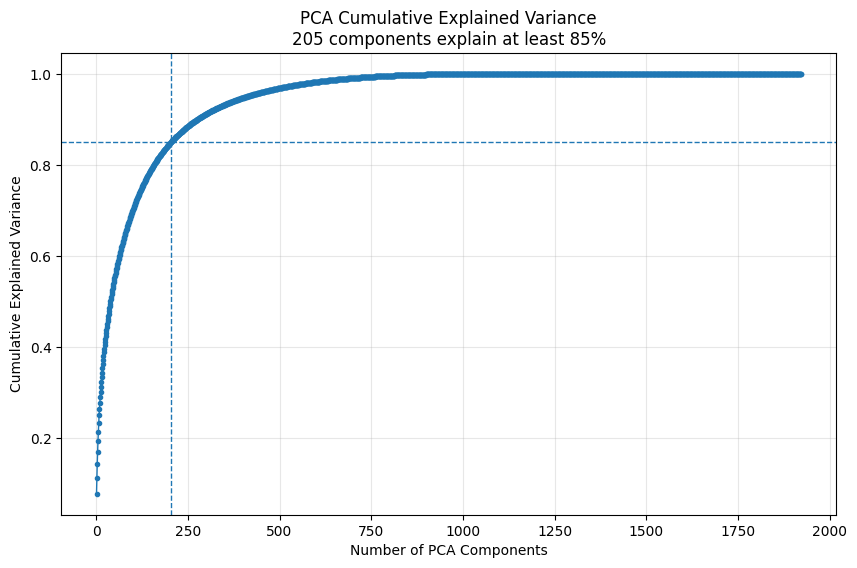

Saved: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\notebooks\mlb_local_outputs\eda\pca_cumulative_explained_variance.png


In [61]:
# ---------------------------------------------------------------------
# PCA explained variance plot
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    explained_df["component"],
    explained_df["cumulative_explained_variance"],
    marker="o",
    markersize=3,
    linewidth=1,
)

ax.axhline(PCA_VARIANCE_TARGET, linestyle="--", linewidth=1)
ax.axvline(n_components_80, linestyle="--", linewidth=1)

ax.set_title(f"PCA Cumulative Explained Variance\n{n_components_80} components explain at least {PCA_VARIANCE_TARGET:.0%}")
ax.set_xlabel("Number of PCA Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.grid(True, alpha=0.3)

plt.show()

# Optional save
pca_plot_path = EDA_DIR / "pca_cumulative_explained_variance.png"
fig.savefig(pca_plot_path, bbox_inches="tight", dpi=150)

print("Saved:", pca_plot_path.resolve())

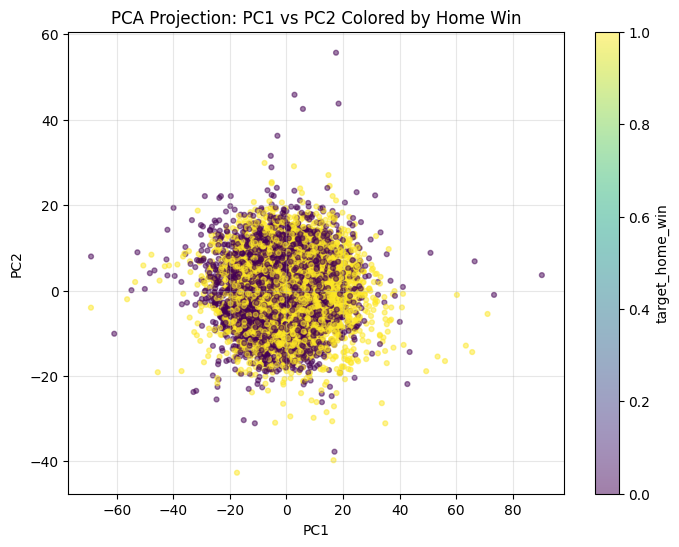

Saved: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\notebooks\mlb_local_outputs\eda\pca_pc1_pc2_home_win.png


In [62]:
# ---------------------------------------------------------------------
# Optional: project train/test into PC space and plot PC1 vs PC2
# ---------------------------------------------------------------------

X_pca_all = pca_pipe.transform(pca_completed[pca_feature_cols])

pc_scores = pd.DataFrame(
    X_pca_all[:, :5],
    columns=[f"PC{i}" for i in range(1, 6)],
    index=pca_completed.index,
)

pc_scores = pd.concat(
    [
        pca_completed[[
            "official_date",
            "target_home_win",
            "target_total_runs",
            "target_home_margin",
        ]].reset_index(drop=True),
        pc_scores.reset_index(drop=True),
    ],
    axis=1,
)

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    pc_scores["PC1"],
    pc_scores["PC2"],
    c=pc_scores["target_home_win"],
    alpha=0.5,
    s=12,
)

ax.set_title("PCA Projection: PC1 vs PC2 Colored by Home Win")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(True, alpha=0.3)

plt.colorbar(scatter, ax=ax, label="target_home_win")
plt.show()

pca_scatter_path = EDA_DIR / "pca_pc1_pc2_home_win.png"
fig.savefig(pca_scatter_path, bbox_inches="tight", dpi=150)

print("Saved:", pca_scatter_path.resolve())

In [63]:
# ---------------------------------------------------------------------
# Refit compact PCA transformer with only the number of components needed for 80%
# ---------------------------------------------------------------------

pca_80_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components_80, random_state=RANDOM_STATE)),
])

pca_80_pipe.fit(pca_train_df[pca_feature_cols])

X_train_pca80 = pca_80_pipe.transform(pca_train_df[pca_feature_cols])
X_test_pca80 = pca_80_pipe.transform(pca_test_df[pca_feature_cols])

print("X_train_pca80:", X_train_pca80.shape)
print("X_test_pca80:", X_test_pca80.shape)

X_train_pca80: (6685, 205)
X_test_pca80: (1672, 205)


## 14. Train/test split helpers and baselines

In [65]:
from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    accuracy_score,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_poisson_deviance,
)


def completed_for_target(df, target_col):
    d = df[df[target_col].notna()].copy()
    if MIN_TRAIN_DATE is not None and "official_date" in d.columns:
        d = d[d["official_date"] >= pd.to_datetime(MIN_TRAIN_DATE)].copy()
    if "official_date" in d.columns:
        d = d.sort_values(["official_date", "game_datetime_utc" if "game_datetime_utc" in d.columns else "official_date"])
    return d.reset_index(drop=True)


def time_train_test_split(df, target_col):
    d = completed_for_target(df, target_col)
    if HOLDOUT_START_DATE is not None and "official_date" in d.columns:
        cutoff = pd.to_datetime(HOLDOUT_START_DATE)
        train = d[d["official_date"] < cutoff].copy()
        test = d[d["official_date"] >= cutoff].copy()
    else:
        split = int(len(d) * (1.0 - TEST_FRACTION))
        train = d.iloc[:split].copy()
        test = d.iloc[split:].copy()
    return train, test


def regression_metrics(y_true, pred, prefix=""):
    y = np.asarray(y_true, dtype=float)
    p = np.asarray(pred, dtype=float)
    mask = np.isfinite(y) & np.isfinite(p)
    y = y[mask]
    p = p[mask]
    out = {
        prefix + "mae": float(mean_absolute_error(y, p)),
        prefix + "rmse": float(np.sqrt(mean_squared_error(y, p))),
        prefix + "r2": float(r2_score(y, p)),
        prefix + "avg_pred": float(np.mean(p)),
        prefix + "actual_mean": float(np.mean(y)),
        prefix + "n": int(len(y)),
    }
    return out


def classification_metrics(y_true, prob, prefix=""):
    y = np.asarray(y_true, dtype=float)
    p = np.asarray(prob, dtype=float)
    mask = np.isfinite(y) & np.isfinite(p)
    y = y[mask]
    p = np.clip(p[mask], 1e-6, 1 - 1e-6)
    out = {
        prefix + "log_loss": float(log_loss(y, p)),
        prefix + "brier": float(brier_score_loss(y, p)),
        prefix + "accuracy": float(accuracy_score(y, p >= 0.5)),
        prefix + "auc": float(roc_auc_score(y, p)) if len(np.unique(y)) == 2 else np.nan,
        prefix + "avg_pred": float(np.mean(p)),
        prefix + "actual_mean": float(np.mean(y)),
        prefix + "n": int(len(y)),
    }
    return out

baseline_rows = []

if "target_home_win" in features.columns:
    train_ml, test_ml = time_train_test_split(features, "target_home_win")
    p_base = np.repeat(train_ml["target_home_win"].mean(), len(test_ml))
    row = {"target": "moneyline", "baseline": "train_home_win_rate"}
    row.update(classification_metrics(test_ml["target_home_win"], p_base))
    baseline_rows.append(row)

    if "elo_home_win_prob" in test_ml.columns:
        p_elo = test_ml["elo_home_win_prob"].clip(1e-6, 1 - 1e-6)
        row = {"target": "moneyline", "baseline": "elo_home_win_prob"}
        row.update(classification_metrics(test_ml["target_home_win"], p_elo))
        baseline_rows.append(row)

for target in ["target_total_runs", "target_home_margin"]:
    if target in features.columns:
        train_r, test_r = time_train_test_split(features, target)
        pred_base = np.repeat(train_r[target].mean(), len(test_r))
        row = {"target": target, "baseline": "train_mean"}
        row.update(regression_metrics(test_r[target], pred_base))
        baseline_rows.append(row)

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df)
baseline_df.to_csv(EDA_DIR / "baseline_metrics.csv", index=False)

,target,baseline,log_loss,brier,accuracy,auc,avg_pred,actual_mean,n,mae,rmse,r2
0,moneyline,train_home_win_rate,0.691168,0.249011,0.531699,0.500000,0.527749,0.531699,1672,NaN,NaN,NaN
1,moneyline,elo_home_win_prob,0.697833,0.251876,0.538278,0.548686,0.547757,0.531699,1672,NaN,NaN,NaN
2,target_total_runs,train_mean,NaN,NaN,NaN,NaN,8.965146,8.990431,1672,3.551227,4.486217,-0.000032
3,target_home_margin,train_mean,NaN,NaN,NaN,NaN,-0.004188,0.038278,1672,3.613902,4.541842,-0.000087


In [66]:
features.groupby('home_team_name')['game_pk'].count()

home_team_name
Arizona Diamondbacks     281
Atlanta Braves           278
Baltimore Orioles        284
Boston Red Sox           280
Chicago Cubs             281
Chicago White Sox        280
Cincinnati Reds          282
Cleveland Guardians      280
Colorado Rockies         277
Detroit Tigers           277
Houston Astros           281
Kansas City Royals       281
Los Angeles Angels       280
Los Angeles Dodgers      280
Miami Marlins            282
Milwaukee Brewers        282
Minnesota Twins          282
New York Mets            279
New York Yankees         278
Oakland Athletics        280
Philadelphia Phillies    282
Pittsburgh Pirates       282
San Diego Padres         281
San Francisco Giants     277
Seattle Mariners         280
St. Louis Cardinals      282
Tampa Bay Rays           276
Texas Rangers            276
Toronto Blue Jays        282
Washington Nationals     281
Name: game_pk, dtype: int64

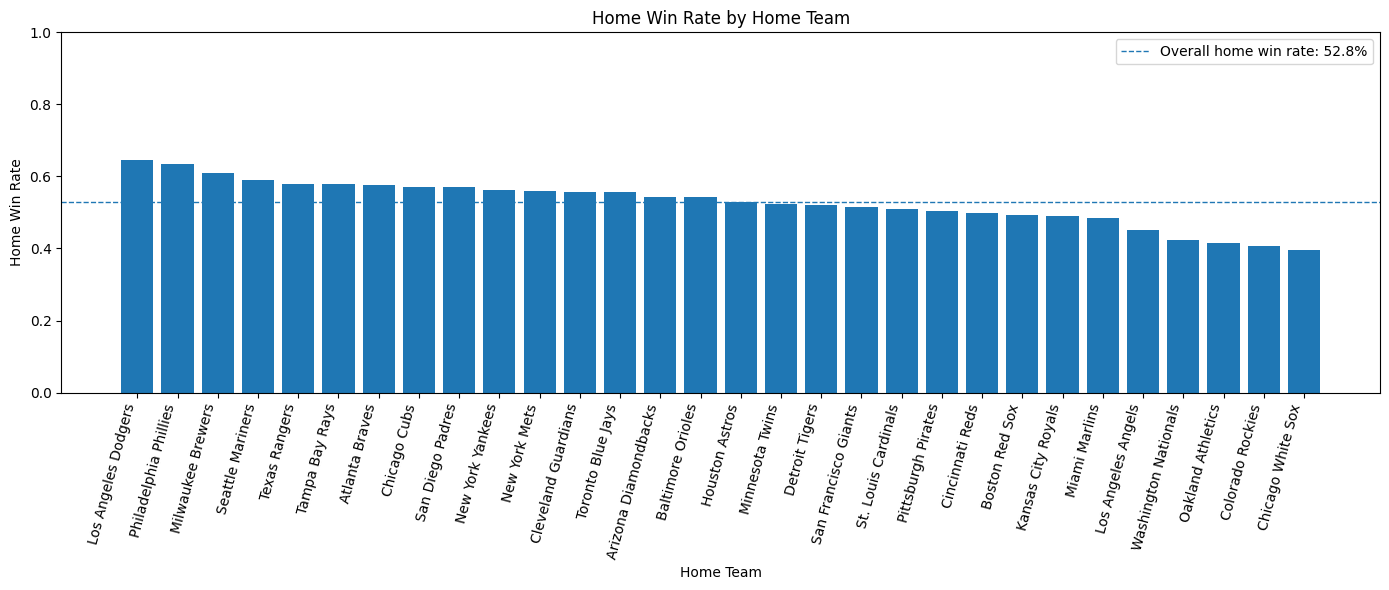

In [71]:
import seaborn as sns

plot_df = features[features['home_team_name'].notna() & features['home_win'].notna()].copy()
team_summary = (plot_df.groupby('home_team_name').agg(home_games=("game_pk", "count"), home_win_rate=("home_win", "mean")).sort_values("home_win_rate", ascending=False))
fig, ax = plt.subplots(figsize=(14,6))
ax.bar(team_summary.index, team_summary['home_win_rate'])
overall_home_win_rate = plot_df['home_win'].mean()
ax.axhline(overall_home_win_rate, linestyle='--', linewidth=1, label=f"Overall home win rate: {overall_home_win_rate:.1%}",
           )
ax.set_title("Home Win Rate by Home Team")
ax.set_xlabel("Home Team")
ax.set_ylabel("Home Win Rate")
ax.set_ylim(0,1)
ax.tick_params(axis="x", rotation=75)
for label in ax.get_xticklabels():
    label.set_ha("right")

ax.legend()
plt.tight_layout()
plt.show()

In [74]:
import numpy as np
import pandas as pd

def add_team_ewm_features_to_features(
    features: pd.DataFrame,
    half_lives=(15, 30, 60, 120),
    time_col="game_datetime_utc",
    date_col="official_date",
) -> pd.DataFrame:
    """
    Adds leakage-safe team EWMA features to the main game-level features dataframe.

    For each game:
    - home_team_ewm_* values use only the home team's prior completed games.
    - away_team_ewm_* values use only the away team's prior completed games.
    - diff_team_ewm_* = home - away.

    Uses completed historical games to compute postgame EWMA states, then merge-as-of
    those states into every scheduled/completed game with allow_exact_matches=False.
    """
    d = features.copy()

    required = [
        "game_pk",
        date_col,
        "home_team_name",
        "away_team_name",
        "target_home_win",
        "home_score",
        "away_score",
    ]

    missing = [c for c in required if c not in d.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if time_col not in d.columns:
        d[time_col] = pd.to_datetime(d[date_col], errors="coerce", utc=True)
    else:
        d[time_col] = pd.to_datetime(d[time_col], errors="coerce", utc=True)

    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")

    # Remove existing EWMA columns if rerunning.
    existing_ewm_cols = [c for c in d.columns if "_ewm_" in c]
    if existing_ewm_cols:
        print(f"Dropping existing EWMA columns before rebuild: {len(existing_ewm_cols)}")
        d = d.drop(columns=existing_ewm_cols)

    completed = d[
        d["target_home_win"].notna()
        & d["home_score"].notna()
        & d["away_score"].notna()
        & d[time_col].notna()
    ].copy()

    completed["target_home_win"] = completed["target_home_win"].astype(float)
    completed["home_score"] = completed["home_score"].astype(float)
    completed["away_score"] = completed["away_score"].astype(float)

    # Long team-game history, one row per team per completed game.
    home = completed[["game_pk", date_col, time_col, "home_team_name", "away_team_name", "target_home_win", "home_score", "away_score"]].copy()
    home["team_name"] = home["home_team_name"]
    home["opponent_name"] = home["away_team_name"]
    home["is_home"] = 1
    home["team_win"] = home["target_home_win"]
    home["runs_for"] = home["home_score"]
    home["runs_against"] = home["away_score"]

    away = completed[["game_pk", date_col, time_col, "home_team_name", "away_team_name", "target_home_win", "home_score", "away_score"]].copy()
    away["team_name"] = away["away_team_name"]
    away["opponent_name"] = away["home_team_name"]
    away["is_home"] = 0
    away["team_win"] = 1.0 - away["target_home_win"]
    away["runs_for"] = away["away_score"]
    away["runs_against"] = away["home_score"]

    team_games = pd.concat([home, away], ignore_index=True)

    team_games["run_diff"] = team_games["runs_for"] - team_games["runs_against"]
    team_games["total_runs"] = team_games["runs_for"] + team_games["runs_against"]
    team_games["scored_5plus"] = (team_games["runs_for"] >= 5).astype(float)
    team_games["allowed_5plus"] = (team_games["runs_against"] >= 5).astype(float)

    team_games = team_games.sort_values(["team_name", time_col, "game_pk"]).reset_index(drop=True)

    metric_cols = [
        "team_win",
        "runs_for",
        "runs_against",
        "run_diff",
        "total_runs",
        "scored_5plus",
        "allowed_5plus",
    ]

    # Postgame EWMA state after each completed game.
    ewm_cols = []

    for hl in half_lives:
        for metric in metric_cols:
            out_col = f"ewm_{metric}_hl{hl}"
            team_games[out_col] = (
                team_games
                .groupby("team_name", group_keys=False)[metric]
                .apply(lambda s: s.ewm(halflife=hl, adjust=False).mean())
            )
            ewm_cols.append(out_col)

    history = team_games[["team_name", time_col] + ewm_cols].copy()
    history = history.sort_values(["team_name", time_col]).reset_index(drop=True)

    # Schedule/game rows in team perspective for every row in features.
    sched_home = d[["game_pk", time_col, "home_team_name", "away_team_name"]].copy()
    sched_home["team_name"] = sched_home["home_team_name"]
    sched_home["side"] = "home"

    sched_away = d[["game_pk", time_col, "home_team_name", "away_team_name"]].copy()
    sched_away["team_name"] = sched_away["away_team_name"]
    sched_away["side"] = "away"

    sched_long = pd.concat([sched_home, sched_away], ignore_index=True)
    sched_long = sched_long[sched_long[time_col].notna()].copy()

    # Robust merge_asof by team.
    merged_parts = []

    for team, s in sched_long.groupby("team_name", sort=False):
        s = s.sort_values(time_col).copy()
        h = history[history["team_name"].eq(team)].sort_values(time_col).copy()

        if h.empty:
            for c in ewm_cols:
                s[c] = np.nan
            merged_parts.append(s)
            continue

        h = h[[time_col] + ewm_cols].copy()

        m = pd.merge_asof(
            s,
            h,
            on=time_col,
            direction="backward",
            allow_exact_matches=False,
        )

        merged_parts.append(m)

    sched_with_ewm = pd.concat(merged_parts, ignore_index=True)

    home_ewm = (
        sched_with_ewm[sched_with_ewm["side"].eq("home")]
        [["game_pk"] + ewm_cols]
        .drop_duplicates("game_pk")
        .rename(columns={c: f"home_team_{c}" for c in ewm_cols})
    )

    away_ewm = (
        sched_with_ewm[sched_with_ewm["side"].eq("away")]
        [["game_pk"] + ewm_cols]
        .drop_duplicates("game_pk")
        .rename(columns={c: f"away_team_{c}" for c in ewm_cols})
    )

    out = d.merge(home_ewm, on="game_pk", how="left")
    out = out.merge(away_ewm, on="game_pk", how="left")

    for c in ewm_cols:
        h = f"home_team_{c}"
        a = f"away_team_{c}"
        diff = f"diff_team_{c}"

        if h in out.columns and a in out.columns:
            out[diff] = out[h] - out[a]

    print("EWMA columns added:", len([c for c in out.columns if "_ewm_" in c]))
    return out

In [75]:
features = add_team_ewm_features_to_features(
    features,
    half_lives=(15, 30, 60, 120),
)

ewm_cols = [c for c in features.columns if "_ewm_" in c]
print("EWMA feature count:", len(ewm_cols))

display(
    features[
        ["official_date", "home_team_name", "away_team_name"] + ewm_cols[:20]
    ].head(20)
)

EWMA columns added: 84
EWMA feature count: 84


,official_date,home_team_name,away_team_name,home_team_ewm_team_win_hl15,home_team_ewm_runs_for_hl15,home_team_ewm_runs_against_hl15,home_team_ewm_run_diff_hl15,home_team_ewm_total_runs_hl15,home_team_ewm_scored_5plus_hl15,home_team_ewm_allowed_5plus_hl15,...,home_team_ewm_run_diff_hl30,home_team_ewm_total_runs_hl30,home_team_ewm_scored_5plus_hl30,home_team_ewm_allowed_5plus_hl30,home_team_ewm_team_win_hl60,home_team_ewm_runs_for_hl60,home_team_ewm_runs_against_hl60,home_team_ewm_run_diff_hl60,home_team_ewm_total_runs_hl60,home_team_ewm_scored_5plus_hl60
0,2023-03-30,Washington Nationals,Atlanta Braves,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-03-30,New York Yankees,San Francisco Giants,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-03-30,Boston Red Sox,Baltimore Orioles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-03-30,Chicago Cubs,Milwaukee Brewers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-03-30,Tampa Bay Rays,Detroit Tigers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2023-03-30,Texas Rangers,Philadelphia Phillies,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2023-03-30,Cincinnati Reds,Pittsburgh Pirates,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2023-03-30,St. Louis Cardinals,Toronto Blue Jays,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2023-03-30,Kansas City Royals,Minnesota Twins,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2023-03-30,Miami Marlins,New York Mets,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
def make_team_perspective_for_clustering(features: pd.DataFrame) -> pd.DataFrame:
    d = features.copy()
    d["official_date"] = pd.to_datetime(d["official_date"], errors="coerce")

    if "game_datetime_utc" in d.columns:
        d["game_datetime_utc"] = pd.to_datetime(d["game_datetime_utc"], errors="coerce", utc=True)
    else:
        d["game_datetime_utc"] = pd.to_datetime(d["official_date"], errors="coerce", utc=True)

    base_cols = [
        "game_pk",
        "official_date",
        "game_datetime_utc",
        "home_team_name",
        "away_team_name",
        "target_home_win",
        "target_total_runs",
        "target_home_margin",
    ]

    base_cols = [c for c in base_cols if c in d.columns]

    home = d[base_cols].copy()
    home["team_name"] = d["home_team_name"]
    home["opponent_name"] = d["away_team_name"]
    home["is_home"] = 1
    home["target_team_win"] = d["target_home_win"]

    away = d[base_cols].copy()
    away["team_name"] = d["away_team_name"]
    away["opponent_name"] = d["home_team_name"]
    away["is_home"] = 0
    away["target_team_win"] = 1.0 - d["target_home_win"]

    # Map home/away columns into team-perspective columns.
    mapping_specs = [
        ("home_team_ewm_", "away_team_ewm_", "team_ewm_"),
        ("home_elo", "away_elo", "team_elo"),
        ("home_team_sc_", "away_team_sc_", "team_sc_"),
        ("home_team_pitchmix_", "away_team_pitchmix_", "team_pitchmix_"),
        ("home_starter_", "away_starter_", "team_starter_"),
        ("home_box_", "away_box_", "team_box_"),
        ("home_team_team_", "away_team_team_", "team_form_"),
    ]

    for home_prefix, away_prefix, team_prefix in mapping_specs:
        home_cols = [c for c in d.columns if c.startswith(home_prefix)]
        for hc in home_cols:
            ac = away_prefix + hc[len(home_prefix):]
            tc = team_prefix + hc[len(home_prefix):]

            if ac in d.columns:
                home[tc] = d[hc]
                away[tc] = d[ac]

    # Useful opponent/relative features.
    if "home_elo_pre" in d.columns and "away_elo_pre" in d.columns:
        home["opp_elo_pre"] = d["away_elo_pre"]
        away["opp_elo_pre"] = d["home_elo_pre"]
        home["team_minus_opp_elo_pre"] = d["home_elo_pre"] - d["away_elo_pre"]
        away["team_minus_opp_elo_pre"] = d["away_elo_pre"] - d["home_elo_pre"]

    team_long = pd.concat([home, away], ignore_index=True)
    team_long = team_long.sort_values(["team_name", "game_datetime_utc", "game_pk"]).reset_index(drop=True)

    return team_long

In [30]:
# ---------------------------------------------------------------------
# Create chronological train/test split for PCA/model comparison
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd

REQUIRED_TARGETS = [
    "target_home_win",
    "target_total_runs",
    "target_home_margin",
]

missing_targets = [c for c in REQUIRED_TARGETS if c not in features.columns]
assert not missing_targets, f"Missing target columns: {missing_targets}"

model_df = features.copy()
model_df["official_date"] = pd.to_datetime(model_df["official_date"], errors="coerce")

# Use only completed games with all three targets available.
model_df = model_df[
    model_df["official_date"].notna()
    & model_df["target_home_win"].notna()
    & model_df["target_total_runs"].notna()
    & model_df["target_home_margin"].notna()
].sort_values("official_date").reset_index(drop=True)

if MIN_TRAIN_DATE is not None:
    model_df = model_df[
        model_df["official_date"] >= pd.to_datetime(MIN_TRAIN_DATE)
    ].copy()

print("Model dataframe:", model_df.shape)
print("Date range:", model_df["official_date"].min(), "to", model_df["official_date"].max())

# ---------------------------------------------------------------------
# Build candidate features if they do not already exist
# ---------------------------------------------------------------------

TARGET_COLS = {
    "target_home_win",
    "target_total_runs",
    "target_home_margin",
    "home_score",
    "away_score",
    "home_win",
    "away_win",
    "home_run_diff",
    "away_run_diff",
}

NON_FEATURE_COLS = {
    "game_pk",
    "official_date",
    "game_datetime_utc",
    "home_team_name",
    "away_team_name",
    "home_team_norm",
    "away_team_norm",
    "status_code",
    "detailed_state",
}

def is_leaky_or_id_col(c: str) -> bool:
    c_low = str(c).lower()

    if c in TARGET_COLS or c in NON_FEATURE_COLS:
        return True

    if c_low.endswith("_id") and not INCLUDE_NUMERIC_ID_FEATURES:
        return True

    # Exact/postgame leakage patterns.
    bad_contains = [
        "target_",
        "actual_",
        "final_",
        "postgame",
        "post_game",
    ]

    return any(x in c_low for x in bad_contains)

numeric_cols = model_df.select_dtypes(include=[np.number]).columns.tolist()

candidate_feature_cols = [
    c for c in numeric_cols
    if not is_leaky_or_id_col(c)
]

# Drop all-null / high-missing / constant features.
missing_rate = model_df[candidate_feature_cols].isna().mean()

candidate_feature_cols = [
    c for c in candidate_feature_cols
    if missing_rate[c] <= DROP_FEATURES_MISSING_ABOVE
]

if DROP_CONSTANT_FEATURES:
    nunique = model_df[candidate_feature_cols].nunique(dropna=True)
    candidate_feature_cols = [
        c for c in candidate_feature_cols
        if nunique[c] > 1
    ]

print("Candidate feature count:", len(candidate_feature_cols))

# ---------------------------------------------------------------------
# Chronological split
# ---------------------------------------------------------------------

if HOLDOUT_START_DATE is not None:
    holdout_start = pd.to_datetime(HOLDOUT_START_DATE)

    train_df = model_df[model_df["official_date"] < holdout_start].copy()
    test_df = model_df[model_df["official_date"] >= holdout_start].copy()
else:
    split_idx = int(len(model_df) * (1 - TEST_FRACTION))

    train_df = model_df.iloc[:split_idx].copy()
    test_df = model_df.iloc[split_idx:].copy()

print("train_df:", train_df.shape, train_df["official_date"].min(), "to", train_df["official_date"].max())
print("test_df:", test_df.shape, test_df["official_date"].min(), "to", test_df["official_date"].max())

assert len(train_df) > 0, "train_df is empty"
assert len(test_df) > 0, "test_df is empty"

X_train = train_df[candidate_feature_cols]
X_test = test_df[candidate_feature_cols]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Model dataframe: (8357, 2049)
Date range: 2023-03-30 00:00:00 to 2026-06-14 00:00:00
Candidate feature count: 1938
train_df: (6685, 2049) 2023-03-30 00:00:00 to 2025-08-15 00:00:00
test_df: (1672, 2049) 2025-08-15 00:00:00 to 2026-06-14 00:00:00
X_train: (6685, 1938)
X_test: (1672, 1938)


In [77]:
team_long = make_team_perspective_for_clustering(features)

print("team_long:", team_long.shape)
display(team_long.head())
display(team_long.groupby("team_name")["game_pk"].count().sort_values())

team_long: (16808, 716)


,game_pk,official_date,game_datetime_utc,home_team_name,away_team_name,target_home_win,target_total_runs,target_home_margin,team_name,opponent_name,...,team_form_win_last5,team_form_win_last10,team_form_win_last20,team_form_run_diff_season_to_date,team_form_run_diff_last3,team_form_run_diff_last5,team_form_run_diff_last10,team_form_run_diff_last20,opp_elo_pre,team_minus_opp_elo_pre
0,718770,2023-03-30,2023-03-31 02:10:00+00:00,Los Angeles Dodgers,Arizona Diamondbacks,1.0,10.0,6.0,Arizona Diamondbacks,Los Angeles Dodgers,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.000000,0.000000
1,718765,2023-03-31,2023-04-01 02:10:00+00:00,Los Angeles Dodgers,Arizona Diamondbacks,0.0,3.0,-1.0,Arizona Diamondbacks,Los Angeles Dodgers,...,0.000000,0.000000,0.000000,-6.000000,-6.000000,-6.000000,-6.000000,-6.000000,1508.996013,-17.992026
2,718749,2023-04-01,2023-04-02 01:10:00+00:00,Los Angeles Dodgers,Arizona Diamondbacks,1.0,11.0,9.0,Arizona Diamondbacks,Los Angeles Dodgers,...,0.500000,0.500000,0.500000,-2.500000,-2.500000,-2.500000,-2.500000,-2.500000,1497.482498,5.035004
3,718736,2023-04-02,2023-04-02 20:10:00+00:00,Los Angeles Dodgers,Arizona Diamondbacks,0.0,3.0,-1.0,Arizona Diamondbacks,Los Angeles Dodgers,...,0.333333,0.333333,0.333333,-4.666667,-4.666667,-4.666667,-4.666667,-4.666667,1506.622168,-13.244337
4,718722,2023-04-03,2023-04-04 01:40:00+00:00,San Diego Padres,Arizona Diamondbacks,1.0,9.0,1.0,Arizona Diamondbacks,San Diego Padres,...,0.500000,0.500000,0.500000,-3.250000,-2.333333,-3.250000,-3.250000,-3.250000,1498.480321,6.277238


team_name
Milwaukee Brewers        558
Boston Red Sox           559
Chicago White Sox        559
San Diego Padres         559
Texas Rangers            559
Tampa Bay Rays           559
Cincinnati Reds          560
Atlanta Braves           560
New York Yankees         560
Oakland Athletics        560
Philadelphia Phillies    560
San Francisco Giants     560
New York Mets            560
Arizona Diamondbacks     560
Toronto Blue Jays        560
St. Louis Cardinals      560
Baltimore Orioles        561
Miami Marlins            561
Los Angeles Angels       561
Los Angeles Dodgers      561
Detroit Tigers           561
Kansas City Royals       561
Colorado Rockies         561
Cleveland Guardians      561
Seattle Mariners         561
Chicago Cubs             561
Pittsburgh Pirates       561
Minnesota Twins          561
Washington Nationals     561
Houston Astros           562
Name: game_pk, dtype: int64

In [78]:
def make_recency_weights(dates, half_life_days=365):
    dates = pd.to_datetime(dates, errors="coerce")
    max_date = dates.max()
    age_days = (max_date - dates).dt.days.clip(lower=0)
    return np.power(0.5, age_days / half_life_days)


def weighted_nanmean(values, weights):
    v = pd.to_numeric(values, errors="coerce").to_numpy(dtype=float)
    w = np.asarray(weights, dtype=float)

    mask = np.isfinite(v) & np.isfinite(w) & (w > 0)

    if mask.sum() == 0:
        return np.nan

    return np.average(v[mask], weights=w[mask])


def build_recent_weighted_team_profiles(
    team_long: pd.DataFrame,
    profile_cols,
    half_life_days=365,
    min_non_missing_rate=0.50,
) -> pd.DataFrame:
    d = team_long.copy()
    d["official_date"] = pd.to_datetime(d["official_date"], errors="coerce")

    d = d[d["official_date"].notna()].copy()
    d["recency_weight"] = make_recency_weights(d["official_date"], half_life_days=half_life_days)

    usable_cols = []

    for c in profile_cols:
        if c not in d.columns:
            continue

        if not pd.api.types.is_numeric_dtype(d[c]):
            continue

        non_missing = d[c].notna().mean()

        if non_missing >= min_non_missing_rate and d[c].nunique(dropna=True) > 1:
            usable_cols.append(c)

    print("Usable profile columns:", len(usable_cols))

    rows = []

    for team, g in d.groupby("team_name"):
        row = {
            "team_name": team,
            "n_games": len(g),
            "date_min": g["official_date"].min(),
            "date_max": g["official_date"].max(),
            "weighted_target_team_win": weighted_nanmean(g["target_team_win"], g["recency_weight"])
                if "target_team_win" in g.columns else np.nan,
            "raw_target_team_win": g["target_team_win"].mean()
                if "target_team_win" in g.columns else np.nan,
        }

        w = g["recency_weight"].to_numpy(dtype=float)

        for c in usable_cols:
            row[c] = weighted_nanmean(g[c], w)

        rows.append(row)

    profile = pd.DataFrame(rows)

    return profile, usable_cols

In [79]:
cluster_candidate_cols = [
    c for c in team_long.columns
    if pd.api.types.is_numeric_dtype(team_long[c])
    and (
        c.startswith("team_ewm_")
        or c.startswith("team_elo")
        or c.startswith("team_sc_")
        or c.startswith("team_pitchmix_")
        or c.startswith("team_starter_")
    )
]

# Prefer recent windows / EWMA / compact signals.
preferred_cluster_cols = [
    c for c in cluster_candidate_cols
    if (
        "_hl30" in c
        or "_hl60" in c
        or "_last10" in c
        or "_last20" in c
        or "season_to_date" in c
        or "elo" in c
    )
]

print("Cluster candidate cols:", len(cluster_candidate_cols))
print("Preferred cluster cols:", len(preferred_cluster_cols))

team_profile, cluster_input_cols = build_recent_weighted_team_profiles(
    team_long,
    preferred_cluster_cols,
    half_life_days=365,
    min_non_missing_rate=0.50,
)

print("team_profile:", team_profile.shape)
display(team_profile[["team_name", "n_games", "raw_target_team_win", "weighted_target_team_win"]].sort_values("weighted_target_team_win", ascending=False))

Cluster candidate cols: 307
Preferred cluster cols: 169
Usable profile columns: 165
team_profile: (30, 171)


,team_name,n_games,raw_target_team_win,weighted_target_team_win
15,Milwaukee Brewers,558,0.585586,0.599829
13,Los Angeles Dodgers,561,0.602151,0.599576
18,New York Yankees,560,0.562950,0.583377
20,Philadelphia Phillies,560,0.572711,0.570915
1,Atlanta Braves,560,0.565530,0.558060
22,San Diego Padres,559,0.543165,0.546484
7,Cleveland Guardians,561,0.529623,0.541561
24,Seattle Mariners,561,0.536673,0.535218
4,Chicago Cubs,561,0.528674,0.533028
26,Tampa Bay Rays,559,0.536101,0.528213


In [80]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_cluster = team_profile[cluster_input_cols].copy()

cluster_scores = []

for k in range(2, 9):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)),
    ])

    labels = pipe.fit_predict(X_cluster)

    X_scaled = pipe.named_steps["scaler"].transform(
        pipe.named_steps["imputer"].transform(X_cluster)
    )

    sil = silhouette_score(X_scaled, labels)

    cluster_scores.append({
        "k": k,
        "silhouette": sil,
        "inertia": pipe.named_steps["kmeans"].inertia_,
    })

cluster_scores_df = pd.DataFrame(cluster_scores)
display(cluster_scores_df)

,k,silhouette,inertia
0,2,0.128261,4092.024126
1,3,0.097321,3623.840878
2,4,0.078311,3306.957742
3,5,0.081292,3016.573237
4,6,0.069889,2785.498732
5,7,0.058612,2573.331418
6,8,0.053590,2407.942187


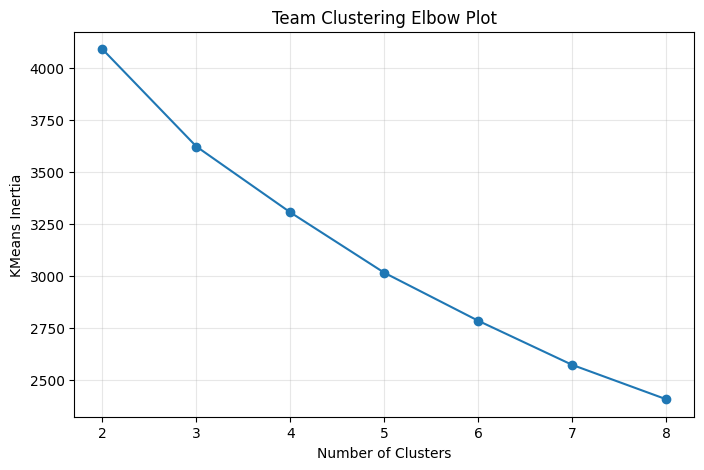

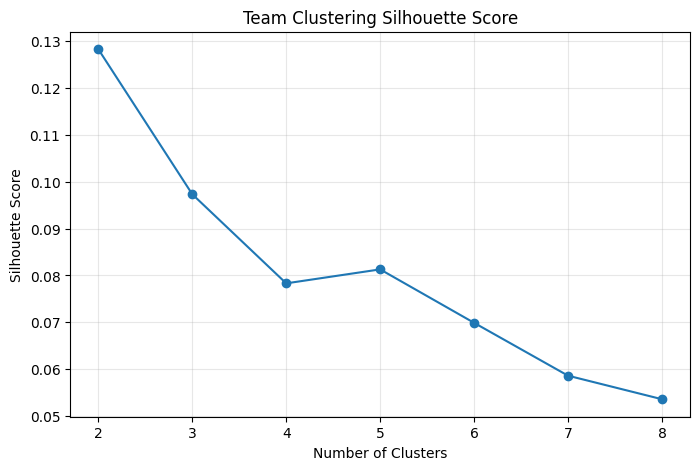

In [81]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cluster_scores_df["k"], cluster_scores_df["inertia"], marker="o")
ax.set_title("Team Clustering Elbow Plot")
ax.set_xlabel("Number of Clusters")
ax.set_ylabel("KMeans Inertia")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cluster_scores_df["k"], cluster_scores_df["silhouette"], marker="o")
ax.set_title("Team Clustering Silhouette Score")
ax.set_xlabel("Number of Clusters")
ax.set_ylabel("Silhouette Score")
ax.grid(True, alpha=0.3)
plt.show()

In [84]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Choose cluster count
K_TEAM_CLUSTERS = 2   # silhouette plot suggests 2 is best

# Refit clustering pipeline
team_cluster_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(
        n_clusters=K_TEAM_CLUSTERS,
        random_state=RANDOM_STATE,
        n_init=50,
    )),
])

X_cluster = team_profile[cluster_input_cols].copy()

team_profile = team_profile.copy()
team_profile["team_cluster"] = team_cluster_pipe.fit_predict(X_cluster)

# Transform the same scaled feature space into 2D for visualization
X_imputed = team_cluster_pipe.named_steps["imputer"].transform(X_cluster)
X_scaled = team_cluster_pipe.named_steps["scaler"].transform(X_imputed)

pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
xy = pca_vis.fit_transform(X_scaled)

team_profile["cluster_x"] = xy[:, 0]
team_profile["cluster_y"] = xy[:, 1]

print("PCA visual explained variance:")
print("PC1:", round(pca_vis.explained_variance_ratio_[0], 4))
print("PC2:", round(pca_vis.explained_variance_ratio_[1], 4))
print("Combined:", round(pca_vis.explained_variance_ratio_[:2].sum(), 4))

PCA visual explained variance:
PC1: 0.2863
PC2: 0.1091
Combined: 0.3954


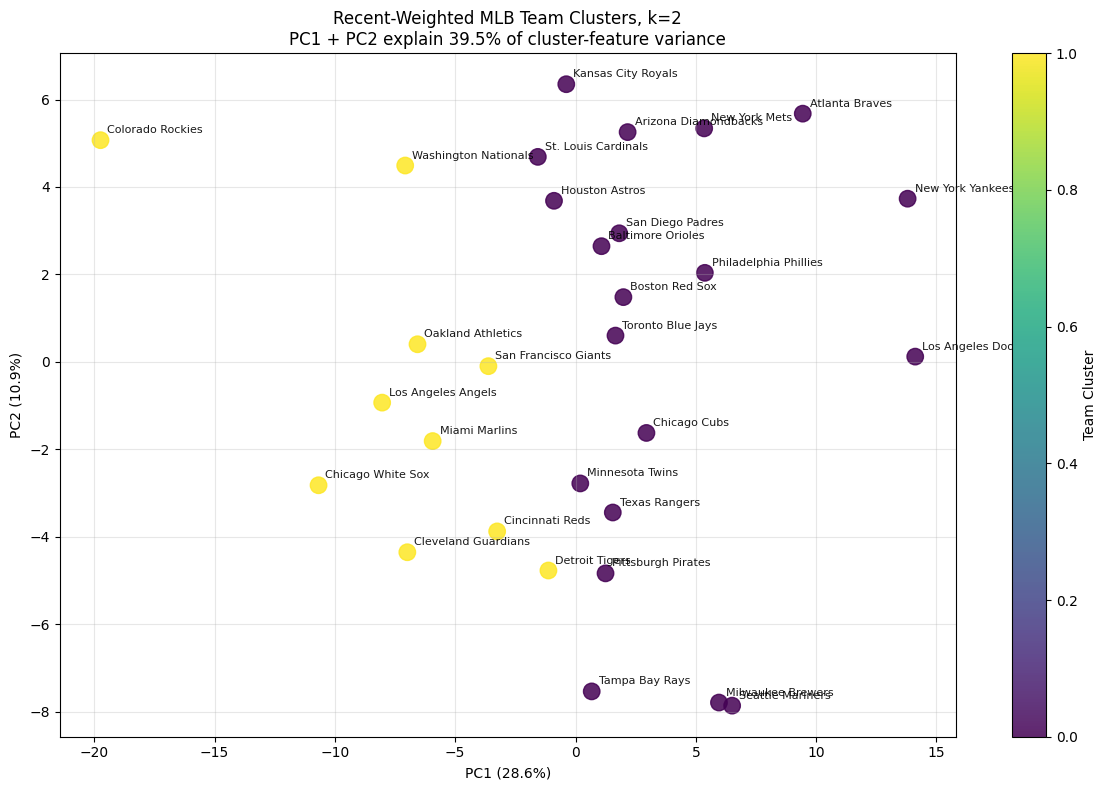

In [85]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    team_profile["cluster_x"],
    team_profile["cluster_y"],
    c=team_profile["team_cluster"],
    s=140,
    alpha=0.85,
)

for _, row in team_profile.iterrows():
    ax.annotate(
        row["team_name"],
        (row["cluster_x"], row["cluster_y"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        alpha=0.9,
    )

ax.set_title(
    f"Recent-Weighted MLB Team Clusters, k={K_TEAM_CLUSTERS}\n"
    f"PC1 + PC2 explain {pca_vis.explained_variance_ratio_[:2].sum():.1%} of cluster-feature variance"
)

ax.set_xlabel(f"PC1 ({pca_vis.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_vis.explained_variance_ratio_[1]:.1%})")
ax.grid(True, alpha=0.3)

plt.colorbar(scatter, ax=ax, label="Team Cluster")
plt.tight_layout()
plt.show()

In [87]:
cluster_win_summary = (
    team_profile
    .groupby("team_cluster")
    .agg(
        n_teams=("team_name", "count"),
        avg_raw_win_rate=("raw_target_team_win", "mean"),
        avg_recent_weighted_win_rate=("weighted_target_team_win", "mean"),
        std_recent_weighted_win_rate=("weighted_target_team_win", "std"),
        min_recent_weighted_win_rate=("weighted_target_team_win", "min"),
        max_recent_weighted_win_rate=("weighted_target_team_win", "max"),
        teams=("team_name", lambda x: ", ".join(x)),
    )
    .reset_index()
    .sort_values("avg_recent_weighted_win_rate", ascending=False)
)

display(cluster_win_summary)

,team_cluster,n_teams,avg_raw_win_rate,avg_recent_weighted_win_rate,std_recent_weighted_win_rate,min_recent_weighted_win_rate,max_recent_weighted_win_rate,teams
0,0,20,0.527346,0.523993,0.042238,0.459488,0.599829,"Arizona Diamondbacks, Atlanta Braves, Baltimor..."
1,1,10,0.445368,0.452236,0.057105,0.332797,0.541561,"Chicago White Sox, Cincinnati Reds, Cleveland ..."


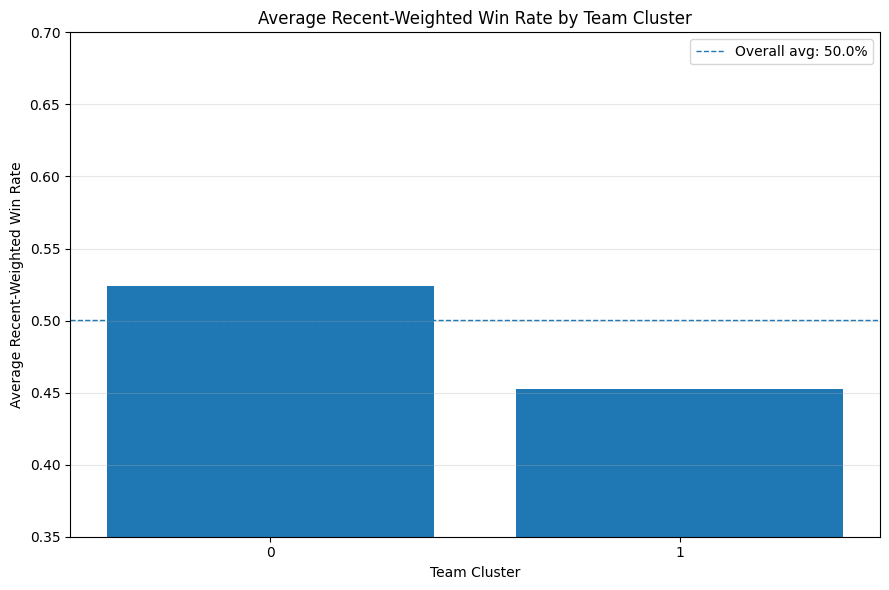

In [88]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = cluster_win_summary.copy()
plot_df["team_cluster"] = plot_df["team_cluster"].astype(str)

fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(
    plot_df["team_cluster"],
    plot_df["avg_recent_weighted_win_rate"],
)

overall_rate = team_profile["weighted_target_team_win"].mean()

ax.axhline(
    overall_rate,
    linestyle="--",
    linewidth=1,
    label=f"Overall avg: {overall_rate:.1%}",
)

ax.set_title("Average Recent-Weighted Win Rate by Team Cluster")
ax.set_xlabel("Team Cluster")
ax.set_ylabel("Average Recent-Weighted Win Rate")
ax.set_ylim(0.35, 0.70)
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
plot_df = team_profile[
    ["team_name", "team_cluster", "raw_target_team_win", "weighted_target_team_win"]
].dropna().copy()

plot_df["team_cluster_str"] = plot_df["team_cluster"].astype(str)

cluster_order = (
    plot_df
    .groupby("team_cluster_str")["weighted_target_team_win"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(10, 6))

for i, cluster_id in enumerate(cluster_order):
    g = plot_df[plot_df["team_cluster_str"].eq(cluster_id)].copy()

    # deterministic jitter
    x = np.repeat(i, len(g)) + np.linspace(-0.10, 0.10, len(g))

    ax.scatter(
        x,
        g["weighted_target_team_win"],
        s=90,
        alpha=0.80,
    )

    cluster_mean = g["weighted_target_team_win"].mean()

    ax.hlines(
        cluster_mean,
        i - 0.25,
        i + 0.25,
        linewidth=3,
    )

    for x_i, (_, row) in zip(x, g.iterrows()):
        ax.annotate(
            row["team_name"],
            (x_i, row["weighted_target_team_win"]),
            xytext=(4, 3),
            textcoords="offset points",
            fontsize=8,
            alpha=0.85,
        )

ax.set_xticks(range(len(cluster_order)))
ax.set_xticklabels(cluster_order)

ax.set_title("Team Recent-Weighted Win Rate by Cluster")
ax.set_xlabel("Team Cluster")
ax.set_ylabel("Recent-Weighted Win Rate")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score,
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import numpy as np
import pandas as pd

N_COMPONENTS_PCA_85 = 205

def evaluate_moneyline_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    p = model.predict_proba(X_test)[:, 1]
    p = np.clip(p, 0.001, 0.999)

    return {
        "model_name": name,
        "target": "moneyline",
        "log_loss": log_loss(y_test, p),
        "brier": brier_score_loss(y_test, p),
        "auc": roc_auc_score(y_test, p),
        "accuracy": accuracy_score(y_test, p >= 0.5),
        "avg_pred": p.mean(),
        "actual_mean": y_test.mean(),
    }


def evaluate_regression_model(name, model, X_train, y_train, X_test, y_test, target_name):
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    return {
        "model_name": name,
        "target": target_name,
        "mae": mean_absolute_error(y_test, pred),
        "rmse": np.sqrt(mean_squared_error(y_test, pred)),
        "r2": r2_score(y_test, pred),
        "avg_pred": pred.mean(),
        "actual_mean": y_test.mean(),
    }


# Use your existing train/test frames and candidate_feature_cols.
X_train = train_df[candidate_feature_cols]
X_test = test_df[candidate_feature_cols]

results = []

# -----------------------------
# Moneyline: raw logistic
# -----------------------------
raw_logit = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, C=0.25)),
])

pca_logit = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=N_COMPONENTS_PCA_85, random_state=RANDOM_STATE)),
    ("model", LogisticRegression(max_iter=2000, C=0.25)),
])

results.append(
    evaluate_moneyline_model(
        "raw_features__logistic",
        raw_logit,
        X_train,
        train_df["target_home_win"],
        X_test,
        test_df["target_home_win"],
    )
)

results.append(
    evaluate_moneyline_model(
        "pca85__logistic",
        pca_logit,
        X_train,
        train_df["target_home_win"],
        X_test,
        test_df["target_home_win"],
    )
)

# -----------------------------
# Totals: raw ridge vs PCA ridge
# -----------------------------
raw_ridge_total = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=25.0)),
])

pca_ridge_total = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=N_COMPONENTS_PCA_85, random_state=RANDOM_STATE)),
    ("model", Ridge(alpha=25.0)),
])

results.append(
    evaluate_regression_model(
        "raw_features__ridge",
        raw_ridge_total,
        X_train,
        train_df["target_total_runs"],
        X_test,
        test_df["target_total_runs"],
        "total_runs",
    )
)

results.append(
    evaluate_regression_model(
        "pca85__ridge",
        pca_ridge_total,
        X_train,
        train_df["target_total_runs"],
        X_test,
        test_df["target_total_runs"],
        "total_runs",
    )
)

# -----------------------------
# Margin: raw ridge vs PCA ridge
# -----------------------------
raw_ridge_margin = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=25.0)),
])

pca_ridge_margin = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=N_COMPONENTS_PCA_85, random_state=RANDOM_STATE)),
    ("model", Ridge(alpha=25.0)),
])

results.append(
    evaluate_regression_model(
        "raw_features__ridge",
        raw_ridge_margin,
        X_train,
        train_df["target_home_margin"],
        X_test,
        test_df["target_home_margin"],
        "home_margin",
    )
)

results.append(
    evaluate_regression_model(
        "pca85__ridge",
        pca_ridge_margin,
        X_train,
        train_df["target_home_margin"],
        X_test,
        test_df["target_home_margin"],
        "home_margin",
    )
)

pca_model_comparison = pd.DataFrame(results)
display(pca_model_comparison)

pca_step = pca_logit.named_steps["pca"]

loadings = pd.DataFrame(
    pca_step.components_.T,
    index=candidate_feature_cols,
    columns=[f"PC{i}" for i in range(1, pca_step.components_.shape[0] + 1)]
)

for pc in ["PC1", "PC2", "PC3", "PC4", "PC5"]:
    print("\n", pc)
    display(
        loadings[[pc]]
        .assign(abs_loading=lambda d: d[pc].abs())
        .sort_values("abs_loading", ascending=False)
        .head(25)
    )

def feature_family(c):
    c = c.lower()
    if "elo" in c:
        return "elo"
    if "starter" in c:
        return "starter"
    if "pitchmix" in c:
        return "pitchmix"
    if "sc_team" in c or "statcast" in c:
        return "statcast"
    if "box" in c:
        return "boxscore"
    if "team_team" in c:
        return "team_form"
    if "odds" in c or "market" in c or "moneyline" in c:
        return "market"
    return "other"

family_map = pd.DataFrame({
    "feature": candidate_feature_cols,
    "family": [feature_family(c) for c in candidate_feature_cols],
})

display(family_map["family"].value_counts())

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score

family_results = []

families_to_test = [
    ["elo"],
    ["team_form"],
    ["starter"],
    ["statcast"],
    ["pitchmix"],
    ["boxscore"],
    ["elo", "team_form"],
    ["elo", "team_form", "starter"],
    ["elo", "team_form", "starter", "statcast"],
    ["elo", "team_form", "starter", "statcast", "pitchmix"],
]

for fams in families_to_test:
    cols = family_map.loc[family_map["family"].isin(fams), "feature"].tolist()

    if len(cols) == 0:
        continue

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=25,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    model.fit(train_df[cols], train_df["target_home_win"])

    p = model.predict_proba(test_df[cols])[:, 1]
    p = np.clip(p, 0.001, 0.999)

    family_results.append({
        "families": "+".join(fams),
        "n_features": len(cols),
        "log_loss": log_loss(test_df["target_home_win"], p),
        "brier": brier_score_loss(test_df["target_home_win"], p),
        "auc": roc_auc_score(test_df["target_home_win"], p),
        "avg_pred": p.mean(),
        "actual_mean": test_df["target_home_win"].mean(),
    })

family_results_df = pd.DataFrame(family_results).sort_values("log_loss")
display(family_results_df)

,model_name,target,log_loss,brier,auc,accuracy,avg_pred,actual_mean,mae,rmse,r2
0,raw_features__logistic,moneyline,0.821068,0.292624,0.534377,0.520933,0.535987,0.529904,NaN,NaN,NaN
1,pca85__logistic,moneyline,0.699988,0.252878,0.548638,0.536483,0.531478,0.529904,NaN,NaN,NaN
2,raw_features__ridge,total_runs,NaN,NaN,NaN,NaN,8.400944,8.999402,3.819111,4.958183,-0.214614
3,pca85__ridge,total_runs,NaN,NaN,NaN,NaN,8.827162,8.999402,3.537944,4.503499,-0.002059
4,raw_features__ridge,home_margin,NaN,NaN,NaN,NaN,0.221556,0.026914,3.922961,4.958350,-0.192814
5,pca85__ridge,home_margin,NaN,NaN,NaN,NaN,-0.009348,0.026914,3.568689,4.530235,0.004274



 PC1


,PC1,abs_loading
diff_team_team_run_diff_last20,0.067926,0.067926
diff_team_team_run_diff_season_to_date,0.064486,0.064486
diff_team_team_run_diff_last10,0.064349,0.064349
elo_home_win_prob,0.061154,0.061154
diff_elo_pre,0.061042,0.061042
diff_team_team_win_season_to_date,0.060475,0.060475
diff_team_team_win_last20,0.059970,0.059970
diff_team_team_run_diff_last5,0.058512,0.058512
diff_box_box_runs_against_season_to_date,-0.056888,0.056888
diff_team_team_runs_against_season_to_date,-0.056888,0.056888



 PC2


,PC2,abs_loading
diff_box_box_box_pitch_battersFaced_last10,0.072219,0.072219
diff_box_box_box_pitch_battersFaced_last20,0.070870,0.070870
diff_box_box_box_pitch_rbi_last10,0.065946,0.065946
diff_box_box_box_pitch_rbi_last20,0.065855,0.065855
diff_box_box_box_pitch_runs_last10,0.065834,0.065834
diff_box_box_runs_against_last10,0.065791,0.065791
diff_team_team_runs_against_last10,0.065791,0.065791
diff_box_box_box_pitch_runs_last20,0.065404,0.065404
diff_box_box_runs_against_last20,0.065357,0.065357
diff_team_team_runs_against_last20,0.065357,0.065357


...

,PC4,abs_loading
home_box_box_box_pitch_runs_last20,0.080149,0.080149
home_box_box_runs_against_last20,0.080125,0.080125
home_team_team_runs_against_last20,0.080125,0.080125
home_box_box_box_pitch_obp_last20,0.079992,0.079992
home_box_box_box_pitch_earnedRuns_last20,0.079643,0.079643
home_box_box_box_pitch_runs_last10,0.079349,0.079349
home_box_box_runs_against_last10,0.079307,0.079307
home_team_team_runs_against_last10,0.079307,0.079307
home_box_box_box_pitch_rbi_last20,0.079183,0.079183
home_box_box_box_pitch_earnedRuns_last10,0.078564,0.078564



 PC5


,PC5,abs_loading
diff_box_box_box_bat_slg_season_to_date,0.072461,0.072461
diff_box_box_box_bat_homeRuns_season_to_date,0.072420,0.072420
diff_team_team_run_diff_last3,-0.071373,0.071373
diff_team_sc_team_off_sc_hr_rate_season_to_date,0.070865,0.070865
diff_box_box_box_bat_ops_season_to_date,0.069652,0.069652
diff_box_box_box_bat_totalBases_season_to_date,0.065048,0.065048
diff_team_team_run_diff_last5,-0.063941,0.063941
diff_box_box_box_bat_slg_last20,0.061485,0.061485
diff_team_sc_team_off_sc_woba_season_to_date,0.060720,0.060720
away_team_team_run_diff_last3,0.060601,0.060601


family
boxscore     1050
pitchmix      290
starter       279
statcast      225
team_form      60
elo            34
other           1
Name: count, dtype: int64

,families,n_features,log_loss,brier,auc,avg_pred,actual_mean
9,elo+team_form+starter+statcast+pitchmix,888,0.683984,0.245560,0.556409,0.530360,0.529904
8,elo+team_form+starter+statcast,598,0.684339,0.245731,0.555636,0.529247,0.529904
3,statcast,225,0.685440,0.246239,0.557378,0.530556,0.529904
0,elo,34,0.685805,0.246394,0.558073,0.529187,0.529904
7,elo+team_form+starter,373,0.686533,0.246808,0.547078,0.528849,0.529904
4,pitchmix,290,0.686860,0.246919,0.543237,0.534946,0.529904
5,boxscore,1050,0.687802,0.247383,0.546290,0.532436,0.529904
6,elo+team_form,94,0.688573,0.247775,0.541956,0.529423,0.529904
2,starter,279,0.690514,0.248705,0.532450,0.526716,0.529904
1,team_form,60,0.691448,0.249175,0.528330,0.527048,0.529904


In [91]:
from scipy import stats

test_df_clusters = team_profile[
    ["team_name", "team_cluster", "weighted_target_team_win"]
].dropna().copy()

clusters = sorted(test_df_clusters["team_cluster"].unique())

print("Clusters:", clusters)

if len(clusters) == 2:
    c0, c1 = clusters

    g0 = test_df_clusters.loc[
        test_df_clusters["team_cluster"].eq(c0),
        "weighted_target_team_win"
    ].values

    g1 = test_df_clusters.loc[
        test_df_clusters["team_cluster"].eq(c1),
        "weighted_target_team_win"
    ].values

    mean_diff = g1.mean() - g0.mean()

    welch = stats.ttest_ind(g1, g0, equal_var=False, nan_policy="omit")
    mann = stats.mannwhitneyu(g1, g0, alternative="two-sided")

    def diff_in_means(x, y):
        return np.mean(x) - np.mean(y)

    perm = stats.permutation_test(
        data=(g1, g0),
        statistic=diff_in_means,
        alternative="two-sided",
        n_resamples=20000,
        random_state=RANDOM_STATE,
    )

    test_results = pd.DataFrame([{
        "cluster_a": c1,
        "cluster_b": c0,
        "n_cluster_a": len(g1),
        "n_cluster_b": len(g0),
        "mean_cluster_a": g1.mean(),
        "mean_cluster_b": g0.mean(),
        "mean_diff_a_minus_b": mean_diff,
        "welch_t_pvalue": welch.pvalue,
        "mann_whitney_pvalue": mann.pvalue,
        "permutation_pvalue": perm.pvalue,
    }])

    display(test_results)

else:
    groups = [
        test_df_clusters.loc[
            test_df_clusters["team_cluster"].eq(c),
            "weighted_target_team_win"
        ].values
        for c in clusters
    ]

    anova = stats.f_oneway(*groups)
    kruskal = stats.kruskal(*groups)

    test_results = pd.DataFrame([{
        "n_clusters": len(clusters),
        "anova_pvalue": anova.pvalue,
        "kruskal_pvalue": kruskal.pvalue,
    }])

    display(test_results)

Clusters: [np.int32(0), np.int32(1)]


,cluster_a,cluster_b,n_cluster_a,n_cluster_b,mean_cluster_a,mean_cluster_b,mean_diff_a_minus_b,welch_t_pvalue,mann_whitney_pvalue,permutation_pvalue
0,1,0,10,20,0.452236,0.523993,-0.071757,0.003358,0.001047,0.0003


In [92]:
if len(clusters) == 2:
    pooled_sd = np.sqrt(
        ((len(g0) - 1) * np.var(g0, ddof=1) + (len(g1) - 1) * np.var(g1, ddof=1))
        / (len(g0) + len(g1) - 2)
    )

    cohen_d = mean_diff / pooled_sd

    effect_size = pd.DataFrame([{
        "mean_diff": mean_diff,
        "mean_diff_pct_points": mean_diff * 100,
        "cohen_d": cohen_d,
    }])

    display(effect_size)

,mean_diff,mean_diff_pct_points,cohen_d
0,-0.071757,-7.175701,-1.509835


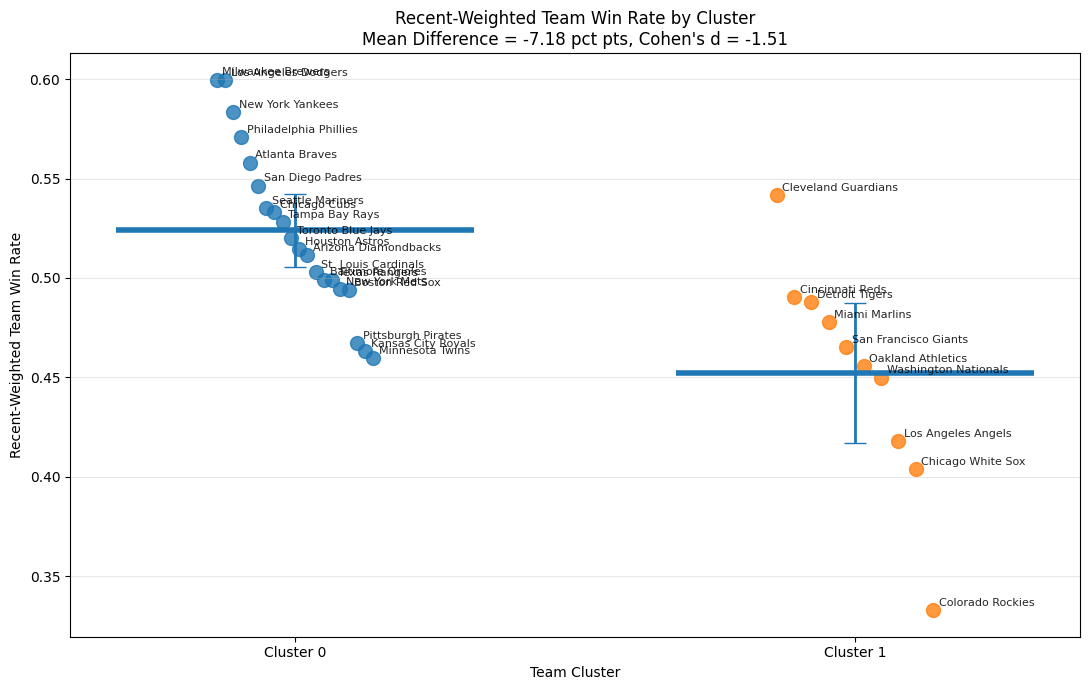

In [ ]:

plot_df = team_profile[
    [
        "team_name",
        "team_cluster",
        "raw_target_team_win",
        "weighted_target_team_win",
    ]
].dropna().copy()

cluster_order = (
    plot_df
    .groupby("team_cluster")["weighted_target_team_win"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(11, 7))

for i, cluster_id in enumerate(cluster_order):
    g = plot_df[plot_df["team_cluster"].eq(cluster_id)].copy()
    g = g.sort_values("weighted_target_team_win", ascending=False)

    x = np.repeat(i, len(g)) + np.linspace(-0.14, 0.14, len(g))

    ax.scatter(
        x,
        g["weighted_target_team_win"],
        s=100,
        alpha=0.80,
    )

    cluster_mean = g["weighted_target_team_win"].mean()
    cluster_std = g["weighted_target_team_win"].std(ddof=1)
    cluster_se = cluster_std / np.sqrt(len(g))

    ax.hlines(
        cluster_mean,
        i - 0.32,
        i + 0.32,
        linewidth=4,
    )

    ax.errorbar(
        i,
        cluster_mean,
        yerr=1.96 * cluster_se,
        fmt="none",
        capsize=8,
        linewidth=2,
    )

    for x_i, (_, row) in zip(x, g.iterrows()):
        ax.annotate(
            row["team_name"],
            (x_i, row["weighted_target_team_win"]),
            xytext=(4, 3),
            textcoords="offset points",
            fontsize=8,
            alpha=0.85,
        )

ax.set_xticks(range(len(cluster_order)))
ax.set_xticklabels([f"Cluster {c}" for c in cluster_order])

ax.set_title(
    "Recent-Weighted Team Win Rate by Cluster\n"
    "Mean Difference = -7.18 pct pts, Cohen's d = -1.51"
)
ax.set_xlabel("Team Cluster")
ax.set_ylabel("Recent-Weighted Team Win Rate")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [99]:
# ---------------------------------------------------------------------
# Merge team clusters back into the main features dataframe
# ---------------------------------------------------------------------

team_cluster_map = (
    team_profile[["team_name", "team_cluster"]]
    .drop_duplicates()
    .copy()
)

cluster_cols_to_drop = [
    "home_team_cluster_recent",
    "away_team_cluster_recent",
    "same_team_cluster_recent",
    "cluster_matchup_recent",
]

features = features.drop(columns=[c for c in cluster_cols_to_drop if c in features.columns])

features = features.merge(
    team_cluster_map.rename(columns={
        "team_name": "home_team_name",
        "team_cluster": "home_team_cluster_recent",
    }),
    on="home_team_name",
    how="left",
)

features = features.merge(
    team_cluster_map.rename(columns={
        "team_name": "away_team_name",
        "team_cluster": "away_team_cluster_recent",
    }),
    on="away_team_name",
    how="left",
)

features["same_team_cluster_recent"] = (
    features["home_team_cluster_recent"].eq(features["away_team_cluster_recent"])
).astype(float)

features["cluster_matchup_recent"] = (
    features["home_team_cluster_recent"].astype("Int64")
    + features["away_team_cluster_recent"].astype("Int64")
)

display(
    features[
        [
            "home_team_name",
            "away_team_name",
            "home_team_cluster_recent",
            "away_team_cluster_recent",
            "same_team_cluster_recent",
            "cluster_matchup_recent",
        ]
    ].head(20)
)

,home_team_name,away_team_name,home_team_cluster_recent,away_team_cluster_recent,same_team_cluster_recent,cluster_matchup_recent
0,Washington Nationals,Atlanta Braves,1,0,0.0,1
1,New York Yankees,San Francisco Giants,0,1,0.0,1
2,Boston Red Sox,Baltimore Orioles,0,0,1.0,0
3,Chicago Cubs,Milwaukee Brewers,0,0,1.0,0
4,Tampa Bay Rays,Detroit Tigers,0,1,0.0,1
5,Texas Rangers,Philadelphia Phillies,0,0,1.0,0
6,Cincinnati Reds,Pittsburgh Pirates,1,0,0.0,1
7,St. Louis Cardinals,Toronto Blue Jays,0,0,1.0,0
8,Kansas City Royals,Minnesota Twins,0,0,1.0,0
9,Miami Marlins,New York Mets,1,0,0.0,1


In [ ]:
print("Cluster columns in main dataset:")
display([c for c in features.columns if "cluster" in c.lower()])


Cluster columns in train_df:


['home_team_cluster_recent',
 'away_team_cluster_recent',
 'same_team_cluster_recent',
 'cluster_matchup_recent']

In [100]:
# ---------------------------------------------------------------------
# Rebuild model_df, train_df, test_df after adding clusters to features
# ---------------------------------------------------------------------

model_df = features.copy()
model_df["official_date"] = pd.to_datetime(model_df["official_date"], errors="coerce")

model_df = model_df[
    model_df["official_date"].notna()
    & model_df["target_home_win"].notna()
    & model_df["target_total_runs"].notna()
    & model_df["target_home_margin"].notna()
].sort_values("official_date").reset_index(drop=True)

if MIN_TRAIN_DATE is not None:
    model_df = model_df[
        model_df["official_date"] >= pd.to_datetime(MIN_TRAIN_DATE)
    ].copy()

if HOLDOUT_START_DATE is not None:
    holdout_start = pd.to_datetime(HOLDOUT_START_DATE)
    train_df = model_df[model_df["official_date"] < holdout_start].copy()
    test_df = model_df[model_df["official_date"] >= holdout_start].copy()
else:
    split_idx = int(len(model_df) * (1 - TEST_FRACTION))
    train_df = model_df.iloc[:split_idx].copy()
    test_df = model_df.iloc[split_idx:].copy()

print("train_df:", train_df.shape)
print("test_df:", test_df.shape)

print("Cluster columns in train_df:")
display([c for c in train_df.columns if "cluster" in c.lower()])

print("Cluster columns in test_df:")
display([c for c in test_df.columns if "cluster" in c.lower()])

train_df: (6685, 2137)
test_df: (1672, 2137)
Cluster columns in train_df:


['home_team_cluster_recent',
 'away_team_cluster_recent',
 'same_team_cluster_recent',
 'cluster_matchup_recent']

Cluster columns in test_df:


['home_team_cluster_recent',
 'away_team_cluster_recent',
 'same_team_cluster_recent',
 'cluster_matchup_recent']

Testing model comparison with clusters added

In [101]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score, accuracy_score
import numpy as np
import pandas as pd

# Use your current best family set.
base_cols = family_map.loc[
    family_map["family"].isin(["elo", "team_form", "starter", "statcast", "pitchmix"]),
    "feature"
].tolist()

# Keep only columns that exist and avoid accidental cluster-as-number leakage.
base_cols = [
    c for c in base_cols
    if c in train_df.columns and "cluster" not in c.lower()
]

cluster_numeric_cols = [
    c for c in [
        "same_team_cluster_recent",
    ]
    if c in train_df.columns
]

cluster_cat_cols = [
    c for c in [
        "home_team_cluster_recent",
        "away_team_cluster_recent",
        "cluster_matchup_recent",
    ]
    if c in train_df.columns
]

print("Base cols:", len(base_cols))
print("Cluster numeric cols:", cluster_numeric_cols)
print("Cluster categorical cols:", cluster_cat_cols)

assert len(cluster_cat_cols) > 0, "Cluster categorical columns are still not in train_df."

Base cols: 888
Cluster numeric cols: ['same_team_cluster_recent']
Cluster categorical cols: ['home_team_cluster_recent', 'away_team_cluster_recent', 'cluster_matchup_recent']


In [102]:
def fit_eval_cluster_model(name, use_clusters=False):
    if use_clusters:
        numeric_cols = base_cols + cluster_numeric_cols
        categorical_cols = cluster_cat_cols
    else:
        numeric_cols = base_cols
        categorical_cols = []

    X_train = train_df[numeric_cols + categorical_cols].copy()
    X_test = test_df[numeric_cols + categorical_cols].copy()

    for c in categorical_cols:
        X_train[c] = X_train[c].astype("string").fillna("missing")
        X_test[c] = X_test[c].astype("string").fillna("missing")

    preprocess = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]), numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ],
        remainder="drop",
    )

    model = Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=25,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    model.fit(X_train, train_df["target_home_win"])

    p = model.predict_proba(X_test)[:, 1]
    p = np.clip(p, 0.001, 0.999)

    return {
        "model_name": name,
        "use_clusters": use_clusters,
        "n_numeric": len(numeric_cols),
        "n_categorical": len(categorical_cols),
        "log_loss": log_loss(test_df["target_home_win"], p),
        "brier": brier_score_loss(test_df["target_home_win"], p),
        "auc": roc_auc_score(test_df["target_home_win"], p),
        "accuracy": accuracy_score(test_df["target_home_win"], p >= 0.5),
        "avg_pred": p.mean(),
        "actual_mean": test_df["target_home_win"].mean(),
    }

cluster_model_results = pd.DataFrame([
    fit_eval_cluster_model("global_no_clusters", use_clusters=False),
    fit_eval_cluster_model("global_with_clusters", use_clusters=True),
])

display(cluster_model_results.sort_values("log_loss"))

,model_name,use_clusters,n_numeric,n_categorical,log_loss,brier,auc,accuracy,avg_pred,actual_mean
1,global_with_clusters,True,889,3,0.683816,0.245466,0.558349,0.547847,0.531000,0.529904
0,global_no_clusters,False,888,0,0.683970,0.245539,0.557085,0.539474,0.530212,0.529904


In [103]:
# ---------------------------------------------------------------------
# Fair cluster validation:
# Fit team clusters using train period only, then map to train/test.
# ---------------------------------------------------------------------

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# Build team-perspective rows from train only
team_long_train = make_team_perspective_for_clustering(train_df)

# Use same preferred cluster column logic
train_cluster_candidate_cols = [
    c for c in team_long_train.columns
    if pd.api.types.is_numeric_dtype(team_long_train[c])
    and (
        c.startswith("team_ewm_")
        or c.startswith("team_elo")
        or c.startswith("team_sc_")
        or c.startswith("team_pitchmix_")
        or c.startswith("team_starter_")
    )
]

train_preferred_cluster_cols = [
    c for c in train_cluster_candidate_cols
    if (
        "_hl30" in c
        or "_hl60" in c
        or "_last10" in c
        or "_last20" in c
        or "season_to_date" in c
        or "elo" in c
    )
]

team_profile_train, train_cluster_input_cols = build_recent_weighted_team_profiles(
    team_long_train,
    train_preferred_cluster_cols,
    half_life_days=365,
    min_non_missing_rate=0.50,
)

print("Train-only team profile:", team_profile_train.shape)
print("Train-only cluster input cols:", len(train_cluster_input_cols))

K_TEAM_CLUSTERS = 2

team_cluster_pipe_train_only = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(
        n_clusters=K_TEAM_CLUSTERS,
        random_state=RANDOM_STATE,
        n_init=50,
    )),
])

team_profile_train["team_cluster_train_only"] = team_cluster_pipe_train_only.fit_predict(
    team_profile_train[train_cluster_input_cols]
)

team_cluster_map_train_only = (
    team_profile_train[["team_name", "team_cluster_train_only"]]
    .drop_duplicates()
    .copy()
)

display(
    team_cluster_map_train_only
    .sort_values(["team_cluster_train_only", "team_name"])
)

Usable profile columns: 165
Train-only team profile: (30, 171)
Train-only cluster input cols: 165


,team_name,team_cluster_train_only
0,Arizona Diamondbacks,0
1,Atlanta Braves,0
2,Baltimore Orioles,0
3,Boston Red Sox,0
4,Chicago Cubs,0
9,Detroit Tigers,0
10,Houston Astros,0
11,Kansas City Royals,0
13,Los Angeles Dodgers,0
15,Milwaukee Brewers,0


In [104]:
def add_train_only_clusters(df, team_cluster_map):
    out = df.copy()

    drop_cols = [
        "home_team_cluster_train_only",
        "away_team_cluster_train_only",
        "same_team_cluster_train_only",
        "cluster_matchup_train_only",
    ]

    out = out.drop(columns=[c for c in drop_cols if c in out.columns], errors="ignore")

    out = out.merge(
        team_cluster_map.rename(columns={
            "team_name": "home_team_name",
            "team_cluster_train_only": "home_team_cluster_train_only",
        }),
        on="home_team_name",
        how="left",
    )

    out = out.merge(
        team_cluster_map.rename(columns={
            "team_name": "away_team_name",
            "team_cluster_train_only": "away_team_cluster_train_only",
        }),
        on="away_team_name",
        how="left",
    )

    out["same_team_cluster_train_only"] = (
        out["home_team_cluster_train_only"].eq(out["away_team_cluster_train_only"])
    ).astype(float)

    out["cluster_matchup_train_only"] = (
        out["home_team_cluster_train_only"].astype("Int64").astype(str)
        + "_vs_"
        + out["away_team_cluster_train_only"].astype("Int64").astype(str)
    )

    return out


train_df_cluster_valid = add_train_only_clusters(train_df, team_cluster_map_train_only)
test_df_cluster_valid = add_train_only_clusters(test_df, team_cluster_map_train_only)

print("Cluster columns in train:")
display([c for c in train_df_cluster_valid.columns if "cluster_train_only" in c.lower()])

print("Cluster columns in test:")
display([c for c in test_df_cluster_valid.columns if "cluster_train_only" in c.lower()])

Cluster columns in train:


['home_team_cluster_train_only',
 'away_team_cluster_train_only',
 'same_team_cluster_train_only']

Cluster columns in test:


['home_team_cluster_train_only',
 'away_team_cluster_train_only',
 'same_team_cluster_train_only']

In [105]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score, accuracy_score
import numpy as np
import pandas as pd

base_cols = family_map.loc[
    family_map["family"].isin(["elo", "team_form", "starter", "statcast", "pitchmix"]),
    "feature"
].tolist()

base_cols = [
    c for c in base_cols
    if c in train_df_cluster_valid.columns and "cluster" not in c.lower()
]

cluster_numeric_cols = [
    c for c in [
        "same_team_cluster_train_only",
    ]
    if c in train_df_cluster_valid.columns
]

cluster_cat_cols = [
    c for c in [
        "home_team_cluster_train_only",
        "away_team_cluster_train_only",
        "cluster_matchup_train_only",
    ]
    if c in train_df_cluster_valid.columns
]

print("Base cols:", len(base_cols))
print("Cluster numeric cols:", cluster_numeric_cols)
print("Cluster categorical cols:", cluster_cat_cols)


def fit_eval_train_only_cluster_model(name, use_clusters=False):
    if use_clusters:
        numeric_cols = base_cols + cluster_numeric_cols
        categorical_cols = cluster_cat_cols
    else:
        numeric_cols = base_cols
        categorical_cols = []

    X_train = train_df_cluster_valid[numeric_cols + categorical_cols].copy()
    X_test = test_df_cluster_valid[numeric_cols + categorical_cols].copy()

    for c in categorical_cols:
        X_train[c] = X_train[c].astype("string").fillna("missing")
        X_test[c] = X_test[c].astype("string").fillna("missing")

    preprocess = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]), numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ],
        remainder="drop",
    )

    model = Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=25,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    model.fit(X_train, train_df_cluster_valid["target_home_win"])

    p = model.predict_proba(X_test)[:, 1]
    p = np.clip(p, 0.001, 0.999)

    return {
        "model_name": name,
        "use_clusters": use_clusters,
        "n_numeric": len(numeric_cols),
        "n_categorical": len(categorical_cols),
        "log_loss": log_loss(test_df_cluster_valid["target_home_win"], p),
        "brier": brier_score_loss(test_df_cluster_valid["target_home_win"], p),
        "auc": roc_auc_score(test_df_cluster_valid["target_home_win"], p),
        "accuracy": accuracy_score(test_df_cluster_valid["target_home_win"], p >= 0.5),
        "avg_pred": p.mean(),
        "actual_mean": test_df_cluster_valid["target_home_win"].mean(),
    }


train_only_cluster_results = pd.DataFrame([
    fit_eval_train_only_cluster_model("global_no_clusters", use_clusters=False),
    fit_eval_train_only_cluster_model("global_with_train_only_clusters", use_clusters=True),
])

display(train_only_cluster_results.sort_values("log_loss"))

Base cols: 888
Cluster numeric cols: ['same_team_cluster_train_only']
Cluster categorical cols: ['home_team_cluster_train_only', 'away_team_cluster_train_only', 'cluster_matchup_train_only']


,model_name,use_clusters,n_numeric,n_categorical,log_loss,brier,auc,accuracy,avg_pred,actual_mean
0,global_no_clusters,False,888,0,0.683970,0.245539,0.557085,0.539474,0.530212,0.529904
1,global_with_train_only_clusters,True,889,3,0.684286,0.245693,0.556313,0.540072,0.531135,0.529904


## 14.1 Testing Pitching Features

In [107]:
print("features shape:", features.shape)
print("unique games:", features["game_pk"].nunique())
print("rows per game:", len(features) / features["game_pk"].nunique())

features shape: (8404, 2137)
unique games: 8404
rows per game: 1.0


In [116]:
pitch_keywords = [
    "velo",
    "velocity",
    "whiff",
    "k_rate",
    "bb_rate",
    "era",
    "whip",
    "spin",
    "release",
    "pitch_type",
    "pitch_name",
]

pitch_cols = [
    c for c in features.columns
    if any(k in c.lower() for k in pitch_keywords)
]

diff_pitch_cols = [
    c for c in pitch_cols
    if any(k in c.lower() for k in ['diff'])
]

print("Pitching-related columns:", len(pitch_cols))
display(pd.DataFrame({"column": diff_pitch_cols}).head(300))

Pitching-related columns: 249


,column
0,diff_box_box_box_pitch_era_season_to_date
1,diff_box_box_box_pitch_era_last3
2,diff_box_box_box_pitch_era_last5
3,diff_box_box_box_pitch_era_last10
4,diff_box_box_box_pitch_era_last20
...,...
78,diff_starter_starter_statcast_sc_bb_rate_seaso...
79,diff_starter_starter_statcast_sc_bb_rate_last3
80,diff_starter_starter_statcast_sc_bb_rate_last5
81,diff_starter_starter_statcast_sc_bb_rate_last10


,corr_with_target,abs_corr
diff_team_team_run_diff_season_to_date,0.124575,0.124575
diff_elo_pre,0.124007,0.124007
elo_home_win_prob,0.122742,0.122742
diff_box_box_runs_against_season_to_date,-0.120460,0.120460
diff_team_team_runs_against_season_to_date,-0.120460,0.120460
diff_box_box_box_pitch_runs_season_to_date,-0.120460,0.120460
diff_box_box_box_pitch_obp_season_to_date,-0.118581,0.118581
diff_box_box_box_pitch_earnedRuns_season_to_date,-0.117360,0.117360
diff_box_box_box_pitch_rbi_season_to_date,-0.116436,0.116436
diff_box_box_box_pitch_battersFaced_season_to_date,-0.116042,0.116042


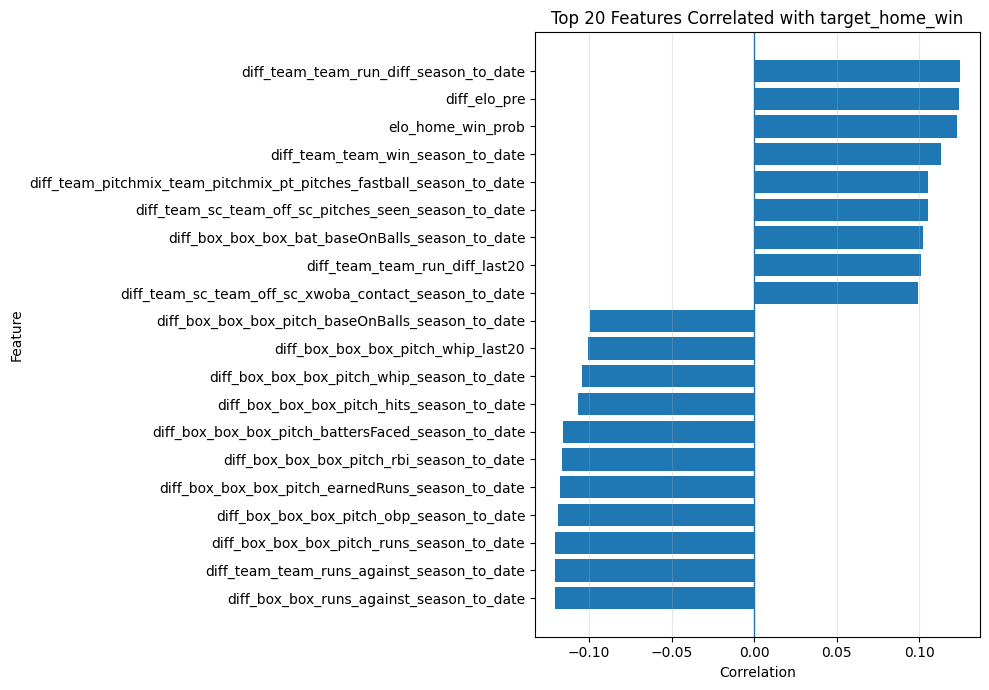

In [122]:
TARGET = "target_home_win"   # or "target_total_runs", "target_home_margin"
TOP_N = 20

corr_df = features[candidate_feature_cols + [TARGET]].corr(numeric_only=True)

target_corr = (
    corr_df[TARGET]
    .drop(TARGET)
    .dropna()
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(TOP_N)
)

display(
    target_corr
    .to_frame("corr_with_target")
    .assign(abs_corr=lambda d: d["corr_with_target"].abs())
)

plot_df = target_corr.sort_values()

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(plot_df.index, plot_df.values)

ax.axvline(0, linewidth=1)
ax.set_title(f"Top {TOP_N} Features Correlated with {TARGET}")
ax.set_xlabel("Correlation")
ax.set_ylabel("Feature")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

,feature_1,feature_2,correlation,abs_correlation
0,home_team_team_runs_for_last10,home_box_box_runs_for_last10,1.0,1.0
1,home_team_team_runs_for_last20,home_box_box_runs_for_last20,1.0,1.0
2,away_team_team_runs_for_last20,away_box_box_runs_for_last20,1.0,1.0
3,away_team_team_runs_against_last20,away_box_box_runs_against_last20,1.0,1.0
4,home_box_box_box_pitch_hitByPitch_last5,home_box_box_box_pitch_hitBatsmen_last5,1.0,1.0
5,home_box_box_box_pitch_hitByPitch_last10,home_box_box_box_pitch_hitBatsmen_last10,1.0,1.0
6,home_team_team_runs_against_season_to_date,home_box_box_runs_against_season_to_date,1.0,1.0
7,diff_team_team_runs_for_season_to_date,diff_box_box_runs_for_season_to_date,1.0,1.0
8,home_team_team_runs_for_last3,home_box_box_runs_for_last3,1.0,1.0
9,diff_team_team_runs_for_last3,diff_box_box_runs_for_last3,1.0,1.0


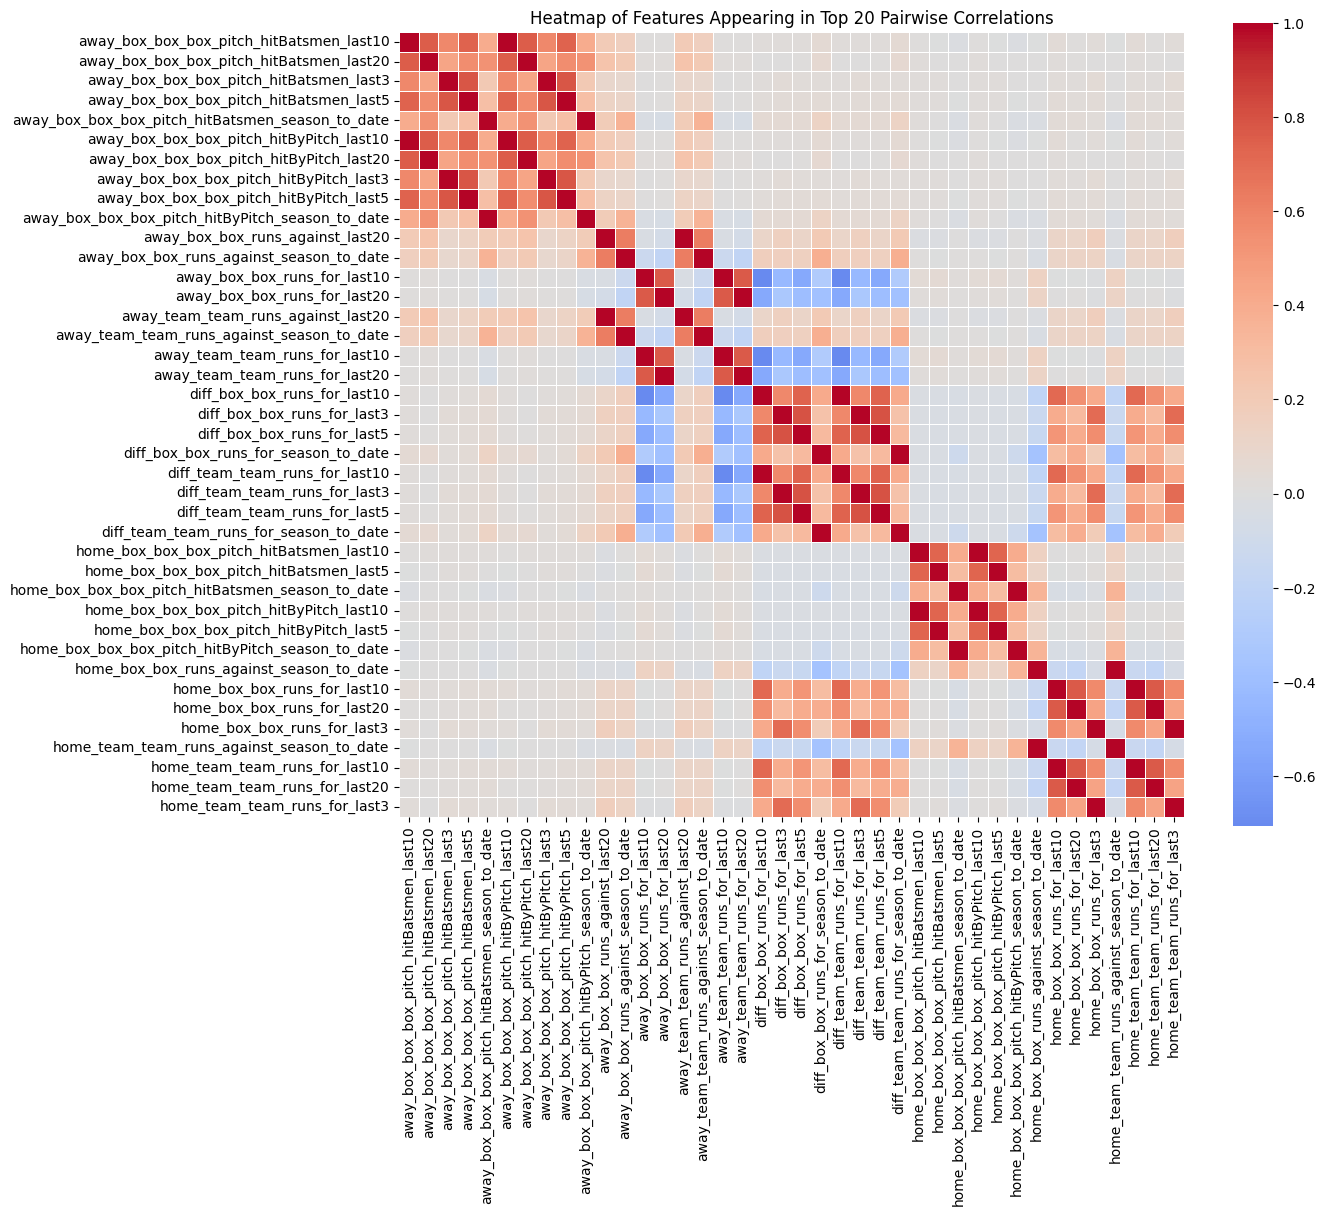

In [123]:
TOP_N = 20

corr_matrix = features[candidate_feature_cols].corr(numeric_only=True)

# Keep upper triangle only to avoid duplicate pairs
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

top_pairs = (
    upper
    .stack()
    .reset_index()
    .rename(columns={
        "level_0": "feature_1",
        "level_1": "feature_2",
        0: "correlation",
    })
)

top_pairs["abs_correlation"] = top_pairs["correlation"].abs()

top_pairs = (
    top_pairs
    .sort_values("abs_correlation", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

display(top_pairs)

top_pair_features = sorted(
    set(top_pairs["feature_1"]).union(set(top_pairs["feature_2"]))
)

top_pair_corr_matrix = features[top_pair_features].corr(numeric_only=True)

plt.figure(figsize=(14, 12))

sns.heatmap(
    top_pair_corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)

plt.title(f"Heatmap of Features Appearing in Top {TOP_N} Pairwise Correlations")
plt.tight_layout()
plt.show()

## 15. Model candidate factories

The notebook uses robust sklearn defaults. XGBoost is included only if installed locally.

In [130]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge, PoissonRegressor
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.calibration import CalibratedClassifierCV

try:
    from xgboost import XGBClassifier, XGBRegressor
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

print("HAS_XGBOOST:", HAS_XGBOOST)


def moneyline_model_candidates():
    candidates = []
    candidates.append((
        "logistic_l2",
        make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            LogisticRegression(max_iter=3000, C=0.25, class_weight=None),
        ),
    ))
    candidates.append((
        "hist_gbdt",
        make_pipeline(
            SimpleImputer(strategy="median"),
            HistGradientBoostingClassifier(
                max_iter=250 if not FAST_MODE else 100,
                learning_rate=0.03,
                max_leaf_nodes=15,
                l2_regularization=0.1,
                random_state=RANDOM_STATE,
            ),
        ),
    ))
    candidates.append((
        "random_forest",
        make_pipeline(
            SimpleImputer(strategy="median"),
            RandomForestClassifier(
                n_estimators=400 if not FAST_MODE else 150,
                min_samples_leaf=25,
                max_features="sqrt",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ))
    candidates.append((
        "extra_trees",
        make_pipeline(
            SimpleImputer(strategy="median"),
            ExtraTreesClassifier(
                n_estimators=400 if not FAST_MODE else 150,
                min_samples_leaf=25,
                max_features="sqrt",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ))
    if HAS_XGBOOST:
        candidates.append((
            "xgboost_logloss",
            XGBClassifier(
                n_estimators=450 if not FAST_MODE else 150,
                max_depth=3,
                learning_rate=0.025,
                subsample=0.85,
                colsample_bytree=0.75,
                objective="binary:logistic",
                eval_metric="logloss",
                reg_lambda=5.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ))
    return candidates


def regression_model_candidates(target_type="normal"):
    candidates = []
    candidates.append((
        "ridge_l2",
        make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(),
            Ridge(alpha=20.0),
        ),
    ))
    candidates.append((
        "hist_gbdt_squared_error",
        make_pipeline(
            SimpleImputer(strategy="median"),
            HistGradientBoostingRegressor(
                loss="squared_error",
                max_iter=250 if not FAST_MODE else 100,
                learning_rate=0.03,
                max_leaf_nodes=15,
                l2_regularization=0.1,
                random_state=RANDOM_STATE,
            ),
        ),
    ))
    if target_type == "count_positive":
        candidates.append((
            "hist_gbdt_poisson",
            make_pipeline(
                SimpleImputer(strategy="median"),
                HistGradientBoostingRegressor(
                    loss="poisson",
                    max_iter=250 if not FAST_MODE else 100,
                    learning_rate=0.03,
                    max_leaf_nodes=15,
                    l2_regularization=0.1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ))
        candidates.append((
            "poisson_glm_l2",
            make_pipeline(
                SimpleImputer(strategy="median"),
                StandardScaler(),
                PoissonRegressor(alpha=1.0, max_iter=1000),
            ),
        ))
    candidates.append((
        "random_forest",
        make_pipeline(
            SimpleImputer(strategy="median"),
            RandomForestRegressor(
                n_estimators=400 if not FAST_MODE else 150,
                min_samples_leaf=25,
                max_features="sqrt",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ))
    candidates.append((
        "extra_trees",
        make_pipeline(
            SimpleImputer(strategy="median"),
            ExtraTreesRegressor(
                n_estimators=400 if not FAST_MODE else 150,
                min_samples_leaf=25,
                max_features="sqrt",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ))
    if HAS_XGBOOST:
        objective = "count:poisson" if target_type == "count_positive" else "reg:squarederror"
        candidates.append((
            "xgboost_poisson" if target_type == "count_positive" else "xgboost_squarederror",
            XGBRegressor(
                n_estimators=500 if not FAST_MODE else 150,
                max_depth=3,
                learning_rate=0.025,
                subsample=0.85,
                colsample_bytree=0.75,
                objective=objective,
                reg_lambda=5.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ))
    return candidates

HAS_XGBOOST: True


## 16. Train moneyline models

In [131]:
moneyline_results = []
moneyline_fitted = {}
moneyline_preds = {}

if "target_home_win" in features.columns:
    train_df, test_df = time_train_test_split(features, "target_home_win")
    print("moneyline train/test:", train_df.shape, test_df.shape)
    if "official_date" in train_df.columns:
        print("train dates:", train_df["official_date"].min(), train_df["official_date"].max())
        print("test dates:", test_df["official_date"].min(), test_df["official_date"].max())

    for fs_name in FEATURE_SET_NAMES_TO_RUN:
        cols = [c for c in feature_sets[fs_name] if c in train_df.columns]
        if len(cols) == 0:
            continue
        X_train = train_df[cols]
        y_train = train_df["target_home_win"].astype(int)
        X_test = test_df[cols]
        y_test = test_df["target_home_win"].astype(int)

        for model_name, model in moneyline_model_candidates():
            full_name = f"{fs_name}__{model_name}"
            print("Training", full_name, "features", len(cols))
            try:
                model.fit(X_train, y_train)
                prob = model.predict_proba(X_test)[:, 1]
                metrics = classification_metrics(y_test, prob)
                row = {
                    "model_name": full_name,
                    "feature_set": fs_name,
                    "estimator": model_name,
                    "feature_count": len(cols),
                }
                row.update(metrics)
                moneyline_results.append(row)
                moneyline_fitted[full_name] = {"model": model, "feature_cols": cols}
                moneyline_preds[full_name] = prob
            except Exception as e:
                print("FAILED", full_name, type(e).__name__, e)

moneyline_results_df = pd.DataFrame(moneyline_results)
if not moneyline_results_df.empty:
    moneyline_results_df = moneyline_results_df.sort_values(["log_loss", "brier", "auc"], ascending=[True, True, False]).reset_index(drop=True)
    display(moneyline_results_df.head(30))
    moneyline_results_df.to_csv(EDA_DIR / "moneyline_model_results.csv", index=False)
else:
    print("No moneyline results.")

moneyline train/test: (6685, 2137) (1672, 2137)
train dates: 2023-03-30 00:00:00 2025-08-15 00:00:00
test dates: 2025-08-15 00:00:00 2026-06-14 00:00:00
Training elo_only__logistic_l2 features 34
Training elo_only__hist_gbdt features 34
Training elo_only__random_forest features 34
Training elo_only__extra_trees features 34
Training elo_only__xgboost_logloss features 34
Training team_form_plus_elo__logistic_l2 features 94
Training team_form_plus_elo__hist_gbdt features 94
Training team_form_plus_elo__random_forest features 94
Training team_form_plus_elo__extra_trees features 94
Training team_form_plus_elo__xgboost_logloss features 94
Training team_box_plus_elo__logistic_l2 features 1144
Training team_box_plus_elo__hist_gbdt features 1144
Training team_box_plus_elo__random_forest features 1144
Training team_box_plus_elo__extra_trees features 1144
Training team_box_plus_elo__xgboost_logloss features 1144
Training starter_plus_team__logistic_l2 features 373
Training starter_plus_team__hist

,model_name,feature_set,estimator,feature_count,log_loss,brier,accuracy,auc,avg_pred,actual_mean,n
0,all_clean__extra_trees,all_clean,extra_trees,1939,0.683683,0.245364,0.552033,0.560720,0.530264,0.531699,1672
1,starter_plus_team__extra_trees,starter_plus_team,extra_trees,373,0.684292,0.245657,0.543062,0.556972,0.527667,0.531699,1672
2,full_non_market__extra_trees,full_non_market,extra_trees,1938,0.684585,0.245798,0.547847,0.558098,0.529619,0.531699,1672
3,full_non_market__random_forest,full_non_market,random_forest,1938,0.684767,0.245914,0.550239,0.556836,0.530049,0.531699,1672
4,statcast_team_plus_pitchmix__extra_trees,statcast_team_plus_pitchmix,extra_trees,609,0.685008,0.246002,0.551435,0.554244,0.529676,0.531699,1672
5,elo_only__extra_trees,elo_only,extra_trees,34,0.685288,0.246117,0.542464,0.557744,0.527802,0.531699,1672
6,starter_plus_team__random_forest,starter_plus_team,random_forest,373,0.685516,0.246290,0.543062,0.551924,0.527136,0.531699,1672
7,all_clean__xgboost_logloss,all_clean,xgboost_logloss,1939,0.685706,0.246387,0.543660,0.561479,0.534222,0.531699,1672
8,team_form_plus_elo__extra_trees,team_form_plus_elo,extra_trees,94,0.685799,0.246394,0.541268,0.551399,0.528296,0.531699,1672
9,all_clean__random_forest,all_clean,random_forest,1939,0.686003,0.246521,0.546651,0.551023,0.529374,0.531699,1672


## 17. Train total-runs models

In [132]:
totals_results = []
totals_fitted = {}
totals_preds = {}

if "target_total_runs" in features.columns:
    train_df_total, test_df_total = time_train_test_split(features, "target_total_runs")
    print("totals train/test:", train_df_total.shape, test_df_total.shape)
    if "official_date" in train_df_total.columns:
        print("train dates:", train_df_total["official_date"].min(), train_df_total["official_date"].max())
        print("test dates:", test_df_total["official_date"].min(), test_df_total["official_date"].max())

    for fs_name in FEATURE_SET_NAMES_TO_RUN:
        cols = [c for c in feature_sets[fs_name] if c in train_df_total.columns]
        if len(cols) == 0:
            continue
        X_train = train_df_total[cols]
        y_train = train_df_total["target_total_runs"].astype(float)
        X_test = test_df_total[cols]
        y_test = test_df_total["target_total_runs"].astype(float)

        for model_name, model in regression_model_candidates(target_type="count_positive"):
            full_name = f"{fs_name}__{model_name}"
            print("Training", full_name, "features", len(cols))
            try:
                model.fit(X_train, y_train)
                pred = np.asarray(model.predict(X_test), dtype=float)
                # Total runs cannot be negative. Clip only for evaluation/deviance safety.
                pred_eval = np.clip(pred, 0.05, None)
                metrics = regression_metrics(y_test, pred_eval)
                try:
                    metrics["poisson_deviance"] = float(mean_poisson_deviance(y_test, pred_eval))
                except Exception:
                    metrics["poisson_deviance"] = np.nan
                row = {
                    "model_name": full_name,
                    "feature_set": fs_name,
                    "estimator": model_name,
                    "feature_count": len(cols),
                }
                row.update(metrics)
                totals_results.append(row)
                totals_fitted[full_name] = {"model": model, "feature_cols": cols}
                totals_preds[full_name] = pred_eval
            except Exception as e:
                print("FAILED", full_name, type(e).__name__, e)

totals_results_df = pd.DataFrame(totals_results)
if not totals_results_df.empty:
    totals_results_df = totals_results_df.sort_values(["mae", "rmse", "poisson_deviance"], ascending=[True, True, True]).reset_index(drop=True)
    display(totals_results_df.head(30))
    totals_results_df.to_csv(EDA_DIR / "totals_model_results.csv", index=False)

    # Guardrail: suspiciously good totals models are likely leaking final score information.
    suspicious_totals = totals_results_df[(totals_results_df["mae"] < 2.0) | (totals_results_df["r2"] > 0.50)]
    if not suspicious_totals.empty:
        print("WARNING: suspicious totals models detected. Do not export these until leakage is resolved.")
        display(suspicious_totals)
else:
    print("No totals results.")

totals train/test: (6685, 2137) (1672, 2137)
train dates: 2023-03-30 00:00:00 2025-08-15 00:00:00
test dates: 2025-08-15 00:00:00 2026-06-14 00:00:00
Training elo_only__ridge_l2 features 34
Training elo_only__hist_gbdt_squared_error features 34
Training elo_only__hist_gbdt_poisson features 34
Training elo_only__poisson_glm_l2 features 34
Training elo_only__random_forest features 34
Training elo_only__extra_trees features 34
Training elo_only__xgboost_poisson features 34
Training team_form_plus_elo__ridge_l2 features 94
Training team_form_plus_elo__hist_gbdt_squared_error features 94
Training team_form_plus_elo__hist_gbdt_poisson features 94
Training team_form_plus_elo__poisson_glm_l2 features 94
Training team_form_plus_elo__random_forest features 94
Training team_form_plus_elo__extra_trees features 94
Training team_form_plus_elo__xgboost_poisson features 94
Training team_box_plus_elo__ridge_l2 features 1144
Training team_box_plus_elo__hist_gbdt_squared_error features 1144
Training team

,model_name,feature_set,estimator,feature_count,mae,rmse,r2,avg_pred,actual_mean,n,poisson_deviance
0,full_non_market__random_forest,full_non_market,random_forest,1938,3.518431,4.454980,0.013846,8.861305,8.990431,1672,2.204367
1,all_clean__random_forest,all_clean,random_forest,1939,3.521848,4.458670,0.012212,8.860772,8.990431,1672,2.207851
2,team_form_plus_elo__random_forest,team_form_plus_elo,random_forest,94,3.524073,4.454656,0.013989,8.800206,8.990431,1672,2.203842
3,starter_plus_team__random_forest,starter_plus_team,random_forest,373,3.525577,4.463989,0.009854,8.855889,8.990431,1672,2.212967
4,team_box_plus_elo__random_forest,team_box_plus_elo,random_forest,1144,3.529168,4.467081,0.008482,8.838834,8.990431,1672,2.216576
5,team_form_plus_elo__ridge_l2,team_form_plus_elo,ridge_l2,94,3.530369,4.470861,0.006803,8.869474,8.990431,1672,2.219051
6,elo_only__ridge_l2,elo_only,ridge_l2,34,3.530825,4.475923,0.004552,8.861069,8.990431,1672,2.224498
7,elo_only__random_forest,elo_only,random_forest,34,3.530929,4.470174,0.007108,8.827902,8.990431,1672,2.219268
8,starter_plus_team__extra_trees,starter_plus_team,extra_trees,373,3.532681,4.462679,0.010435,8.897632,8.990431,1672,2.211175
9,statcast_team_plus_pitchmix__random_forest,statcast_team_plus_pitchmix,random_forest,609,3.533084,4.467936,0.008102,8.863081,8.990431,1672,2.217120


## 18. Train home-margin / run-line models

In [133]:
margin_results = []
margin_fitted = {}
margin_preds = {}

if "target_home_margin" in features.columns:
    train_df_margin, test_df_margin = time_train_test_split(features, "target_home_margin")
    print("margin train/test:", train_df_margin.shape, test_df_margin.shape)
    if "official_date" in train_df_margin.columns:
        print("train dates:", train_df_margin["official_date"].min(), train_df_margin["official_date"].max())
        print("test dates:", test_df_margin["official_date"].min(), test_df_margin["official_date"].max())

    for fs_name in FEATURE_SET_NAMES_TO_RUN:
        cols = [c for c in feature_sets[fs_name] if c in train_df_margin.columns]
        if len(cols) == 0:
            continue
        X_train = train_df_margin[cols]
        y_train = train_df_margin["target_home_margin"].astype(float)
        X_test = test_df_margin[cols]
        y_test = test_df_margin["target_home_margin"].astype(float)

        for model_name, model in regression_model_candidates(target_type="normal"):
            full_name = f"{fs_name}__{model_name}"
            print("Training", full_name, "features", len(cols))
            try:
                model.fit(X_train, y_train)
                pred = np.asarray(model.predict(X_test), dtype=float)
                metrics = regression_metrics(y_test, pred)
                row = {
                    "model_name": full_name,
                    "feature_set": fs_name,
                    "estimator": model_name,
                    "feature_count": len(cols),
                }
                row.update(metrics)
                margin_results.append(row)
                margin_fitted[full_name] = {"model": model, "feature_cols": cols}
                margin_preds[full_name] = pred
            except Exception as e:
                print("FAILED", full_name, type(e).__name__, e)

margin_results_df = pd.DataFrame(margin_results)
if not margin_results_df.empty:
    margin_results_df = margin_results_df.sort_values(["mae", "rmse"], ascending=[True, True]).reset_index(drop=True)
    display(margin_results_df.head(30))
    margin_results_df.to_csv(EDA_DIR / "margin_model_results.csv", index=False)
else:
    print("No margin results.")

margin train/test: (6685, 2137) (1672, 2137)
train dates: 2023-03-30 00:00:00 2025-08-15 00:00:00
test dates: 2025-08-15 00:00:00 2026-06-14 00:00:00
Training elo_only__ridge_l2 features 34
Training elo_only__hist_gbdt_squared_error features 34
Training elo_only__random_forest features 34
Training elo_only__extra_trees features 34
Training elo_only__xgboost_squarederror features 34
Training team_form_plus_elo__ridge_l2 features 94
Training team_form_plus_elo__hist_gbdt_squared_error features 94
Training team_form_plus_elo__random_forest features 94
Training team_form_plus_elo__extra_trees features 94
Training team_form_plus_elo__xgboost_squarederror features 94
Training team_box_plus_elo__ridge_l2 features 1144
Training team_box_plus_elo__hist_gbdt_squared_error features 1144
Training team_box_plus_elo__random_forest features 1144
Training team_box_plus_elo__extra_trees features 1144
Training team_box_plus_elo__xgboost_squarederror features 1144
Training starter_plus_team__ridge_l2 fea

,model_name,feature_set,estimator,feature_count,mae,rmse,r2,avg_pred,actual_mean,n
0,full_non_market__random_forest,full_non_market,random_forest,1938,3.538243,4.479304,0.027264,0.011524,0.038278,1672
1,all_clean__random_forest,all_clean,random_forest,1939,3.539932,4.482453,0.025896,0.016593,0.038278,1672
2,starter_plus_team__random_forest,starter_plus_team,random_forest,373,3.542146,4.485745,0.024464,-0.011344,0.038278,1672
3,all_clean__xgboost_squarederror,all_clean,xgboost_squarederror,1939,3.544304,4.500640,0.017975,0.058765,0.038278,1672
4,statcast_team_plus_pitchmix__random_forest,statcast_team_plus_pitchmix,random_forest,609,3.552081,4.494842,0.020504,0.016421,0.038278,1672
5,all_clean__extra_trees,all_clean,extra_trees,1939,3.553184,4.484885,0.024839,0.002394,0.038278,1672
6,starter_plus_team__hist_gbdt_squared_error,starter_plus_team,hist_gbdt_squared_error,373,3.553795,4.506095,0.015593,0.030476,0.038278,1672
7,starter_plus_team__extra_trees,starter_plus_team,extra_trees,373,3.553963,4.490744,0.022289,-0.008200,0.038278,1672
8,team_box_plus_elo__xgboost_squarederror,team_box_plus_elo,xgboost_squarederror,1144,3.555076,4.503432,0.016756,0.029849,0.038278,1672
9,full_non_market__extra_trees,full_non_market,extra_trees,1938,3.556108,4.488519,0.023258,-0.002113,0.038278,1672


## 18.1 running a feature elimination model

In [137]:
def walk_forward_splits(df, date_col="official_date", min_train_date=None):
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.sort_values(date_col).copy()
    d["season"] = d[date_col].dt.year

    seasons = sorted(d["season"].dropna().unique())

    splits = []

    for test_season in seasons[1:]:
        train_idx = d[d["season"] < test_season].index
        test_idx = d[d["season"] == test_season].index

        if len(train_idx) == 0 or len(test_idx) == 0:
            continue

        splits.append((test_season, train_idx, test_idx))

    return splits


def evaluate_classifier_preds(y_true, p):
    p = np.clip(p, 0.001, 0.999)

    return {
        "log_loss": log_loss(y_true, p),
        "brier": brier_score_loss(y_true, p),
        "auc": roc_auc_score(y_true, p),
        "accuracy": accuracy_score(y_true, p >= 0.5),
        "avg_pred": p.mean(),
        "actual_mean": y_true.mean(),
    }

In [138]:
from sklearn.calibration import CalibratedClassifierCV

# Chronological split inside training data
train_df_sorted = train_df.sort_values("official_date").copy()

cal_split = int(len(train_df_sorted) * 0.80)

fit_df = train_df_sorted.iloc[:cal_split].copy()
cal_df = train_df_sorted.iloc[cal_split:].copy()

base_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=700,
        min_samples_leaf=25,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

base_rf.fit(fit_df[numeric_cols], fit_df["target_home_win"])

# Calibrate on later training slice
calibrated_rf = CalibratedClassifierCV(
    estimator=base_rf,
    method="isotonic",  # also test "sigmoid"
    cv="prefit",
)

calibrated_rf.fit(cal_df[numeric_cols], cal_df["target_home_win"])

p_uncal = base_rf.predict_proba(test_df[numeric_cols])[:, 1]
p_cal = calibrated_rf.predict_proba(test_df[numeric_cols])[:, 1]

calibration_compare = pd.DataFrame([
    {
        "model": "rf_uncalibrated",
        **evaluate_classifier_preds(test_df["target_home_win"], p_uncal),
    },
    {
        "model": "rf_isotonic_calibrated",
        **evaluate_classifier_preds(test_df["target_home_win"], p_cal),
    },
])

display(calibration_compare.sort_values("log_loss"))

,model,log_loss,brier,auc,accuracy,avg_pred,actual_mean
0,rf_uncalibrated,0.683737,0.245402,0.560552,0.552632,0.531409,0.531699
1,rf_isotonic_calibrated,0.707696,0.248582,0.553380,0.552632,0.519416,0.531699


In [139]:
wf_df = model_df.copy()
wf_df["official_date"] = pd.to_datetime(wf_df["official_date"], errors="coerce")

cluster_cols = [
    "same_team_cluster_recent",
]

base_cols = family_map.loc[
    family_map["family"].isin(["elo", "team_form", "starter", "statcast", "pitchmix"]),
    "feature"
].tolist()

base_cols = [
    c for c in base_cols
    if c in wf_df.columns and "cluster" not in c.lower()
]

numeric_cols = base_cols + [c for c in cluster_cols if c in wf_df.columns]

walk_results = []

for test_season, train_idx, test_idx in walk_forward_splits(wf_df):
    tr = wf_df.loc[train_idx].copy()
    te = wf_df.loc[test_idx].copy()

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=25,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    model.fit(tr[numeric_cols], tr["target_home_win"])

    p = model.predict_proba(te[numeric_cols])[:, 1]

    row = {
        "test_season": test_season,
        "n_train": len(tr),
        "n_test": len(te),
        "n_features": len(numeric_cols),
    }

    row.update(evaluate_classifier_preds(te["target_home_win"], p))
    walk_results.append(row)

walk_results_df = pd.DataFrame(walk_results)
display(walk_results_df)

display(
    walk_results_df[
        ["log_loss", "brier", "auc", "accuracy", "avg_pred", "actual_mean"]
    ].mean().to_frame("mean_metric")
)

,test_season,n_train,n_test,n_features,log_loss,brier,auc,accuracy,avg_pred,actual_mean
0,2024,2430,2429,889,0.679799,0.243400,0.591283,0.565253,0.521638,0.521614
1,2025,4859,2430,889,0.679496,0.243344,0.572859,0.546091,0.523056,0.542798
2,2026,7289,1068,889,0.687382,0.247175,0.546970,0.533708,0.529079,0.529026


,mean_metric
log_loss,0.682226
brier,0.244640
auc,0.570371
accuracy,0.548351
avg_pred,0.524591
actual_mean,0.531146


In [140]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

wf_df = model_df.copy()
wf_df["official_date"] = pd.to_datetime(wf_df["official_date"], errors="coerce")

cluster_cols = [
    "same_team_cluster_recent",
]

base_cols = family_map.loc[
    family_map["family"].isin(["elo", "team_form", "starter", "statcast", "pitchmix"]),
    "feature"
].tolist()

base_cols = [
    c for c in base_cols
    if c in wf_df.columns and "cluster" not in c.lower()
]

numeric_cols = base_cols + [c for c in cluster_cols if c in wf_df.columns]

walk_results = []

for test_season, train_idx, test_idx in walk_forward_splits(wf_df):
    tr = wf_df.loc[train_idx].copy()
    te = wf_df.loc[test_idx].copy()

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=25,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    model.fit(tr[numeric_cols], tr["target_home_win"])

    p = model.predict_proba(te[numeric_cols])[:, 1]

    row = {
        "test_season": test_season,
        "n_train": len(tr),
        "n_test": len(te),
        "n_features": len(numeric_cols),
    }

    row.update(evaluate_classifier_preds(te["target_home_win"], p))
    walk_results.append(row)

walk_results_df = pd.DataFrame(walk_results)
display(walk_results_df)

display(
    walk_results_df[
        ["log_loss", "brier", "auc", "accuracy", "avg_pred", "actual_mean"]
    ].mean().to_frame("mean_metric")
)

def calibration_table(y_true, p, n_bins=10):
    d = pd.DataFrame({
        "y": y_true.values if hasattr(y_true, "values") else y_true,
        "p": np.clip(p, 0.001, 0.999),
    })

    d["bucket"] = pd.qcut(d["p"], q=n_bins, duplicates="drop")

    out = (
        d.groupby("bucket")
        .agg(
            n=("y", "count"),
            avg_pred=("p", "mean"),
            actual_rate=("y", "mean"),
        )
        .reset_index()
    )

    out["calibration_error"] = out["actual_rate"] - out["avg_pred"]
    return out

display(calibration_table(test_df["target_home_win"], p_cal, n_bins=10))

,test_season,n_train,n_test,n_features,log_loss,brier,auc,accuracy,avg_pred,actual_mean
0,2024,2430,2429,889,0.679799,0.243400,0.591283,0.565253,0.521638,0.521614
1,2025,4859,2430,889,0.679496,0.243344,0.572859,0.546091,0.523056,0.542798
2,2026,7289,1068,889,0.687382,0.247175,0.546970,0.533708,0.529079,0.529026


,mean_metric
log_loss,0.682226
brier,0.244640
auc,0.570371
accuracy,0.548351
avg_pred,0.524591
actual_mean,0.531146


,bucket,n,avg_pred,actual_rate,calibration_error
0,"(0.0, 0.51]",764,0.468697,0.492147,0.023450
1,"(0.51, 0.526]",113,0.526316,0.575221,0.048905
2,"(0.526, 0.535]",659,0.534840,0.540212,0.005373
3,"(0.535, 0.923]",136,0.723868,0.676471,-0.047397


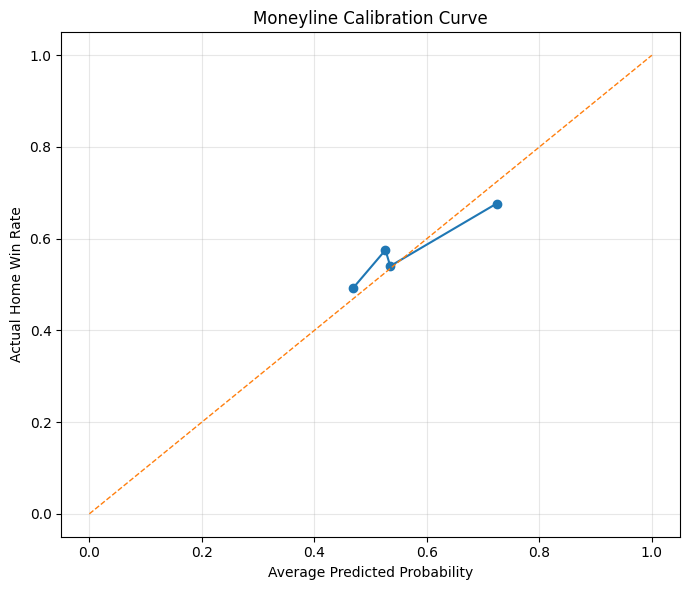

In [141]:
import matplotlib.pyplot as plt

cal_tbl = calibration_table(test_df["target_home_win"], p_cal, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(cal_tbl["avg_pred"], cal_tbl["actual_rate"], marker="o")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

ax.set_title("Moneyline Calibration Curve")
ax.set_xlabel("Average Predicted Probability")
ax.set_ylabel("Actual Home Win Rate")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [142]:
from sklearn.inspection import permutation_importance

best_model = calibrated_rf  # or base_rf if calibration made it worse

perm = permutation_importance(
    best_model,
    test_df[numeric_cols],
    test_df["target_home_win"],
    scoring="neg_log_loss",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": numeric_cols,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(perm_df.head(40))

,feature,importance_mean,importance_std
824,diff_starter_starter_statcast_sc_max_velo_last3,0.020678,0.000164
605,diff_team_pitchmix_team_pitchmix_pt_pitches_br...,0.020544,0.000243
603,diff_team_pitchmix_team_pitchmix_pt_pitches_br...,0.020456,0.000204
655,diff_team_pitchmix_team_pitchmix_pt_woba_offsp...,0.019836,0.000190
46,diff_team_team_runs_for_last5,0.018480,0.006032
376,home_team_pitchmix_team_pitchmix_pt_avg_ev_bre...,0.018463,0.006177
260,away_team_sc_team_off_sc_xwoba_contact_last5,0.016664,0.008064
834,diff_starter_starter_statcast_sc_avg_extension...,0.016347,0.008164
649,diff_team_pitchmix_team_pitchmix_pt_woba_fastb...,0.016311,0.008069
349,diff_team_sc_team_off_sc_bb_rate_last3,0.016206,0.008097


count    1672.000000
mean        0.519408
std         0.103330
min         0.000000
1%          0.200000
5%          0.282051
10%         0.509719
25%         0.509719
50%         0.526316
75%         0.534840
90%         0.534840
95%         0.652174
99%         0.923077
max         0.923077
dtype: float64

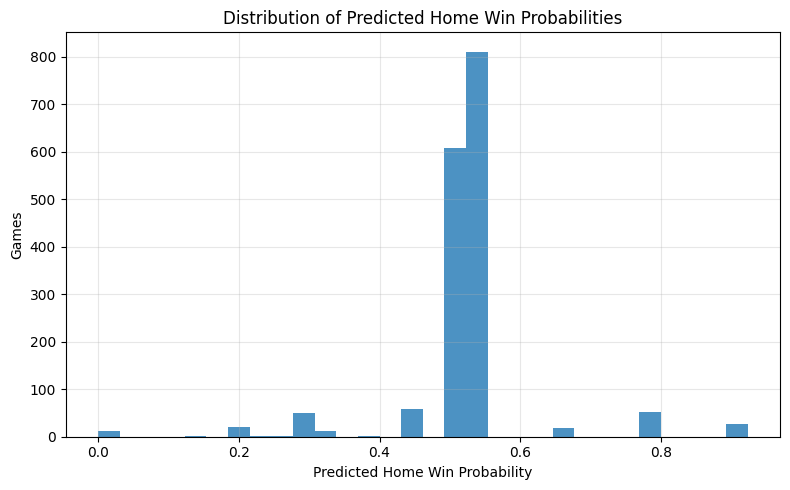

In [143]:
p_model = p_cal  # or your best probability vector

pred_summary = pd.Series(p_model).describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
display(pred_summary)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(p_model, bins=30, alpha=0.8)
ax.set_title("Distribution of Predicted Home Win Probabilities")
ax.set_xlabel("Predicted Home Win Probability")
ax.set_ylabel("Games")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [144]:
def calibration_table_fixed_bins(y_true, p, bins=np.arange(0.30, 0.76, 0.05)):
    d = pd.DataFrame({
        "y": np.asarray(y_true).astype(float),
        "p": np.clip(np.asarray(p), 0.001, 0.999),
    })

    d["bucket"] = pd.cut(d["p"], bins=bins, include_lowest=True)

    out = (
        d.groupby("bucket", observed=True)
        .agg(
            n=("y", "count"),
            avg_pred=("p", "mean"),
            actual_rate=("y", "mean"),
        )
        .reset_index()
    )

    out["calibration_error"] = out["actual_rate"] - out["avg_pred"]
    out["abs_calibration_error"] = out["calibration_error"].abs()

    out["se"] = np.sqrt(
        out["actual_rate"] * (1 - out["actual_rate"]) / out["n"].clip(lower=1)
    )

    out["ci_low"] = out["actual_rate"] - 1.96 * out["se"]
    out["ci_high"] = out["actual_rate"] + 1.96 * out["se"]

    return out

cal_fixed = calibration_table_fixed_bins(test_df["target_home_win"], p_model)
display(cal_fixed)

,bucket,n,avg_pred,actual_rate,calibration_error,abs_calibration_error,se,ci_low,ci_high
0,"(0.299, 0.35]",12,0.328610,0.333333,0.004723,0.004723,0.136083,0.066611,0.600056
1,"(0.35, 0.4]",1,0.386915,0.000000,-0.386915,0.386915,0.000000,0.000000,0.000000
2,"(0.4, 0.45]",59,0.438596,0.372881,-0.065715,0.065715,0.062956,0.249488,0.496274
3,"(0.5, 0.55]",1418,0.523766,0.535966,0.012201,0.012201,0.013244,0.510009,0.561924
4,"(0.65, 0.7]",18,0.652174,0.666667,0.014493,0.014493,0.111111,0.448889,0.884444


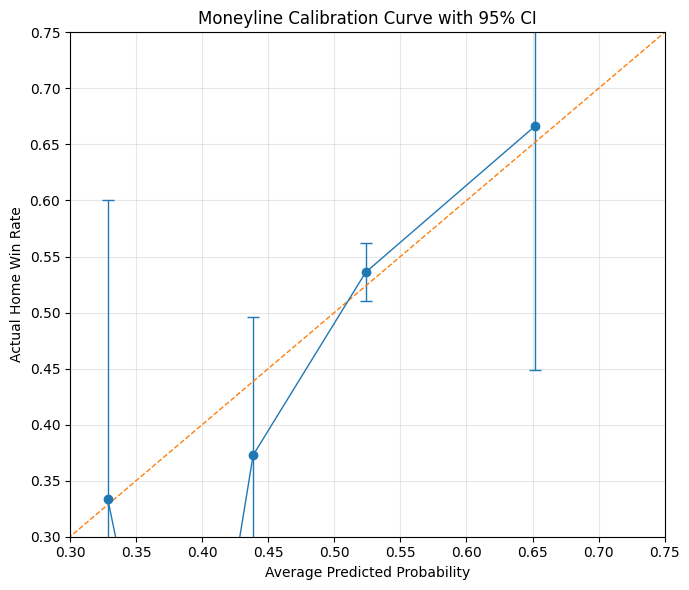

In [145]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.errorbar(
    cal_fixed["avg_pred"],
    cal_fixed["actual_rate"],
    yerr=[
        cal_fixed["actual_rate"] - cal_fixed["ci_low"],
        cal_fixed["ci_high"] - cal_fixed["actual_rate"],
    ],
    marker="o",
    capsize=4,
    linewidth=1,
)

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

ax.set_title("Moneyline Calibration Curve with 95% CI")
ax.set_xlabel("Average Predicted Probability")
ax.set_ylabel("Actual Home Win Rate")
ax.set_xlim(0.30, 0.75)
ax.set_ylim(0.30, 0.75)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [147]:
stable_perm_features = (
    perm_df
    .assign(signal_to_noise=lambda d: d["importance_mean"] / d["importance_std"].replace(0, np.nan))
    .query("importance_mean > 0")
    .sort_values("importance_mean", ascending=False)
)

display(stable_perm_features.head(50))

def eval_feature_subset(feature_cols, name):
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=700,
            min_samples_leaf=25,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    model.fit(train_df[feature_cols], train_df["target_home_win"])

    p = model.predict_proba(test_df[feature_cols])[:, 1]
    p = np.clip(p, 0.001, 0.999)

    return {
        "model_name": name,
        "n_features": len(feature_cols),
        "log_loss": log_loss(test_df["target_home_win"], p),
        "brier": brier_score_loss(test_df["target_home_win"], p),
        "auc": roc_auc_score(test_df["target_home_win"], p),
        "accuracy": accuracy_score(test_df["target_home_win"], p >= 0.5),
        "avg_pred": p.mean(),
        "actual_mean": test_df["target_home_win"].mean(),
    }

subset_results = []

for k in [50, 100, 150, 250, 400]:
    cols = stable_perm_features["feature"].head(k).tolist()
    cols = [c for c in cols if c in train_df.columns]

    subset_results.append(
        eval_feature_subset(cols, f"top_{k}_perm_features")
    )

# Baseline full set
subset_results.append(
    eval_feature_subset(numeric_cols, "full_current_feature_set")
)

subset_results_df = pd.DataFrame(subset_results).sort_values("log_loss")
display(subset_results_df)

cal_compare = pd.DataFrame([
    {
        "model": "uncalibrated",
        "log_loss": log_loss(test_df["target_home_win"], p_uncal),
        "brier": brier_score_loss(test_df["target_home_win"], p_uncal),
        "auc": roc_auc_score(test_df["target_home_win"], p_uncal),
        "avg_pred": np.mean(p_uncal),
        "actual_mean": test_df["target_home_win"].mean(),
    },
    {
        "model": "calibrated",
        "log_loss": log_loss(test_df["target_home_win"], p_cal),
        "brier": brier_score_loss(test_df["target_home_win"], p_cal),
        "auc": roc_auc_score(test_df["target_home_win"], p_cal),
        "avg_pred": np.mean(p_cal),
        "actual_mean": test_df["target_home_win"].mean(),
    },
])

display(cal_compare.sort_values("log_loss"))

,feature,importance_mean,importance_std,signal_to_noise
824,diff_starter_starter_statcast_sc_max_velo_last3,0.020678,0.000164,126.226716
605,diff_team_pitchmix_team_pitchmix_pt_pitches_br...,0.020544,0.000243,84.377016
603,diff_team_pitchmix_team_pitchmix_pt_pitches_br...,0.020456,0.000204,100.051368
655,diff_team_pitchmix_team_pitchmix_pt_woba_offsp...,0.019836,0.000190,104.654635
46,diff_team_team_runs_for_last5,0.018480,0.006032,3.063714
376,home_team_pitchmix_team_pitchmix_pt_avg_ev_bre...,0.018463,0.006177,2.989103
260,away_team_sc_team_off_sc_xwoba_contact_last5,0.016664,0.008064,2.066490
834,diff_starter_starter_statcast_sc_avg_extension...,0.016347,0.008164,2.002359
649,diff_team_pitchmix_team_pitchmix_pt_woba_fastb...,0.016311,0.008069,2.021364
349,diff_team_sc_team_off_sc_bb_rate_last3,0.016206,0.008097,2.001500


,model_name,n_features,log_loss,brier,auc,accuracy,avg_pred,actual_mean
1,top_100_perm_features,100,0.683284,0.245211,0.558236,0.537679,0.530602,0.531699
2,top_150_perm_features,150,0.683778,0.245434,0.557719,0.552033,0.529335,0.531699
5,full_current_feature_set,889,0.684141,0.245623,0.556827,0.540072,0.529194,0.531699
3,top_250_perm_features,250,0.684555,0.245820,0.552941,0.537081,0.528553,0.531699
4,top_400_perm_features,396,0.684566,0.245822,0.552985,0.540072,0.529788,0.531699
0,top_50_perm_features,50,0.686243,0.246618,0.550552,0.535885,0.533692,0.531699


,model,log_loss,brier,auc,avg_pred,actual_mean
0,uncalibrated,0.683737,0.245402,0.560552,0.531409,0.531699
1,calibrated,0.812247,0.248589,0.553380,0.519408,0.531699


## 19. Choose champions and inspect residuals

Set manual champion names if you want to override the leaderboard. The totals champion selection includes a leakage guardrail.

In [ ]:
MANUAL_MONEYLINE_CHAMPION_NAME = None
MANUAL_TOTALS_CHAMPION_NAME = None
MANUAL_MARGIN_CHAMPION_NAME = None


def choose_best_moneyline():
    if MANUAL_MONEYLINE_CHAMPION_NAME:
        return MANUAL_MONEYLINE_CHAMPION_NAME
    if moneyline_results_df.empty:
        return None
    return moneyline_results_df.iloc[0]["model_name"]


def choose_best_totals():
    if MANUAL_TOTALS_CHAMPION_NAME:
        return MANUAL_TOTALS_CHAMPION_NAME
    if totals_results_df.empty:
        return None
    safe = totals_results_df[(totals_results_df["mae"] >= 2.0) & (totals_results_df["r2"] <= 0.50)].copy()
    if safe.empty:
        print("No safe totals models after leakage guardrail. Review leakage audit.")
        return None
    return safe.iloc[0]["model_name"]


def choose_best_margin():
    if MANUAL_MARGIN_CHAMPION_NAME:
        return MANUAL_MARGIN_CHAMPION_NAME
    if margin_results_df.empty:
        return None
    return margin_results_df.iloc[0]["model_name"]

MONEYLINE_CHAMPION_NAME = choose_best_moneyline()
TOTALS_CHAMPION_NAME = choose_best_totals()
MARGIN_CHAMPION_NAME = choose_best_margin()

print("Moneyline champion:", MONEYLINE_CHAMPION_NAME)
if MONEYLINE_CHAMPION_NAME:
    display(moneyline_results_df[moneyline_results_df["model_name"].eq(MONEYLINE_CHAMPION_NAME)])

print("Totals champion:", TOTALS_CHAMPION_NAME)
if TOTALS_CHAMPION_NAME:
    display(totals_results_df[totals_results_df["model_name"].eq(TOTALS_CHAMPION_NAME)])

print("Margin champion:", MARGIN_CHAMPION_NAME)
if MARGIN_CHAMPION_NAME:
    display(margin_results_df[margin_results_df["model_name"].eq(MARGIN_CHAMPION_NAME)])

resid_rows = []
if TOTALS_CHAMPION_NAME:
    total_resid = test_df_total["target_total_runs"].values - totals_preds[TOTALS_CHAMPION_NAME]
    resid_rows.append({
        "target": "total_runs",
        "champion": TOTALS_CHAMPION_NAME,
        "residual_mean": float(np.mean(total_resid)),
        "residual_std": float(np.std(total_resid, ddof=1)),
        "p10": float(np.quantile(total_resid, 0.10)),
        "p50": float(np.quantile(total_resid, 0.50)),
        "p90": float(np.quantile(total_resid, 0.90)),
    })
if MARGIN_CHAMPION_NAME:
    margin_resid = test_df_margin["target_home_margin"].values - margin_preds[MARGIN_CHAMPION_NAME]
    resid_rows.append({
        "target": "home_margin",
        "champion": MARGIN_CHAMPION_NAME,
        "residual_mean": float(np.mean(margin_resid)),
        "residual_std": float(np.std(margin_resid, ddof=1)),
        "p10": float(np.quantile(margin_resid, 0.10)),
        "p50": float(np.quantile(margin_resid, 0.50)),
        "p90": float(np.quantile(margin_resid, 0.90)),
    })

residual_summary_df = pd.DataFrame(resid_rows)
display(residual_summary_df)
residual_summary_df.to_csv(EDA_DIR / "champion_residual_summary.csv", index=False)

## 20. Feature importance / permutation importance for champions

Permutation importance can be slow. Start with one champion and a capped sample.

In [ ]:
from sklearn.inspection import permutation_importance

RUN_PERMUTATION_IMPORTANCE = False
PERMUTATION_SAMPLE_N = 1000
PERMUTATION_REPEATS = 5


def run_permutation_importance(champion_name, fitted_dict, target_col, task):
    if champion_name is None:
        return pd.DataFrame()
    bundle = fitted_dict[champion_name]
    model = bundle["model"]
    cols = bundle["feature_cols"]
    train, test = time_train_test_split(features, target_col)
    if len(test) > PERMUTATION_SAMPLE_N:
        test_sample = test.sample(PERMUTATION_SAMPLE_N, random_state=RANDOM_STATE)
    else:
        test_sample = test.copy()
    X = test_sample[cols]
    y = test_sample[target_col]
    scoring = "neg_log_loss" if task == "classification" else "neg_mean_absolute_error"
    result = permutation_importance(
        model,
        X,
        y,
        n_repeats=PERMUTATION_REPEATS,
        random_state=RANDOM_STATE,
        scoring=scoring,
        n_jobs=-1,
    )
    out = pd.DataFrame({
        "feature": cols,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
        "family": [feature_family(c) for c in cols],
    }).sort_values("importance_mean", ascending=False)
    return out

if RUN_PERMUTATION_IMPORTANCE:
    if MONEYLINE_CHAMPION_NAME:
        moneyline_imp = run_permutation_importance(MONEYLINE_CHAMPION_NAME, moneyline_fitted, "target_home_win", "classification")
        display(moneyline_imp.head(40))
        moneyline_imp.to_csv(EDA_DIR / "moneyline_permutation_importance.csv", index=False)
    if TOTALS_CHAMPION_NAME:
        totals_imp = run_permutation_importance(TOTALS_CHAMPION_NAME, totals_fitted, "target_total_runs", "regression")
        display(totals_imp.head(40))
        totals_imp.to_csv(EDA_DIR / "totals_permutation_importance.csv", index=False)
    if MARGIN_CHAMPION_NAME:
        margin_imp = run_permutation_importance(MARGIN_CHAMPION_NAME, margin_fitted, "target_home_margin", "regression")
        display(margin_imp.head(40))
        margin_imp.to_csv(EDA_DIR / "margin_permutation_importance.csv", index=False)
else:
    print("Set RUN_PERMUTATION_IMPORTANCE = True to run this section.")

## 21. Export champion model bundles

Exports are disabled by default. Flip the `APPROVE_*_EXPORT` flags in the config cell once you like the results.

In [ ]:
import joblib


def export_bundle(path: Path, bundle: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(bundle, path)
    print("Exported:", path.resolve())

created_at = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

if APPROVE_MONEYLINE_EXPORT and MONEYLINE_CHAMPION_NAME:
    row = moneyline_results_df[moneyline_results_df["model_name"].eq(MONEYLINE_CHAMPION_NAME)].iloc[0].to_dict()
    fit = moneyline_fitted[MONEYLINE_CHAMPION_NAME]
    bundle = {
        "model_name": MONEYLINE_CHAMPION_NAME,
        "model_type": "moneyline_home_win_classifier",
        "model": fit["model"],
        "feature_cols": fit["feature_cols"],
        "target_col": "target_home_win",
        "metrics": row,
        "created_at_utc": created_at,
        "test_fraction": TEST_FRACTION,
        "holdout_start_date": HOLDOUT_START_DATE,
    }
    export_bundle(MODEL_DIR / "mlb_moneyline_champion.joblib", bundle)
else:
    print("Moneyline export skipped.")

if APPROVE_TOTALS_EXPORT and TOTALS_CHAMPION_NAME:
    row = totals_results_df[totals_results_df["model_name"].eq(TOTALS_CHAMPION_NAME)].iloc[0].to_dict()
    fit = totals_fitted[TOTALS_CHAMPION_NAME]
    total_resid = test_df_total["target_total_runs"].values - totals_preds[TOTALS_CHAMPION_NAME]
    bundle = {
        "model_name": TOTALS_CHAMPION_NAME,
        "model_type": "total_runs_regression",
        "model": fit["model"],
        "feature_cols": fit["feature_cols"],
        "target_col": "target_total_runs",
        "residual_sigma": float(np.std(total_resid, ddof=1)),
        "residual_mean": float(np.mean(total_resid)),
        "metrics": row,
        "created_at_utc": created_at,
        "test_fraction": TEST_FRACTION,
        "holdout_start_date": HOLDOUT_START_DATE,
    }
    export_bundle(MODEL_DIR / "mlb_total_runs_champion.joblib", bundle)
else:
    print("Totals export skipped.")

if APPROVE_MARGIN_EXPORT and MARGIN_CHAMPION_NAME:
    row = margin_results_df[margin_results_df["model_name"].eq(MARGIN_CHAMPION_NAME)].iloc[0].to_dict()
    fit = margin_fitted[MARGIN_CHAMPION_NAME]
    margin_resid = test_df_margin["target_home_margin"].values - margin_preds[MARGIN_CHAMPION_NAME]
    bundle = {
        "model_name": MARGIN_CHAMPION_NAME,
        "model_type": "home_margin_regression",
        "model": fit["model"],
        "feature_cols": fit["feature_cols"],
        "target_col": "target_home_margin",
        "residual_sigma": float(np.std(margin_resid, ddof=1)),
        "residual_mean": float(np.mean(margin_resid)),
        "metrics": row,
        "created_at_utc": created_at,
        "test_fraction": TEST_FRACTION,
        "holdout_start_date": HOLDOUT_START_DATE,
    }
    export_bundle(MODEL_DIR / "mlb_home_margin_champion.joblib", bundle)
else:
    print("Margin export skipped.")

## 22. Local scoring / prediction CSVs

This scores rows that do not yet have final results, if your export included upcoming games. If no upcoming rows exist, it scores the latest available rows for sanity checking.

In [ ]:
def american_to_implied_prob(price):
    if pd.isna(price):
        return np.nan
    price = float(price)
    if price > 0:
        return 100.0 / (price + 100.0)
    if price < 0:
        return abs(price) / (abs(price) + 100.0)
    return np.nan


def expected_value_per_unit(prob, price):
    if pd.isna(prob) or pd.isna(price):
        return np.nan
    prob = float(prob)
    price = float(price)
    if price > 0:
        profit = price / 100.0
    else:
        profit = 100.0 / abs(price)
    return prob * profit - (1.0 - prob)


def first_existing(cols):
    for c in cols:
        if c in features.columns:
            return c
    return None

home_ml_col = first_existing(["home_moneyline", "home_ml", "home_price", "market_home_moneyline", "home_odds"])
away_ml_col = first_existing(["away_moneyline", "away_ml", "away_price", "market_away_moneyline", "away_odds"])

print("home ML col:", home_ml_col)
print("away ML col:", away_ml_col)

# Upcoming/future rows. If none exist, take the latest 30 rows for smoke testing.
if "target_home_win" in features.columns:
    score_df = features[features["target_home_win"].isna()].copy()
else:
    score_df = pd.DataFrame()

if score_df.empty:
    print("No ungraded/upcoming rows found. Scoring latest 30 rows for smoke test only.")
    score_df = features.sort_values("official_date" if "official_date" in features.columns else features.index.name or features.columns[0]).tail(30).copy()

prediction_cols_base = [
    c for c in [
        "game_pk", "official_date", "game_datetime_utc",
        "away_team_name", "home_team_name",
        "away_probable_pitcher_name", "home_probable_pitcher_name",
    ] if c in score_df.columns
]

moneyline_pred_df = score_df[prediction_cols_base].copy()

if MONEYLINE_CHAMPION_NAME:
    fit = moneyline_fitted[MONEYLINE_CHAMPION_NAME]
    X_score = score_df[fit["feature_cols"]]
    p_home = fit["model"].predict_proba(X_score)[:, 1]
    moneyline_pred_df["model_home_win_prob"] = p_home
    moneyline_pred_df["model_away_win_prob"] = 1 - p_home
    moneyline_pred_df["model_favorite"] = np.where(
        p_home >= 0.5,
        score_df.get("home_team_name", "home"),
        score_df.get("away_team_name", "away"),
    )
    moneyline_pred_df["model_favorite_prob"] = np.maximum(p_home, 1 - p_home)
    moneyline_pred_df["moneyline_model_name"] = MONEYLINE_CHAMPION_NAME

    if home_ml_col and away_ml_col:
        moneyline_pred_df["home_moneyline"] = score_df[home_ml_col]
        moneyline_pred_df["away_moneyline"] = score_df[away_ml_col]
        moneyline_pred_df["market_home_break_even"] = moneyline_pred_df["home_moneyline"].apply(american_to_implied_prob)
        moneyline_pred_df["market_away_break_even"] = moneyline_pred_df["away_moneyline"].apply(american_to_implied_prob)
        moneyline_pred_df["home_edge"] = moneyline_pred_df["model_home_win_prob"] - moneyline_pred_df["market_home_break_even"]
        moneyline_pred_df["away_edge"] = moneyline_pred_df["model_away_win_prob"] - moneyline_pred_df["market_away_break_even"]
        moneyline_pred_df["home_ev_per_unit"] = [expected_value_per_unit(p, ml) for p, ml in zip(moneyline_pred_df["model_home_win_prob"], moneyline_pred_df["home_moneyline"])]
        moneyline_pred_df["away_ev_per_unit"] = [expected_value_per_unit(p, ml) for p, ml in zip(moneyline_pred_df["model_away_win_prob"], moneyline_pred_df["away_moneyline"])]
        moneyline_pred_df["recommended_side"] = np.where(moneyline_pred_df["home_ev_per_unit"] >= moneyline_pred_df["away_ev_per_unit"], "home", "away")
        moneyline_pred_df["recommended_price"] = np.where(moneyline_pred_df["recommended_side"].eq("home"), moneyline_pred_df["home_moneyline"], moneyline_pred_df["away_moneyline"])
        moneyline_pred_df["recommended_model_prob"] = np.where(moneyline_pred_df["recommended_side"].eq("home"), moneyline_pred_df["model_home_win_prob"], moneyline_pred_df["model_away_win_prob"])
        moneyline_pred_df["recommended_market_prob"] = np.where(moneyline_pred_df["recommended_side"].eq("home"), moneyline_pred_df["market_home_break_even"], moneyline_pred_df["market_away_break_even"])
        moneyline_pred_df["edge"] = moneyline_pred_df["recommended_model_prob"] - moneyline_pred_df["recommended_market_prob"]
        moneyline_pred_df["expected_value_per_unit"] = np.where(moneyline_pred_df["recommended_side"].eq("home"), moneyline_pred_df["home_ev_per_unit"], moneyline_pred_df["away_ev_per_unit"])
else:
    print("No moneyline champion selected/trained.")

moneyline_out = PRED_DIR / "mlb_moneyline_predictions_local.csv"
moneyline_pred_df.to_csv(moneyline_out, index=False)
print("Saved:", moneyline_out.resolve())
display(moneyline_pred_df.head(30))

In [ ]:
totals_margin_pred_df = score_df[prediction_cols_base].copy()

if TOTALS_CHAMPION_NAME:
    fit = totals_fitted[TOTALS_CHAMPION_NAME]
    pred_total = np.asarray(fit["model"].predict(score_df[fit["feature_cols"]]), dtype=float)
    totals_margin_pred_df["pred_total_runs"] = np.clip(pred_total, 0.05, None)
    totals_margin_pred_df["totals_model_name"] = TOTALS_CHAMPION_NAME

if MARGIN_CHAMPION_NAME:
    fit = margin_fitted[MARGIN_CHAMPION_NAME]
    pred_margin = np.asarray(fit["model"].predict(score_df[fit["feature_cols"]]), dtype=float)
    totals_margin_pred_df["pred_home_margin"] = pred_margin
    totals_margin_pred_df["margin_model_name"] = MARGIN_CHAMPION_NAME

# Optional approximate run-line probabilities if you have a margin sigma.
if MARGIN_CHAMPION_NAME and not residual_summary_df.empty:
    sig = residual_summary_df.loc[residual_summary_df["target"].eq("home_margin"), "residual_std"]
    if len(sig):
        totals_margin_pred_df["margin_residual_sigma"] = float(sig.iloc[0])

tr_out = PRED_DIR / "mlb_totals_runline_predictions_local.csv"
totals_margin_pred_df.to_csv(tr_out, index=False)
print("Saved:", tr_out.resolve())
display(totals_margin_pred_df.head(30))

## 23. Save compact modeling artifacts and zip outputs

In [ ]:
# Save a compact feature inventory and model result summary.
summary = {
    "created_at_utc": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
    "features_path": str(FEATURES_PATH),
    "n_rows": int(features.shape[0]),
    "n_cols": int(features.shape[1]),
    "n_candidate_features": int(len(candidate_feature_cols)),
    "moneyline_champion": MONEYLINE_CHAMPION_NAME,
    "totals_champion": TOTALS_CHAMPION_NAME,
    "margin_champion": MARGIN_CHAMPION_NAME,
}

with open(OUTPUT_DIR / "local_modeling_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

# Create zip for easy sharing/backups.
zip_path = Path("mlb_local_modeling_outputs.zip")
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for p in OUTPUT_DIR.rglob("*"):
        if p.is_file():
            z.write(p, p.relative_to(OUTPUT_DIR.parent))

print("Wrote:", zip_path.resolve())

## 24. Local reload example

Use this in another local notebook/script after exporting champion bundles.

In [ ]:
# Example:
# import joblib
# moneyline_bundle = joblib.load("mlb_local_outputs/models/mlb_moneyline_champion.joblib")
# model = moneyline_bundle["model"]
# cols = moneyline_bundle["feature_cols"]
# preds = model.predict_proba(features[cols])[:, 1]